In [ ]:
#Nb magic to interactive plots
#%matplotlib ipympl
%matplotlib inline
# Nb magic to automatically reload the module when it changes
%load_ext autoreload
%autoreload 2

In [5]:
# Relevant libraries
import warnings

# Suppress only UserWarnings
warnings.simplefilter("ignore", category = UserWarning)
import torch as tn
import torchtt as tntt
import numpy as np
from tutils import *
import matplotlib.pyplot as plt

In [ ]:
def linear_i(mps, fscale, f_boundary, eps = 1e-15,epsilon = 0.1):
    """ Liner MPS interpolation
    """
    ni = len(mps.N)
    nc = fscale - ni 
    
    unif = X_qtt(ni)
    phi1 = tntt.TT(qtt_polynomial_cores([1,-1], nc))
    phi2 = tntt.TT(qtt_polynomial_cores([0,1], nc))
    sm = R_qtt( 2**ni -1, ni)
    id = I_qtt(ni)
    smy = zkron( id , sm)
    smx = zkron(sm,id)
    smxy = zkron(sm,sm)

    delta = dmps(2**ni -1,ni)

    if f_boundary[0] == 'gaussian':
        scale = ni
        base_scaling = 2.0 ** (-4.0 / 3.0)
        r = f_boundary[1]
        corner = 1 + (base_scaling**scale)*epsilon*np.random.randn()
        by = 1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]).round(eps)
        bx = 1 +(base_scaling**scale) * epsilon *tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]).round(eps)
    
    elif f_boundary == 'zero':
        corner = 1
        by = tntt.ones([2]*ni)
        bx = tntt.ones([2]*ni)

    else:
        by = tntt.TT( f_boundary([ unif.full().flatten(), tn.ones(2**ni)]), [2]*ni)
        bx = tntt.TT( f_boundary([ tn.ones(2**ni), unif.full().flatten()]), [2]*ni)
        corner = f_boundary([tn.tensor(0),tn.tensor(0)])

    rmps = tntt.kron( mps, zkron( phi1 , phi1 ) ) + tntt.kron( smy @ mps  + zkron(by,delta) , zkron( phi1, phi2 ) )

    rmps += tntt.kron( smx @ mps + zkron(delta,bx), zkron( phi2 , phi1 ) ) + tntt.kron( smxy @ mps + zkron( sm @ by , delta ) + zkron( delta , sm @ bx ) + zkron( delta , delta)* corner, zkron( phi2 , phi2 ) )
   
    rmps = rmps.round(eps)
    return rmps


def cuadratic_i(mps, fscale, f_boundary, eps = 1e-15,epsilon = 0.1):
    # Quadratic 2d mps interpolation
    ni = len(mps.N)
    nc = fscale - ni + 1
    
    phi1 = tntt.TT(qtt_polynomial_cores([1,-3,2], nc))
    phi2 = tntt.TT(qtt_polynomial_cores([0,4,-4], nc))
    phi3 = tntt.TT(qtt_polynomial_cores([0,-1,2], nc))


    fttr00 = reduce(mps,0)
    fttr10 = reduce(mps,2)
    fttr01 = reduce(mps,1)
    fttr11 = reduce(mps,3)

    if f_boundary[0] == 'gaussian':
        scale = ni
        base_scaling = 2.0 ** (-4.0 / 3.0)
        r = f_boundary[1]
        corner = 1 + (base_scaling**scale)*epsilon*np.random.randn()
        by = 1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]).round(eps)
        bx = 1 +(base_scaling**scale) * epsilon *tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]).round(eps)
        by0 = reduceg(by,0,-1)
        by1 = reduceg(by,1,-1)
        bx0 = reduceg(bx,0,-1)
        bx1 = reduceg(bx,1,-1)
    
    elif f_boundary == 'zero':
        corner = 1
        by = tntt.ones([2]*ni)
        bx = tntt.ones([2]*ni)
        by0 = tntt.ones([2]*(ni-1))
        by1 = tntt.ones([2]*(ni-1))
        bx0 = tntt.ones([2]*(ni-1))
        bx1 = tntt.ones([2]*(ni-1))

    else:
        unif = X_qtt(ni)
        by = tntt.TT( tn.tensor(fr([ unif.full().flatten(), tn.ones(2**(ni))]),dtype=tn.float64), [2]*(ni),eps=eps)
        bx = tntt.TT( tn.tensor(fr([ tn.ones(2**(ni)), unif.full().flatten()]),dtype=tn.float64), [2]*(ni),eps=eps)
        by0 = reduceg(by,0,-1)
        by1 = reduceg(by,1,-1)
        bx0 = reduceg(bx,0,-1)
        bx1 = reduceg(bx,1,-1)
        corner = f_boundary([tn.tensor(0),tn.tensor(0)])

    # define shift matrix
    delta = dmps( 2**(ni-1) - 1 , ni - 1)
    sm = R_qtt( 2**(ni-1) - 1 , ni - 1)
    id = I_qtt( ni-1 )

    smy = zkron(  id , sm )
    smx = zkron( sm , id )
    smxy = zkron( sm , sm )

    mask2 = tntt.kron( fttr00 , zkron( phi1,phi1 ) ) + tntt.kron(fttr10 , zkron( phi2,phi1 ) ) + tntt.kron(fttr01 , zkron( phi1 ,phi2 ) ) + tntt.kron( fttr11, zkron( phi2 ,phi2 ) )
    mask2 += tntt.kron(smy@fttr00  + zkron(by0,delta) , zkron( phi1,phi3 ) ) + tntt.kron(smx@fttr00 + zkron(delta,bx0), zkron( phi3,phi1 ) ) 
    mask2 += tntt.kron(smy@fttr10  + zkron(by1,delta), zkron( phi2,phi3 ) ) + tntt.kron(smx@fttr01 + zkron(delta,bx1) , zkron( phi3,phi2 ) )
    mask2 += tntt.kron( smxy@fttr00  + smx@zkron(by0,delta) + smy@zkron(delta,bx0) + corner*zkron(delta,delta), zkron( phi3,phi3 ) )
    mask2 = mask2.round(eps)


    return mask2


def apply_local_op(mps,index,local_op):
    cores = mps.cores

    cores[index] = tn.einsum( 'abc, bd -> adc',cores[index],local_op)

    return tntt.TT(cores)

def kcubicspline_i(mps, fscale, f_boundary, eps = 1e-15,epsilon = 0.1):

    if not isinstance(f_boundary, tuple):
        f_boundary = [f_boundary, None]

    ni = len(mps.N)
    nc = fscale - ni 

    # 2D cubic kernel interpolation
    Mkc = tn.tensor([
        [0, 2, 0, 0],
        [-1, 0, 1, 0],
        [2, -5, 4, -1],
        [-1, 3, -3, 1]
    ], dtype=tn.float64) /2

    Mkct = Mkc.t()
    id = I_qtt(ni)

    sm1 = R_qtt( 2**ni -1, ni)
    sm2 = R_qtt( 2**ni -2, ni)
    smm1 = L_qtt( 1, ni)

    #minus operator
    Om1 = smm1 + 3*dmpo(0,0,ni) - 3*dmpo(0,1,ni) + dmpo(0,2,ni)
    #plus two operators
    O2 = sm2 - 3*dmpo(2**ni-1,2**ni-1,ni) + dmpo(2**ni-1,2**ni-2,ni)

    #boundary conditions
    delta = dmps(2**ni -1,ni)
    delta2 = dmps(2**ni -2,ni) + 3*dmps(2**ni -1,ni)

    if f_boundary[0] == 'gaussian':
        scale = ni
        base_scaling = 2.0 ** (-4.0 / 3.0)
        r = f_boundary[1]
        f11 = 1 + (base_scaling**scale)*epsilon*np.random.randn()
        by = (1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1])) * (1-delta) + f11*delta
        bx = (1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]) ) * (1-delta) + f11*delta

        by = by.round(1e-15)
        bx = by.round(1e-15)

        corner = f11*zkron(delta,delta)
        cornery = f11*zkron(delta , delta2)
        cornerx = f11*zkron(delta2 , delta)
        corner2 = f11*zkron(delta2 , delta2)

    
    elif f_boundary[0] == 'zero':
        f11 = 1
        by = tntt.ones([2]*ni)
        bx = tntt.ones([2]*ni)
        corner = f11*zkron(delta,delta)
        cornery = f11*zkron(delta , delta2)
        cornerx = f11*zkron(delta2 , delta)
        corner2 = f11*zkron(delta2 , delta2)


    else:
        unif = X_qtt(ni)
        by = tntt.TT( tn.tensor(fr([ unif.full().flatten(), tn.ones(2**(ni))]),dtype=tn.float64), [2]*(ni),eps=eps).to(dtype=tn.float64)
        bx = tntt.TT( tn.tensor(fr([ tn.ones(2**(ni)), unif.full().flatten()]),dtype=tn.float64), [2]*(ni),eps=eps).to(dtype=tn.float64)
        corner = Ff(1,1)*zkron(delta,delta)
        cornery = Ff(1,1)*zkron(delta , delta2)
        cornerx = Ff(1,1)*zkron(delta2 , delta)
        corner2 = Ff(1,1) * zkron(delta2, delta2)

    mby = zkron( by , delta )
    mbx = zkron( delta , bx )
    mby2 = zkron( by , delta2 )
    mbx2 = zkron( delta2 , bx )
    
    
    I4 = tn.eye(4,dtype=tn.float64)
    t4 = [ tntt.TT(I4[i]) for i in range(4)]

    mpsck = tntt.kron( mps, zkron( t4[1], t4[1] ) ) + tntt.kron( zkron(id,sm1)@mps + mby , zkron( t4[1],t4[2] ) ) + tntt.kron( zkron(sm1,id)@mps + mbx, zkron(t4[2],t4[1])) +  tntt.kron( zkron(sm1,sm1)@mps + zkron(sm1,id)@mby + zkron(id,sm1)@mbx + corner, zkron(t4[2],t4[2]))
    #mpsck = mpsck.round(eps)
    mpsck += tntt.kron(zkron(Om1, Om1) @ mps, zkron(t4[0], t4[0])) + tntt.kron(zkron(Om1, id) @ mps, zkron(t4[0], t4[1])) + tntt.kron(zkron(Om1, sm1) @ mps + zkron(Om1, id) @ mby, zkron(t4[0], t4[2])) + tntt.kron(zkron(id, Om1) @ mps, zkron(t4[1], t4[0])) + tntt.kron(zkron(sm1, Om1) @ mps + zkron(id, Om1) @ mbx, zkron(t4[2], t4[0]))
    #mpsck = mpsck.round(eps)
    mpsck += tntt.kron(zkron(O2, Om1) @ mps + zkron(id, Om1) @ mbx2, zkron(t4[3], t4[0])) + tntt.kron(zkron(Om1, O2) @ mps + zkron(Om1, id) @ mby2, zkron(t4[0], t4[3])) + tntt.kron(zkron(O2, id) @ mps + mbx2, zkron(t4[3], t4[1])) + tntt.kron(zkron(id, O2) @ mps + mby2, zkron(t4[1], t4[3]))
    #mpsck = mpsck.round(eps)
    mpsck += tntt.kron( zkron(O2, sm1) @ mps + zkron(id, sm1) @ mbx2 + zkron(O2, id) @ mby + cornerx, zkron(t4[3], t4[2]) ) + tntt.kron( zkron(sm1, O2) @ mps + zkron(id, O2) @ mbx + cornery + zkron(sm1, id) @ mby2, zkron(t4[2], t4[3]))
    #mpsck = mpsck.round(eps)
    mpsck += tntt.kron( zkron(O2, O2) @ mps + zkron(id, O2) @ mbx2 + zkron(O2, id) @ mby2 + corner2, zkron(t4[3], t4[3]))
    mpsck = mpsck.round(eps)

    pols = [tntt.kron( t4[i], tntt.TT(qtt_polynomial_cores(Mkct[i], nc)) ) for i in range(4)]
    Ps = sum(pols).round(1e-15)
    Pz = zkron(Ps,Ps).round(1e-15)

    mpscks = connect(mpsck,Pz,pd=16).round(eps)

    return mpscks


def acubicspline_i(mps, fscale, f_boundary, eps = 1e-15,epsilon = 0.1):
    ni = len(mps.N)
    nc = fscale - ni 
    #Generate approximation
    M = tn.tensor([
        [1, 1, 0, 0],
        [0, 1, 1, 1],
        [0, 1, 0, 2],
        [0, 1, 0, 3]
    ], dtype=tn.float64)

    Mi = M.inverse()

    id = I_qtt(ni)
    delta = dmps(2**ni -1,ni)
    sm = R_qtt(2**(ni)-1, ni)

    smx = zkron(sm,id)
    smy = zkron( id , sm)
    smxy = zkron( sm , sm)

    Dop = R_qtt( 2**ni -1, ni,dtype = tn.float64) - L_qtt( 1, ni ,dtype = tn.float64) - 2*dmpo(0,0,ni) + dmpo(0,1,ni) +  2*dmpo(2**ni -1,2**ni -1,ni) - dmpo(2**ni -1,2**ni -2,ni)
    Dop = (Dop/2).round(1e-15)
    #Dop = R_qtt( 2**p -1, p,dtype = tn.float64) - id +  2*dmpo(2**p -1,2**p -1,p) - dmpo(2**p -1,2**p -2,p)
    #Dop = (Dop).round(1e-15)
    Dx = zkron( Dop,id)
    Dy = zkron( id,Dop)
    Dxy = zkron( Dop,Dop)

    if f_boundary[0] == 'gaussian':
        scale = ni
        base_scaling = 2.0 ** (-4.0 / 3.0)
        r = f_boundary[1]
        corner = 1 + (base_scaling**scale)*epsilon*np.random.randn()
        by = 1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]).round(eps)
        bx = 1 + (base_scaling**scale) * epsilon *tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]).round(eps)
    
    elif f_boundary == 'zero':
        corner = 1
        by = tntt.ones([2]*ni)
        bx = tntt.ones([2]*ni)

    else:
        unif = X_qtt(ni)
        by = tntt.TT( tn.tensor(fr([ unif.full().flatten(), tn.ones(2**(ni))]),dtype=tn.float64), [2]*(ni),eps=eps).to(dtype=tn.float64)
        bx = tntt.TT( tn.tensor(fr([ tn.ones(2**(ni)), unif.full().flatten()]),dtype=tn.float64), [2]*(ni),eps=eps).to(dtype=tn.float64)
        corner = Ff(1,1)*zkron(delta,delta)

    #Geneare f matrix
    I4 = tn.eye(4,dtype=tn.float64)
    t4 = [ tntt.TT(I4[i],[4]) for i in range(4)]

    ftt = tntt.kron( mps, zkron(t4[0],t4[0]) ) + tntt.kron( smy@mps + zkron(by,delta),  zkron(t4[0], t4[1] )) + tntt.kron(smx@mps + zkron(delta,bx), zkron(t4[1],t4[0]) ) + tntt.kron(smxy@mps + smx@zkron(by,delta)+smy@zkron(delta,bx) + corner*zkron(delta,delta), zkron(t4[1],t4[1]) )

    dxmask = (Dx @ mps).round(1e-15)
    dxftt = tntt.kron(dxmask, zkron(t4[2],t4[0]) ) + tntt.kron(smy@dxmask, zkron(t4[2],t4[1]) ) + tntt.kron(smx@dxmask, zkron(t4[3],t4[0])) + tntt.kron(smxy@dxmask, zkron(t4[3],t4[1]) )
    dxftt = dxftt.round(1e-15)

    dymask = (Dy @ mps).round(1e-15)
    dyftt = tntt.kron(dymask, zkron(t4[0],t4[2])) + tntt.kron(smy@dymask, zkron(t4[0],t4[3])) + tntt.kron(smx@dymask, zkron(t4[1],t4[2]) ) + tntt.kron(smxy@dymask,zkron(t4[1],t4[3]) )
    dyftt = dyftt.round(1e-15)

    dxymask = (Dxy @ mps).round(1e-15)
    dxyftt = tntt.kron(dxymask, zkron(t4[2],t4[2])) + tntt.kron(smy@dxymask, zkron(t4[2],t4[3])) + tntt.kron(smx@dxymask, zkron(t4[3],t4[2])) + tntt.kron(smxy@dxymask, zkron(t4[3],t4[3]) )
    dxyftt = dxyftt.round(1e-15)
    #Geneare f matrix

    fmtt = ftt + dxftt + dyftt + dxyftt
    fmtt = fmtt.round(1e-15)
    #fmtt = apply_local_op(fmtt,-1,Mi)
    #fmtt = apply_local_op(fmtt,0,Mi)
    pols = [tntt.kron( t4[i], tntt.TT(qtt_polynomial_cores(Mi[i], nc)) ) for i in range(4)]
    Ps = sum(pols)
    Pz = zkron(Ps,Ps).round(1e-15)

    mpscks = connect(ftt,Pz,pd=16).round(eps)

    return mpscks


def ncubicspline_i(mps, fscale, f_boundary, eps = 1e-15,epsilon = 0.1):
    # 2D exact cspline mps implementation

    if not isinstance(f_boundary, tuple):
        f_boundary = [f_boundary, None]

    ni = len(mps.N)
    nc = fscale - ni 

    #Exact derivatives
    hh = 1
    H = 2**ni
    #operators
    Sp = R_qtt(2**(ni)-1, ni)
    Sm = L_qtt(1, ni)
    Opb = 4*tntt.eye([2]*ni) + Sp + Sm - dmpo(0,1,ni) 
    Opb = (Opb).round(1e-15)
    rhsOp = Sp - Sm - dmpo(0,1,ni) 
    rhsOp = (3*rhsOp/hh).round(1e-15)
    id = I_qtt(ni)
    # bd mpss
    de0 = dmps(0,ni)
    de1 = dmps(2**ni-1,ni)

    if f_boundary[0] == 'gaussian':
        scale = ni
        base_scaling = 2.0 ** (-4.0 / 3.0)
        r = f_boundary[1]
        corner = 1 + (base_scaling**scale)*epsilon*np.random.randn()
        # Boundary conditions        
        P0 = (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]).round(eps)/H
        P1 = (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]).round(eps)/H
        P1y = (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]).round(eps)/H
        Q0 = (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]).round(eps)/H
        Q1 = (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]).round(eps)/H
        Q1x = (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]).round(eps)/H
        U1x = 1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]).round(eps)
        U1y = 1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]).round(eps)

        #bd S, P 
        s00 = (base_scaling**scale)*epsilon*np.random.randn()
        s01 = (base_scaling**scale)*epsilon*np.random.randn()
        s10 = (base_scaling**scale)*epsilon*np.random.randn()
        s11 = (base_scaling**scale)*epsilon*np.random.randn()
        p01 = (base_scaling**scale)*epsilon*np.random.randn()
        p11 = (base_scaling**scale)*epsilon*np.random.randn()
        q10 = (base_scaling**scale)*epsilon*np.random.randn()
        q11 = (base_scaling**scale)*epsilon*np.random.randn()
        u11 = 1 + (base_scaling**scale)*epsilon*np.random.randn()

    elif f_boundary[0] == 'zero':
        # Boundary conditions        
        P0 = tntt.zeros([2]*ni, dtype=tn.float64)/H
        P1 = tntt.zeros([2]*ni, dtype=tn.float64)/H
        P1y = tntt.zeros([2]*ni, dtype=tn.float64)/H
        Q0 = tntt.zeros([2]*ni, dtype=tn.float64)/H
        Q1x = tntt.zeros([2]*ni, dtype=tn.float64)/H
        Q1 = tntt.zeros([2]*ni, dtype=tn.float64)/H
        U1x = tntt.ones( [2]*ni, dtype=tn.float64)
        U1y = tntt.ones( [2]*ni, dtype=tn.float64)

        #bd S, P 
        s00 = 0
        s01 = 0
        s10 = 0
        s11 = 0
        p01 = 0
        p11 = 0
        q10 = 0
        q11 = 0
        u11 = 1


    else:

        # Boundary conditions
        unif = X_qtt(ni)
        f = f_boundary[0]
        pdx = f_boundary[1][0]
        pdy = f_boundary[1][1]
        pdxy = f_boundary[1][2]
        
        P0 = tntt.TT( tn.tensor(pdx(unif.full(),0),dtype=tn.float64), [2]*ni,eps=1e-15).round(1e-15)/H
        P1 = tntt.TT( tn.tensor(pdx(unif.full(),1),dtype=tn.float64), [2]*ni,eps=1e-15).round(1e-15)/H
        P1y = tntt.TT( tn.tensor(pdxy(unif.full(),1),dtype=tn.float64), [2]*p,eps=1e-15).round(1e-15)/H
        Q0 = tntt.TT( tn.tensor(pdy(unif.full(),0),dtype=tn.float64), [2]*ni,eps=1e-15).round(1e-15)/H
        Q1 = tntt.TT( tn.tensor(pdy(unif.full(),1),dtype=tn.float64), [2]*ni,eps=1e-15).round(1e-15)/H
        U1x = tntt.TT( tn.tensor( f(1,unif.full() )  ,dtype=tn.float64), [2]*ni,eps=1e-15).round(1e-15)
        U1y = tntt.TT( tn.tensor(  f(unif.full(),1)  ,dtype=tn.float64), [2]*ni,eps=1e-15).round(1e-15)
        Q1x = tntt.TT( tn.tensor( pdxy(unif.full(),1),dtype=tn.float64), [2]*ni,eps=1e-15).round(1e-15)/H

        #bd S, P 
        s00 = pdxy(0,0)/H**2
        s01 = pdxy(0,1)/H**2
        s10 = pdxy(1,0)/H**2
        s11 = pdxy(1,1)/H**2
        p01 = pdx(0,1)/H
        p11 = pdx(1,1)/H
        q10 = pdy(1,0)/H
        q11 = pdy(1,1)/H
        u11 = f(1,1)
    
    corner = u11
    #p operators
    Pop = zkron( Opb , id )
    rhsopx = zkron( rhsOp , id )

    #q operators
    Qop = zkron( id , Opb )
    rhsopy = zkron( id , rhsOp )

    #RHS
    #p
    rhsp = rhsopx @ mps + 4*zkron( de0, P0) + (3/hh)*zkron( de1 , U1x ) - zkron( de1, P1)
    #rhsp = rhsp.round(1e-15)

    #q
    rhsq = rhsopy @ mps + 4*zkron( Q0, de0) + (3/hh)*zkron(U1y, de1 ) - zkron( Q1, de1)
    rhsq = rhsq.round(1e-15)


    #solve the systems
    Pmps = tntt.solvers.amen_solve(Pop, rhsp, eps=1e-15,kickrank=10,nswp=30).round(1e-15)
    Qmps = tntt.solvers.amen_solve(Qop, rhsq, eps=1e-15,kickrank=10,nswp=30).round(1e-15)

    # solve boundary S

    rhss0 = rhsOp @ P0 + 4*de0*s00 + (3/hh)*de1* p01  - de1*s01
    S0x = tntt.solvers.amen_solve(Opb, rhss0, eps=1e-15,kickrank=2,nswp=30).round(1e-15)

    rhss1 = rhsOp @ P1 + 4*de0*s10 +  (3/hh)*de1* p11  - de1*s11
    S1x = tntt.solvers.amen_solve(Opb, rhss1, eps=1e-15,kickrank=2,nswp=30).round(1e-15)

    ops = Opb
    rhss1y = rhsOp @ Q1 + 4*de0*s01 +  (3/hh)*de1* q11  - de1*s11
    S1y = tntt.solvers.amen_solve(ops, rhss1y, eps=1e-15,kickrank=2,nswp=30).round(1e-15)

    #Q10
    #rhsq10 = rhsOp @ U1x + 4*q10*de0 + (3/hh)*u11*de1 - de1*q11
    #rhsq10 = rhsq10.round(1e-15)
    #Q1y = tntt.solvers.amen_solve(Opb, rhsq10, eps=1e-15,kickrank=2,nswp=30).round(1e-15)

    #build S
    rhss = rhsopx @ Qmps + 4*zkron( de0, S0x) + (3/hh)*zkron( de1 , Q1x ) - zkron(de1, S1x)
    rhss = rhss.round(1e-15)

    # solve S
    Smps = tntt.solvers.amen_solve(Pop, rhss, eps=1e-15,kickrank=5,nswp=30).round(1e-15)

    #Generate approximation
    M = tn.tensor([
        [1, 1, 0, 0],
        [0, 1, 1, 1],
        [0, 1, 0, 2],
        [0, 1, 0, 3]
    ], dtype=tn.float64)

    Mi = M.inverse()

    id = I_qtt(ni)
    delta = dmps(2**ni -1,ni)
    sm = R_qtt(2**(ni)-1, ni)
    smx = zkron(sm,id)
    smy = zkron( id , sm)
    smxy = zkron(sm,sm)

    #boundary conditions
    by = U1y
    bx = U1x

    #Geneare f matrix
    I4 = tn.eye(4,dtype=tn.float64)
    t4 = [ tntt.TT(I4[i]) for i in range(4)]
    ftt = tntt.kron(mps,zkron(t4[0],t4[0])) + tntt.kron(smy@mps + zkron(by,delta), zkron(t4[0],t4[1])) + tntt.kron(smx@mps + zkron(delta,bx), zkron(t4[1],t4[0])) + tntt.kron(smxy@mps + smx@zkron(by,delta)+smy@zkron(delta,bx) + corner*zkron(delta,delta), zkron(t4[1],t4[1]) )
    ftt = ftt.round(1e-15)
    dxmask = Pmps
    dxftt = tntt.kron(dxmask, zkron(t4[2],t4[0])) + tntt.kron(smy@dxmask + zkron(P1y,delta), zkron(t4[2],t4[1])) + tntt.kron(smx@dxmask + zkron(delta,P1), zkron(t4[3],t4[0])) + tntt.kron(smy@zkron(delta,P1)+smxy@dxmask + smx@zkron(P1y,delta), zkron(t4[3],t4[1]) )
    dymask = Qmps
    dyftt = tntt.kron(dymask, zkron(t4[0],t4[2])) + tntt.kron(smy@dymask + zkron(Q1,delta), zkron(t4[0],t4[3])) + tntt.kron(smx@dymask+zkron(delta,Q1x), zkron(t4[1],t4[2])) + tntt.kron(smxy@dymask + smx@zkron(Q1,delta) + smy@zkron(delta,Q1x), zkron(t4[1],t4[3]) )
    dxymask = Smps
    dxyftt = tntt.kron(dxymask, zkron(t4[2],t4[2])) + tntt.kron(smy@dxymask + zkron(S1y,delta), zkron(t4[2],t4[3])) + tntt.kron(smx@dxymask + zkron(delta,S1x), zkron(t4[3],t4[2])) + tntt.kron(smxy@dxymask + smy@zkron(delta,S1x) +smx@zkron(S1y,delta), zkron(t4[3],t4[3]) )

    #Geneare f matrix

    fmtt = ftt + dxftt + dyftt + dxyftt
    fmtt = fmtt.round(1e-15)
    pols = [tntt.kron( t4[i], tntt.TT(qtt_polynomial_cores(Mi[i], nc)) ) for i in range(4)]
    Ps = sum(pols)
    Pz = zkron(Ps,Ps).round(1e-15)

    mpscks = connect(ftt,Pz,pd=16).round(eps)

    return mpscks

def skcubic_i(mps, fscale, f_boundary, eps = 1e-15,epsilon = 0.1 , order = 1, boundary = 'lineare',p_derivative=[0,0]):

    if not isinstance(f_boundary, tuple):
        f_boundary = [f_boundary, None]

    if boundary == 'periodic':
        f_boundary = ('periodic', None)

    ni = len(mps.N)
    nc = fscale - ni 

    id0 = I_qtt(ni)
    sm10 = R_qtt( 2**ni -1, ni)
    sm20 = R_qtt( 2**ni -2, ni)
    smm10 = L_qtt( 1, ni)
    ones = tntt.ones([1]*ni)
    onesf = tntt.ones([2]*nc)
    delta = dmps(2**ni -1,ni)
    deltae = tntt.kron(delta,onesf)
    if order == 1:
        # Build Kernel interpolant
        Mkc = tn.tensor([
            [0, 2, 0, 0],
            [-1, 0, 1, 0],
            [2, -5, 4, -1],
            [-1, 3, -3, 1]
        ], dtype=tn.float64) /2

        Mkct = Mkc.t()

    elif order == 2:

        Mkct = tn.tensor([
            [1, -3, 3, -1],
            [4, 0, -6, 3],
            [1, 3, 3, -3],
            [0,0, 0, 1]
        ], dtype=tn.float64) /6

    if boundary == "periodic":
        sm10 = P_qtt( 2**ni -1, ni)
        O20 = P_qtt( 2**ni -2, ni)
        Om10 = P_qtt( 1, ni)

    else:    
        sm10 = R_qtt( 2**ni -1, ni)
        sm20 = R_qtt( 2**ni -2, ni)
        smm10 = L_qtt( 1, ni)
        if boundary == 'lineare':
            Om10 = smm10 + 2*dmpo(0,0,ni) - dmpo(0,1,ni) 
            O20 = sm20 - dmpo(2**ni-1,2**ni-1,ni) 
            delta2 = dmps(2**ni -2,ni) + 2*dmps(2**ni -1,ni)
        elif boundary == 'mirror':
            Om10 = smm10 +  dmpo(0,1,ni) 
            O20 = sm20 + dmpo(2**ni-1,2**ni-1,ni) 
            delta2 = dmps(2**ni -2,ni) 
        elif boundary == 'clamped':
            Om10 = smm10 +  dmpo(0,0,ni) 
            O20 = sm20 
            delta2 = dmps(2**ni -2,ni) + dmps(2**ni -1,ni)
        else:
            Om10 = smm10 + 3*dmpo(0,0,ni) - 3*dmpo(0,1,ni) + dmpo(0,2,ni) 
            O20 = sm20 - 3*dmpo(2**ni-1,2**ni-1,ni) + dmpo(2**ni-1,2**ni-2,ni)
            delta2 = dmps(2**ni -2,ni) + 3*dmps(2**ni -1,ni)
            delta2e = tntt.kron(delta2,onesf)

        delta2e = tntt.kron(delta2,onesf)


    if f_boundary[0] == 'gaussian':

        scale = ni
        base_scaling = 2.0 ** (-4.0 / 3.0)
        r = 10
        f11 =  (base_scaling**scale) * epsilon * np.random.randn()
        bx = ( (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]) ) * (1-delta) + f11*delta
        by = ( (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1])) * (1-delta) + f11*delta
        corner = f11*delta
        corner2 = f11*delta2
    
    elif f_boundary[0] == 'zero':
        f11 = 1
        bx = tntt.ones([2]*ni)
        by = tntt.ones([2]*ni)
        corner = f11*delta
        corner2 = f11*delta2


    elif type(f_boundary[0]) == 'function':
        unif = X_qtt(ni)
        uniff = X_qtt(fscale)
        by = tntt.TT( tn.tensor(fr([ uniff.full().flatten(), tn.ones(2**(ni))]),dtype=tn.float64), [2]*(ni),eps=eps).to(dtype=tn.float64)
        bx = tntt.TT( tn.tensor(fr([ tn.ones(2**(ni)), unif.full().flatten()]),dtype=tn.float64), [2]*(ni),eps=eps).to(dtype=tn.float64)


    Mx = d_coeff_mat(Mkct, p_derivative[0]) 
    My = d_coeff_mat(Mkct, p_derivative[1])

    pols = [tntt.TT(qtt_polynomial_cores(Mx[i], nc)) for i in range(4)]
    polsx = [tntt.kron( ones, zkron(tntt.TT(qtt_polynomial_cores(Mx[i], nc)) , onesf) ).round(eps) for i in range(4)]
    polsy = [tntt.kron( ones, zkron( onesf , tntt.TT( qtt_polynomial_cores(My[i], nc)) ) ).round(eps) for i in range(4)]
    
    zones = zkron(onesf, onesf)
    mps = tntt.kron(mps, zones )

    oneso = tntt.eye([2]*nc)
    id = tntt.kron(id0,oneso)
    sm1 = tntt.kron(sm10,oneso)
    Om1 = tntt.kron(Om10,oneso)
    O2 = tntt.kron(O20,oneso)

    if boundary == 'periodic':
        f_kx =  (zkron(Om1,id) @ mps) *( polsx[0] ) + ( mps *  polsx[1] ) + ( zkron(sm1,id) @ mps ) * (polsx[2]) +  ( zkron(O2,id) @ mps ) * ( polsx[3])
        f_kx = f_kx.round(eps)
        
        f_kcs = (zkron(id,Om1) @ f_kx) * ( polsy[0] ) + ( f_kx * polsy[1] ) + ( zkron(id,sm1) @ f_kx) * (polsy[2]) + ( zkron(id,O2) @ f_kx ) * (polsy[3]) 
        f_kcs = f_kcs.round(eps)

    else:

        mbx = zkron( delta , bx ).round(eps)
        mbx2 = zkron( delta2 , bx ).round(eps)
        mbx = tntt.kron(mbx, zones )
        mbx2 = tntt.kron(mbx2,zones )
        f_kx =  (zkron(Om1,id) @ mps) *( polsx[0] ) + ( mps *  polsx[1] ) + ( zkron(sm1,id) @ mps + mbx) * (polsx[2]) +  ( zkron(O2,id) @ mps + mbx2) * ( polsx[3])
        f_kx = f_kx.round(eps)

        By = tntt.kron( ( Om10 @ by) , pols[0] ) + tntt.kron( by , pols[1] ) +  tntt.kron( sm10 @ by + corner, pols[2]) +  tntt.kron( O20 @ by + corner2 ,  pols[3])
        By = By.round(eps)
        mby = zkron( By , deltae )
        mby2 = zkron( By , delta2e )
        
        f_kcs = (zkron(id,Om1) @ f_kx) * ( polsy[0] ) + ( f_kx * polsy[1] ) + ( zkron(id,sm1) @ f_kx + mby) * (polsy[2]) + ( zkron(id,O2) @ f_kx + mby2) * (polsy[3]) 
        f_kcs = f_kcs.round(eps)

    return f_kcs


def gen_TT_cascade_p(Nscales=10, nrank=10,noise_scale=5,noctaves=5, levels=None, seed=None,epsilon=0.1 , var =1, method = 'linear', fnoise = None, eps=1e-10, order = 1,boundary = 'periodic', field = 'stream'):

    if levels is None:
        levels = Nscales
    if seed is not None:
        tn.manual_seed(seed)
    if fnoise == None:
        fnoise = 'gaussian'

    # Initialize the stream function uniformly.
    #psi = tntt.ones([4]*Nscales, dtype=tn.float64)
    
    #psi = 1 + (base_scaling**Nscales) * epsilon * ( tntt.randn([4]*Nscales,[1]+[nrank]*(Nscales-1)+[1]) )

    noise =   tntt.randn([4]*noise_scale,[1]+[nrank]*(noise_scale-1)+[1]) 

    if field == 'stream':
        psi = 0
        base_scaling = 2.0 ** (-4.0/3.0 )
        coarse_mps =  epsilon * ( noise)
        print(coarse_mps)
        # Interpolate to full resolution using linear interpolation.
        if method =='linear':
            smooth_mps =  linear_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon)

        # Interpolate to full resolution using cuadratic interpolation.
        elif method == 'cuadratic':
            if scale == 2:
                smooth_mps = 0
            else:
                smooth_mps =  cuadratic_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon)

        # Interpolate to full resolution using splines interpolation.
        elif method == 'acs':
            smooth_mps = acubicspline_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon)
        
        elif method == 'kcs':
            smooth_mps = kcubicspline_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon, order=order)

        elif method == 'ncs':
            smooth_mps = ncubicspline_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon)

        elif method == 'skc':
            smooth_mps = skcubic_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon,order=order,boundary=boundary)
        
        r_mps = smooth_mps
        psi = smooth_mps
        for k in range(1,noctaves):
            r_mps = reduce(r_mps,0)
            re_mps = tntt.kron(tntt.ones([4]*k),r_mps)
            psi += base_scaling**k * re_mps
            
        psi = psi.round(eps)
        return psi
    elif field == 'velocity':

        base_scaling = 2.0 ** (-1.0 / 3.0)
        coarse_mps =  epsilon * ( noise)
        
        # Interpolate to full resolution using linear interpolation.
        if method =='linear':
            smooth_mps =  linear_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon)

        elif method == 'skc':
            vxs = skcubic_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon,order=order,boundary=boundary,p_derivative=[0,1])
            vys = skcubic_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon,order=order,boundary=boundary,p_derivative=[1,0])
        
        r_mps_vx = vxs
        r_mps_vy = vys
        vx = vxs
        vy = -vys

        for k in range(1,noctaves):
            print(k,base_scaling**k)
            r_mps_vx = reduce(r_mps_vx,0)
            re_mps_vx = tntt.kron(tntt.ones([4]*k),r_mps_vx)

            r_mps_vy = reduce(r_mps_vy,0)
            re_mps_vy = tntt.kron(tntt.ones([4]*k),r_mps_vy)
            
            vx += base_scaling**k * re_mps_vx
            vy -= base_scaling**k * re_mps_vy

            
        vx = vx.round(eps)
        vy = vy.round(eps)


        return vx, vy


    return psi


def gen_TT_cascade(Nscales=10, nrank=10, levels=None, seed=None,epsilon=0.1 , var =1, method = 'linear', fnoise = None, eps=1e-10, order = 1,boundary = 'periodic', field = 'stream'):

    if levels is None:
        levels = Nscales
    if seed is not None:
        tn.manual_seed(seed)
    if fnoise == None:
        fnoise = 'gaussian'

    # Initialize the stream function uniformly.
    #psi = tntt.ones([4]*Nscales, dtype=tn.float64)
    
    #psi = 1 + (base_scaling**Nscales) * epsilon * ( tntt.randn([4]*Nscales,[1]+[nrank]*(Nscales-1)+[1]) )

    noise = gen_noisy_mps(levels,nrank,pdim=4,var=var) 

    if field == 'stream':
        psi = 1 
        base_scaling = 2.0 ** (-4.0 / 3.0)
        for i in range(len(noise)):
            scale = i + 2
            coarse_mps = (base_scaling**scale) * epsilon * ( noise[i])

            # Interpolate to full resolution using linear interpolation.
            if method =='linear':
                smooth_mps =  linear_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon)

            # Interpolate to full resolution using cuadratic interpolation.
            elif method == 'cuadratic':
                if scale == 2:
                    smooth_mps = 0
                else:
                    smooth_mps =  cuadratic_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon)

            # Interpolate to full resolution using splines interpolation.
            elif method == 'acs':
                smooth_mps = acubicspline_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon)
            
            elif method == 'kcs':
                smooth_mps = kcubicspline_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon, order=order)

            elif method == 'ncs':
                smooth_mps = ncubicspline_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon)

            elif method == 'skc':
                smooth_mps = skcubic_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon,order=order,boundary=boundary)
            

            psi += smooth_mps
        psi = psi.round(eps)
        return psi
    elif field == 'velocity':
        vx = 0
        vy = 0
        base_scaling = 2.0 ** (-1.0 / 3.0)
        for i in range(len(noise)):
            scale = i + 2
            coarse_mps = (base_scaling**scale) * epsilon * ( noise[i])

            # Interpolate to full resolution using linear interpolation.
            if method =='linear':
                smooth_mps =  linear_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon)

            elif method == 'skc':
                vxs = skcubic_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon,order=order,boundary=boundary,p_derivative=[0,1])
                vys = skcubic_i(coarse_mps,Nscales, fnoise, eps=eps, epsilon=epsilon,order=order,boundary=boundary,p_derivative=[1,0])
            
            vx += vxs
            vy -= vys
        vx = vx.round(eps)
        vy = vy.round(eps)
        return vx, vy


    return psi

def d_coeff_mat(M, order=0):
    if order == 0:
        return M
    elif order == 1:
        return M[:, 1:] * tn.tensor([1, 2, 3], dtype=M.dtype)
    elif order == 2:
        return M[:, 2:] * tn.tensor([2, 6], dtype=M.dtype)
    else:
        raise ValueError("Only derivative orders 0, 1, and 2 are supported.")

def skcubic3d_i(mps, fscale, f_boundary, eps = 1e-15,epsilon = 0.1, order = 1, boundary = 'periodic', p_derivative = [0,0,0]):
    if not isinstance(f_boundary, tuple):
        f_boundary = (f_boundary, None)
    
    if boundary == 'periodic':
        f_boundary = ('periodic', None)

    ni = len(mps.N)
    nc = fscale - ni 
    id0 = I_qtt(ni)
    ones = tntt.ones([1]*ni)
    onesf = tntt.ones([2]*nc)
    delta = dmps(2**ni -1,ni)
    deltae = tntt.kron(delta,onesf)

    if order == 1:
        # Build Kernel interpolant
        Mkc = tn.tensor([
            [0, 2, 0, 0],
            [-1, 0, 1, 0],
            [2, -5, 4, -1],
            [-1, 3, -3, 1]
        ], dtype=tn.float64) /2
        Mkct = Mkc.t()

    elif order == 2:
        Mkct = tn.tensor([
            [1, -3, 3, -1],
            [4, 0, -6, 3],
            [1, 3, 3, -3],
            [0,0, 0, 1]
        ], dtype=tn.float64) /6

    if boundary == "periodic":
        sm10 = P_qtt( 2**ni -1, ni)
        O20 = P_qtt( 2**ni -2, ni)
        Om10 = P_qtt( 1, ni)

    else:    
        sm10 = R_qtt( 2**ni -1, ni)
        sm20 = R_qtt( 2**ni -2, ni)
        smm10 = L_qtt( 1, ni)
        if boundary == 'lineare':
            Om10 = smm10 + 2*dmpo(0,0,ni) - dmpo(0,1,ni) 
            O20 = sm20 - dmpo(2**ni-1,2**ni-1,ni) 
            delta2 = dmps(2**ni -2,ni) + 2*dmps(2**ni -1,ni)
        elif boundary == 'mirror':
            Om10 = smm10 +  dmpo(0,1,ni) 
            O20 = sm20 + dmpo(2**ni-1,2**ni-1,ni) 
            delta2 = dmps(2**ni -2,ni) 
        elif boundary == 'clamped':
            Om10 = smm10 +  dmpo(0,0,ni) 
            O20 = sm20 
            delta2 = dmps(2**ni -2,ni) + dmps(2**ni -1,ni)
        else:
            Om10 = smm10 + 3*dmpo(0,0,ni) - 3*dmpo(0,1,ni) + dmpo(0,2,ni) 
            O20 = sm20 - 3*dmpo(2**ni-1,2**ni-1,ni) + dmpo(2**ni-1,2**ni-2,ni)
            delta2 = dmps(2**ni -2,ni) + 3*dmps(2**ni -1,ni)
            delta2e = tntt.kron(delta2,onesf)

        delta2e = tntt.kron(delta2,onesf)


    if f_boundary[0] == 'gaussian':
        ob = tntt.ones([2]*ni)
        db1 = zkron(ob,delta)
        db2 = zkron(delta,ob)
        scale = ni
        base_scaling = 2.0 ** (-4.0 / 3.0)
        r = f_boundary[1]
        f11 = 1 + (base_scaling**scale)*epsilon*np.random.randn()
        lx = (1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]) )*(1-delta) + f11*delta
        lx = lx.round(eps)
        ly = (1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]) )*(1-delta) + f11*delta
        ly = ly.round(eps)
        lz = (1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]) )*(1-delta) + f11*delta
        lz = lz.round(eps)


        bxy = (1 + (base_scaling**scale) * epsilon * tntt.randn([4]*ni, [1]+[r]*(ni-1)+[1]) )
        bxy = ( bxy*(1-db1-db2) + zkron(delta,ly ) + zkron(lx,delta) ).round(eps)
        bxz = (1 + (base_scaling**scale) * epsilon * tntt.randn([4]*ni, [1]+[r]*(ni-1)+[1]) )
        bxz = (bxz*(1-db1-db2) + zkron(delta,lz) + zkron(lx,delta) ).round(eps)
        byz = (1 + (base_scaling**scale) * epsilon * tntt.randn([4]*ni, [1]+[r]*(ni-1)+[1]))
        byz = (byz*(1-db1-db2) + zkron(delta,lz) + zkron(ly,delta) ).round(eps)

        

        corner = f11*delta
        corner2 = f11*delta2
    
    elif f_boundary[0] == 'zero':
        f11 = 1
        ly = tntt.ones([2]*ni)
        lz = tntt.ones([2]*ni)
        lx = tntt.ones([2]*ni)
        bxy = tntt.ones([4]*ni)
        bxz = tntt.ones([4]*ni)
        byz = tntt.ones([4]*ni)
        corner = f11*delta
        corner2 = f11*delta2



    elif type(f_boundary[0]) == 'function':
        unif = X_qtt(ni)
        by = tntt.TT( tn.tensor(f_boundary([ unif.full().flatten(), tn.ones(2**(ni))]),dtype=tn.float64), [2]*(ni),eps=eps).to(dtype=tn.float64)
        bx = tntt.TT( tn.tensor(f_boundary([ tn.ones(2**(ni)), unif.full().flatten()]),dtype=tn.float64), [2]*(ni),eps=eps).to(dtype=tn.float64)
        f11 = f_boundary([tn.tensor(1),tn.tensor(1)])
        corner = f11*delta
        corner2 = f11* delta2
    
    Mx = d_coeff_mat(Mkct, p_derivative[0]) 
    My = d_coeff_mat(Mkct, p_derivative[1])
    Mz = d_coeff_mat(Mkct, p_derivative[2])

    # y interpolation
    pols = [tntt.TT(qtt_polynomial_cores(My[i], nc)) for i in range(4)]
    polsi = [tntt.kron( ones, zkron(tntt.TT(qtt_polynomial_cores(My[i], nc)) , onesf) ).round(eps) for i in range(4)]
    # x interpolation
    polsj = [tntt.kron( ones, zkron( onesf , tntt.TT( qtt_polynomial_cores(Mx[i], nc)) )).round(eps) for i in range(4)]

    polsx = [tntt.kron( ones, zkron3(tntt.TT(qtt_polynomial_cores(Mx[i], nc)) , onesf,onesf) ).round(eps) for i in range(4)]
    polsy = [tntt.kron( ones, zkron3( onesf , tntt.TT( qtt_polynomial_cores(My[i], nc)), onesf )).round(eps) for i in range(4)]
    polsz = [tntt.kron( ones, zkron3( onesf , onesf , tntt.TT( qtt_polynomial_cores(Mz[i], nc)) )).round(eps) for i in range(4)]
    
    zones3 = zkron3(onesf, onesf, onesf)
    zones2 = zkron(onesf, onesf)

    oneso = tntt.eye([2]*nc)
    id = tntt.kron(id0,oneso)
    sm1 = tntt.kron(sm10,oneso)
    Om1 = tntt.kron(Om10,oneso)
    O2 = tntt.kron(O20,oneso)
    mps = tntt.kron(mps, zones3 )

    if boundary == 'periodic':

        #interpolate y
        f_ky = (zkron3(id,Om1,id) @ mps) * ( polsy[0] ) + ( mps * polsy[1] ) + ( zkron3(id,sm1,id) @ mps ) * (polsy[2]) + ( zkron3(id,O2,id) @ mps ) * (polsy[3]) 
        f_ky = f_ky.round(eps)

        #interpolate x
        f_kxy =  (zkron3(Om1,id,id) @ f_ky) *( polsx[0] ) + ( f_ky *  polsx[1] ) + ( zkron3(sm1,id,id) @ f_ky ) * (polsx[2]) +  ( zkron3(O2,id,id) @ f_ky ) * ( polsx[3])
        f_kxy = f_kxy.round(eps)

        #interpolate z
        f_kcs = (zkron3(id,id,Om1) @ f_kxy) * ( polsz[0] ) + ( f_kxy * polsz[1] ) + ( zkron3(id,id,sm1) @ f_kxy ) * (polsz[2]) + ( zkron3(id,id,O2) @ f_kxy ) * (polsz[3]) 
        f_kcs = f_kcs.round(eps)

    else:
        mby0 = zkron( delta , bxz ).round(1e-15)    
        mby20 = zkron( delta2 , bxz ).round(1e-15)
        # index y boundary correctly
        nindices = sum( [ [3*i + 1, 3*i, 3*i+2] for i in range(ni) ], [])
        mby = tntt.reshape( tntt.permute(mby0.to_qtt(), nindices ,eps) , [8]*ni)
        mby2 = tntt.reshape( tntt.permute(mby20.to_qtt(), nindices ,eps) , [8]*ni)
        mby = tntt.kron(mby, zones3 )
        mby2 = tntt.kron(mby2,zones3 )
        #interpolate y
        f_ky = (zkron3(id,Om1,id) @ mps) * ( polsy[0] ) + ( mps * polsy[1] ) + ( zkron3(id,sm1,id) @ mps + mby) * (polsy[2]) + ( zkron3(id,O2,id) @ mps + mby2) * (polsy[3]) 
        f_ky = f_ky.round(eps)

        #interpolate boundary yz
        mlz = zkron(delta,lz)
        mlz2 = zkron(delta2,lz)
        mlz = tntt.kron(mlz,zones2)
        mlz2 = tntt.kron(mlz2,zones2) 
        byz = tntt.kron(byz,zones2)
        Byz = (zkron(Om1,id) @ byz) *( polsi[0] ) + ( byz *  polsi[1] ) + ( zkron(sm1,id) @ byz + mlz ) * (polsi[2]) +  ( zkron(O2,id) @ byz + mlz2 ) * ( polsi[3])
        Byz = Byz.round(eps)
        #boundary x
        mbx = zkron( deltae, Byz )
        mbx2 = zkron( delta2e, Byz )

        #interpolate x
        f_kxy =  (zkron3(Om1,id,id) @ f_ky) *( polsx[0] ) + ( f_ky *  polsx[1] ) + ( zkron3(sm1,id,id) @ f_ky + mbx) * (polsx[2]) +  ( zkron3(O2,id,id) @ f_ky + mbx2) * ( polsx[3])
        f_kxy = f_kxy.round(eps)

        # interpolate boundary xy
        mly = zkron(delta,ly)
        mly2 = zkron(delta2,ly)
        mly = tntt.kron(mly,zones2)
        mly2 = tntt.kron(mly2,zones2) 

        # y interpolation
        bxy= tntt.kron(bxy,zones2)
        Bxy = (zkron(Om1,id) @ bxy) *( polsi[0] ) + ( bxy *  polsi[1] ) + ( zkron(sm1,id) @ bxy + mly) * (polsi[2]) +  ( zkron(O2,id) @ bxy + mly2) * ( polsi[3])
        Bxy = Bxy.round(eps)

        #1d boundary lx
        Blx = tntt.kron( ( Om10 @ lx) , pols[0] ) + tntt.kron( lx , pols[1] ) +  tntt.kron( sm10 @ lx + corner, pols[2]) +  tntt.kron( O20 @ lx + corner2 ,  pols[3])
        Blx = Blx.round(eps)
        mlx = zkron( Blx, deltae )
        mlx2 = zkron( Blx, delta2e )

        # x interpolation
        BBxy = (zkron(id,Om1) @ Bxy) * ( polsj[0] ) + ( Bxy * polsj[1] ) + ( zkron(id,sm1) @ Bxy + mlx) * (polsj[2]) + ( zkron(id,O2) @ Bxy + mlx2) * (polsj[3]) 
        BBxy = BBxy.round(eps)

        #final boundary xy
        mbz = zkron( BBxy, deltae )
        mbz2 = zkron( BBxy, delta2e )

        #interpolate z
        f_kcs = (zkron3(id,id,Om1) @ f_kxy) * ( polsz[0] ) + ( f_kxy * polsz[1] ) + ( zkron3(id,id,sm1) @ f_kxy + mbz) * (polsz[2]) + ( zkron3(id,id,O2) @ f_kxy + mbz2) * (polsz[3]) 
        f_kcs = f_kcs.round(eps)

    """ 
    #yx interpolation
    mlx = zkron(lx,delta)
    mlx2 = zkron(lx,delta2)
    mlx = tntt.kron(mlx,zones2)
    mlx2 = tntt.kron(mlx2,zones2) 

    # y interpolation
    bxy= tntt.kron(bxy,zones2)
    Bxy = (zkron(id,Om1) @ bxy) * ( polsj[0] ) + ( bxy * polsj[1] ) + ( zkron(id,sm1) @ bxy + mlx) * (polsj[2]) + ( zkron(id,O2) @ bxy + mlx2) * (polsj[3]) 
    Bxy = Bxy.round(eps)
    #1d boundary lx
    Bly = tntt.kron( ( Om10 @ ly) , pols[0] ) + tntt.kron( ly , pols[1] ) +  tntt.kron( sm10 @ ly + corner, pols[2]) +  tntt.kron( O20 @ ly + corner2 ,  pols[3])
    Bly = Bly.round(eps)
    mly = zkron( deltae,Bly)
    mly2 = zkron( delta2e, Bly )

    BBxy = (zkron(Om1,id) @ Bxy) *( polsi[0] ) + ( Bxy *  polsi[1] ) + ( zkron(sm1,id) @ Bxy + mly) * (polsi[2]) +  ( zkron(O2,id) @ Bxy + mly2) * ( polsi[3])
    BBxy = Bxy.round(eps)
    """

    return f_kcs

def skquad3d_i(mps, fscale, f_boundary, eps = 1e-15,epsilon = 0.1,boundary='lineare'):

    if not isinstance(f_boundary, tuple):
        f_boundary = (f_boundary, None)
        
    if boundary == 'periodic':
        f_boundary = ('periodic', None)

    ni = len(mps.N)
    nc = fscale - ni 
    # Final corrected B-spline matrices (4 samples × 3 monomial terms)
    mk1 = tn.tensor([
        [1/8, -1/2, 1/2],
        [3/4,  0.0, -1.0],
        [1/8,  1/2, 1/2],
        [0.0,  0.0, 0.0]
    ], dtype=tn.float64)
    mk2 = tn.tensor([
        [0.0,  0.0, 0.0],
        [9/8,  -3/2, 1/2],
        [-1/4,  2.0, -1],
        [1/8,  -1/2, 1/2]], dtype=tn.float64)

    id0 = I_qtt(ni)
    sm10 = R_qtt( 2**ni -1, ni)
    sm20 = R_qtt( 2**ni -2, ni)
    smm10 = L_qtt( 1, ni)
    delta = dmps(2**ni -1,ni)
    ones = tntt.ones([1]*ni)
    onesf = tntt.ones([2]*nc)
    deltae = tntt.kron(delta,onesf)

    if boundary == "periodic":
        sm10 = P_qtt( 2**ni -1, ni)
        O20 = P_qtt( 2**ni -2, ni)
        Om10 = P_qtt( 1, ni)

    else:    
        sm10 = R_qtt( 2**ni -1, ni)
        sm20 = R_qtt( 2**ni -2, ni)
        smm10 = L_qtt( 1, ni)
        if boundary == 'lineare':
            Om10 = smm10 + 2*dmpo(0,0,ni) - dmpo(0,1,ni) 
            O20 = sm20 - dmpo(2**ni-1,2**ni-1,ni) 
            delta2 = dmps(2**ni -2,ni) + 2*dmps(2**ni -1,ni)
        elif boundary == 'mirror':
            Om10 = smm10 +  dmpo(0,1,ni) 
            O20 = sm20 + dmpo(2**ni-1,2**ni-1,ni) 
            delta2 = dmps(2**ni -2,ni) 
        elif boundary == 'clamped':
            Om10 = smm10 +  dmpo(0,0,ni) 
            O20 = sm20 
            delta2 = dmps(2**ni -2,ni) + dmps(2**ni -1,ni)
        else:
            Om10 = smm10 + 3*dmpo(0,0,ni) - 3*dmpo(0,1,ni) + dmpo(0,2,ni) 
            O20 = sm20 - 3*dmpo(2**ni-1,2**ni-1,ni) + dmpo(2**ni-1,2**ni-2,ni)
            delta2 = dmps(2**ni -2,ni) + 3*dmps(2**ni -1,ni)
            delta2e = tntt.kron(delta2,onesf)

        delta2e = tntt.kron(delta2,onesf)


    if f_boundary[0] == 'gaussian':
        ob = tntt.ones([2]*ni)
        db1 = zkron(ob,delta)
        db2 = zkron(delta,ob)
        scale = ni
        base_scaling = 2.0 ** (-4.0 / 3.0)
        r = f_boundary[1]
        f11 = 1 + (base_scaling**scale)*epsilon*np.random.randn()
        lx = (1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]) )*(1-delta) + f11*delta
        lx = lx.round(eps)
        ly = (1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]) )*(1-delta) + f11*delta
        ly = ly.round(eps)
        lz = (1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]) )*(1-delta) + f11*delta
        lz = lz.round(eps)


        bxy = (1 + (base_scaling**scale) * epsilon * tntt.randn([4]*ni, [1]+[r]*(ni-1)+[1]) )
        bxy = ( bxy*(1-db1-db2) + zkron(delta,ly ) + zkron(lx,delta) ).round(eps)
        bxz = (1 + (base_scaling**scale) * epsilon * tntt.randn([4]*ni, [1]+[r]*(ni-1)+[1]) )
        bxz = (bxz*(1-db1-db2) + zkron(delta,lz) + zkron(lx,delta) ).round(eps)
        byz = (1 + (base_scaling**scale) * epsilon * tntt.randn([4]*ni, [1]+[r]*(ni-1)+[1]))
        byz = (byz*(1-db1-db2) + zkron(delta,lz) + zkron(ly,delta) ).round(eps)

        corner = f11*delta
        corner2 = f11*delta2
    
    elif f_boundary[0] == 'zero':
        f11 = 1
        ly = tntt.ones([2]*ni)
        lz = tntt.ones([2]*ni)
        lx = tntt.ones([2]*ni)
        bxy = tntt.ones([4]*ni)
        bxz = tntt.ones([4]*ni)
        byz = tntt.ones([4]*ni)
        corner = f11*delta
        corner2 = f11*delta2


    elif type(f_boundary[0]) == 'function':
        unif = X_qtt(ni)
        by = tntt.TT( tn.tensor(f_boundary([ unif.full().flatten(), tn.ones(2**(ni))]),dtype=tn.float64), [2]*(ni),eps=eps).to(dtype=tn.float64)
        bx = tntt.TT( tn.tensor(f_boundary([ tn.ones(2**(ni)), unif.full().flatten()]),dtype=tn.float64), [2]*(ni),eps=eps).to(dtype=tn.float64)
        f11 = f_boundary([tn.tensor(1),tn.tensor(1)])
        corner = f11*delta
        corner2 = f11* delta2

    def qtt2pol(i):
        phi0 = hs(nc,'1')*tntt.TT(qtt_polynomial_cores(mk1[i], nc)) 
        phi1 = hs(nc,'0')*tntt.TT(qtt_polynomial_cores(mk2[i], nc)) 
        return (phi0+phi1).round(eps)
    

    pols = [qtt2pol(i) for i in range(4)]
    polsi = [tntt.kron( ones, zkron(qtt2pol(i), onesf) ).round(eps) for i in range(4)]
    polsj = [tntt.kron( ones, zkron( onesf , qtt2pol(i) )).round(eps) for i in range(4)]
    polsx = [tntt.kron( ones, zkron3(qtt2pol(i), onesf,onesf) ).round(eps) for i in range(4)]
    polsy = [tntt.kron( ones, zkron3( onesf , qtt2pol(i), onesf )).round(eps) for i in range(4)]
    polsz = [tntt.kron( ones, zkron3( onesf , onesf , qtt2pol(i) )).round(eps) for i in range(4)]
    
    zones = zkron3(onesf, onesf, onesf)
    zones2 = zkron(onesf, onesf)

    oneso = tntt.eye([2]*nc)
    id = tntt.kron(id0,oneso)
    sm1 = tntt.kron(sm10,oneso)
    Om1 = tntt.kron(Om10,oneso)
    O2 = tntt.kron(O20,oneso)

    oneso = tntt.eye([2]*nc)
    id = tntt.kron(id0,oneso)
    sm1 = tntt.kron(sm10,oneso)
    Om1 = tntt.kron(Om10,oneso)
    O2 = tntt.kron(O20,oneso)
    mps = tntt.kron(mps, zones )

    if boundary == 'periodic':

        #interpolate y
        f_ky = (zkron3(id,Om1,id) @ mps) * ( polsy[0] ) + ( mps * polsy[1] ) + ( zkron3(id,sm1,id) @ mps ) * (polsy[2]) + ( zkron3(id,O2,id) @ mps ) * (polsy[3]) 
        f_ky = f_ky.round(eps)

        #interpolate x
        f_kxy =  (zkron3(Om1,id,id) @ f_ky) *( polsx[0] ) + ( f_ky *  polsx[1] ) + ( zkron3(sm1,id,id) @ f_ky ) * (polsx[2]) +  ( zkron3(O2,id,id) @ f_ky ) * ( polsx[3])
        f_kxy = f_kxy.round(eps)

        #interpolate z
        f_kcs = (zkron3(id,id,Om1) @ f_kxy) * ( polsz[0] ) + ( f_kxy * polsz[1] ) + ( zkron3(id,id,sm1) @ f_kxy ) * (polsz[2]) + ( zkron3(id,id,O2) @ f_kxy ) * (polsz[3]) 
        f_kcs = f_kcs.round(eps)

    else:
        mby0 = zkron( delta , bxz ).round(1e-15)    
        mby20 = zkron( delta2 , bxz ).round(1e-15)
        # index y boundary correctly
        nindices = sum( [ [3*i + 1, 3*i, 3*i+2] for i in range(ni) ], [])
        mby = tntt.reshape( tntt.permute(mby0.to_qtt(), nindices ,eps) , [8]*ni)
        mby2 = tntt.reshape( tntt.permute(mby20.to_qtt(), nindices ,eps) , [8]*ni)
        mby = tntt.kron(mby, zones )
        mby2 = tntt.kron(mby2,zones )
        #interpolate y
        f_ky = (zkron3(id,Om1,id) @ mps) * ( polsy[0] ) + ( mps * polsy[1] ) + ( zkron3(id,sm1,id) @ mps + mby) * (polsy[2]) + ( zkron3(id,O2,id) @ mps + mby2) * (polsy[3]) 
        f_ky = f_ky.round(eps)

        #interpolate boundary yz
        mlz = zkron(delta,lz)
        mlz2 = zkron(delta2,lz)
        mlz = tntt.kron(mlz,zones2)
        mlz2 = tntt.kron(mlz2,zones2) 
        byz = tntt.kron(byz,zones2)
        Byz = (zkron(Om1,id) @ byz) *( polsi[0] ) + ( byz *  polsi[1] ) + ( zkron(sm1,id) @ byz + mlz ) * (polsi[2]) +  ( zkron(O2,id) @ byz + mlz2 ) * ( polsi[3])
        Byz = Byz.round(eps)
        #boundary x
        mbx = zkron( deltae, Byz )
        mbx2 = zkron( delta2e, Byz )

        #interpolate x
        f_kxy =  (zkron3(Om1,id,id) @ f_ky) *( polsx[0] ) + ( f_ky *  polsx[1] ) + ( zkron3(sm1,id,id) @ f_ky + mbx) * (polsx[2]) +  ( zkron3(O2,id,id) @ f_ky + mbx2) * ( polsx[3])
        f_kxy = f_kxy.round(eps)

        # interpolate boundary xy
        mly = zkron(delta,ly)
        mly2 = zkron(delta2,ly)
        mly = tntt.kron(mly,zones2)
        mly2 = tntt.kron(mly2,zones2) 

        # y interpolation
        bxy= tntt.kron(bxy,zones2)
        Bxy = (zkron(Om1,id) @ bxy) *( polsi[0] ) + ( bxy *  polsi[1] ) + ( zkron(sm1,id) @ bxy + mly) * (polsi[2]) +  ( zkron(O2,id) @ bxy + mly2) * ( polsi[3])
        Bxy = Bxy.round(eps)

        #1d boundary lx
        Blx = tntt.kron( ( Om10 @ lx) , pols[0] ) + tntt.kron( lx , pols[1] ) +  tntt.kron( sm10 @ lx + corner, pols[2]) +  tntt.kron( O20 @ lx + corner2 ,  pols[3])
        Blx = Blx.round(eps)
        mlx = zkron( Blx, deltae )
        mlx2 = zkron( Blx, delta2e )

        # x interpolation
        BBxy = (zkron(id,Om1) @ Bxy) * ( polsj[0] ) + ( Bxy * polsj[1] ) + ( zkron(id,sm1) @ Bxy + mlx) * (polsj[2]) + ( zkron(id,O2) @ Bxy + mlx2) * (polsj[3]) 
        BBxy = BBxy.round(eps)

        #final boundary xy
        mbz = zkron( BBxy, deltae )
        mbz2 = zkron( BBxy, delta2e )

        #interpolate z
        f_kcs = (zkron3(id,id,Om1) @ f_kxy) * ( polsz[0] ) + ( f_kxy * polsz[1] ) + ( zkron3(id,id,sm1) @ f_kxy + mbz) * (polsz[2]) + ( zkron3(id,id,O2) @ f_kxy + mbz2) * (polsz[3]) 
        f_kcs = f_kcs.round(eps)


    return f_kcs


def gen_noisy_mps(Nscales,nrank,pdim=8,cscale=2,var=1):
    noises = []
    for scale in range(cscale,Nscales):
        noises.append(tntt.randn([pdim]*scale,[1]+[nrank]*(scale-1)+[1],var=var) ) 
    return noises

def gen_TT_cascade_3d(Nscales=10, nrank=10, levels=None, seed=None,epsilon=0.1 , method = 'skc', fnoise = None, eps=1e-10,var=1,boundary='periodic',order=1, field='stream'):

    if levels is None:
        levels = Nscales
    if seed is not None:
        tn.manual_seed(seed)
    if fnoise == None:
        fnoise = 'gaussian'

    # Initialize the stream function uniformly.
    noisex = gen_noisy_mps(levels,nrank,var=var,cscale=2)
    noisey = gen_noisy_mps(levels,nrank,var=var,cscale=2)
    noisez = gen_noisy_mps(levels,nrank,var=var,cscale=2)

    if field == 'stream':
        Ax = 0
        Ay = 0
        Az = 0
        for i in range(len(noisex)):
            base_scaling = 2.0 ** (-4.0 / 3.0)
            scale = i + 2
            am = (base_scaling**scale) * epsilon 
            # Interpolate to full resolution using linear interpolation.
            if method =='linear':
                raise Exception('Not implemented')

            # Interpolate to full resolution using cuadratic interpolation.
            elif method == 'cuadratic':
                raise Exception('Not implemented')

            # Interpolate to full resolution using splines interpolation

            elif method == 'skc':
                smooth_mpsx =  am * skcubic3d_i(noisex[i],Nscales, fnoise, eps=eps, epsilon=epsilon, order=order, boundary=boundary)
                smooth_mpsy = am * skcubic3d_i(noisey[i],Nscales, fnoise, eps=eps, epsilon=epsilon, order=order, boundary=boundary)
                smooth_mpsz = am * skcubic3d_i(noisez[i],Nscales, fnoise, eps=eps, epsilon=epsilon, order=order, boundary=boundary)
            
            elif method == 'skq':
                smooth_mpsx = am * skquad3d_i(noisex[i],Nscales, fnoise, eps=eps, epsilon=epsilon,boundary=boundary)
                smooth_mpsy = am * skquad3d_i(noisey[i],Nscales, fnoise, eps=eps, epsilon=epsilon,boundary=boundary)
                smooth_mpsz = am * skquad3d_i(noisez[i],Nscales, fnoise, eps=eps, epsilon=epsilon,boundary=boundary)

            Ax += smooth_mpsx
            Ax = Ax.round(eps)

            Ay += smooth_mpsy
            Ay = Ay.round(eps)

            Az += smooth_mpsz
            Az = Az.round(eps)

        return Az, Ay, Az

    elif field == 'velocity':
        base_scaling = 2.0 ** (-1.0/3.0)
        pyAx = 0
        pzAx = 0
        pxAy = 0
        pzAy = 0
        pxAz = 0
        pyAz = 0
        vx = 0 #epsilon* (base_scaling/2)**Nscales * tntt.randn([8]*Nscales,[1]+[nrank]*(Nscales-1)+[1],var=var)
        vy = 0 #epsilon* (base_scaling/2)**Nscales * tntt.randn([8]*Nscales,[1]+[nrank]*(Nscales-1)+[1],var=var)
        vz = 0 #epsilon* (base_scaling/2)**Nscales * tntt.randn([8]*Nscales,[1]+[nrank]*(Nscales-1)+[1],var=var)
        for i in range(len(noisex)):
            scale = i + 2
            am = (base_scaling**scale) * epsilon 
            # Interpolate to full resolution using linear interpolation.
            if method =='linear':
                raise Exception('Not implemented')

            # Interpolate to full resolution using cuadratic interpolation.
            elif method == 'cuadratic':
                raise Exception('Not implemented')

            # Interpolate to full resolution using splines interpolation

            elif method == 'skc':
                pyAx +=   skcubic3d_i(am *noisex[i],Nscales, fnoise, eps=eps, epsilon=epsilon, order=order, boundary=boundary, p_derivative=[0,1,0])
                pzAx +=   skcubic3d_i(am *noisex[i],Nscales, fnoise, eps=eps, epsilon=epsilon, order=order, boundary=boundary, p_derivative=[0,0,1])

                pxAy +=  skcubic3d_i(am *noisey[i],Nscales, fnoise, eps=eps, epsilon=epsilon, order=order, boundary=boundary, p_derivative=[1,0,0])
                pzAy +=  skcubic3d_i(am *noisey[i],Nscales, fnoise, eps=eps, epsilon=epsilon, order=order, boundary=boundary, p_derivative=[0,0,1])

                pxAz +=  skcubic3d_i(am *noisez[i],Nscales, fnoise, eps=eps, epsilon=epsilon, order=order, boundary=boundary, p_derivative=[1,0,0])
                pyAz +=  skcubic3d_i(am *noisez[i],Nscales, fnoise, eps=eps, epsilon=epsilon, order=order, boundary=boundary, p_derivative=[0,1,0])
            elif method == 'skq':
                raise Exception('Not implemented')
                #smooth_mpsx = am * skquad3d_i(noisex[i],Nscales, fnoise, eps=eps, epsilon=epsilon,boundary=boundary)
                #smooth_mpsy = am * skquad3d_i(noisey[i],Nscales, fnoise, eps=eps, epsilon=epsilon,boundary=boundary)
                #smooth_mpsz = am * skquad3d_i(noisez[i],Nscales, fnoise, eps=eps, epsilon=epsilon,boundary=boundary)

        vx += pyAz - pzAy
        vx = vx.round(eps)

        vy += (-1)*pxAz + pzAx
        vy = vy.round(eps)

        vz += pxAy - pyAx
        vz = vz.round(eps)

        return vx, vy, vz
    else:
        raise Exception('Field not implemented')

import math
def show_slices(data, axes=(0, 1, 2), cmap='viridis'):
    """
    Display all 2D slices of a 3D array along the specified axes in a square layout.

    Parameters
    ----------
    data : np.ndarray or torch.Tensor
        A 3D array, shape (D0, D1, D2).
    axes : sequence of int
        Which axes to slice over. Each must be 0, 1, or 2.
    cmap : str
        Matplotlib colormap to use.
    """
    assert data.ndim == 3, "input must be 3D"

    for axis in axes:
        n = data.shape[axis]
        cols = math.ceil(np.sqrt(n))
        rows = math.ceil(n / cols)

        fig, axs = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
        axs = np.array(axs).reshape(-1)  # flatten in case axs is 2D

        for i in range(rows * cols):
            ax = axs[i]
            if i < n:
                slicer = [slice(None)] * 3
                slicer[axis] = i
                slice_2d = data[tuple(slicer)]

                ax.imshow(slice_2d.T, cmap=cmap, origin='lower')
                ax.set_title(f'axis {axis} slice {i}')
            ax.axis('off')

        plt.tight_layout()
        plt.show()

In [ ]:

nscales=10
N = 2**nscales
L = 2 * np.pi
seed = 42
nrank= 5
epsilon = 1
# %% Generate the cascade-based stream function

psim = gen_TT_cascade(Nscales=nscales, nrank=nrank, levels=None, seed=None,epsilon=epsilon , method = 'skc', fnoise = 'gaussian', eps=1e-8, order = 2,boundary='periodic')
psi = z_order_to_normal_torch(psim.full().flatten(),N,N)
# Plot stream function
plt.figure(figsize=(8, 7))
plt.imshow(
    psi,
    origin="lower",
    extent=[0, 2 * np.pi, 0, 2 * np.pi],
    cmap="viridis",
)
plt.colorbar(label="Stream Function")
plt.title(
    "Cascade-Generated 2D Turbulence Snapshot\n(Divergence-free via Stream Function)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()
# %% Compute velocity field from ψ
u, v = compute_velocity_from_stream_function(psi, L=2 * np.pi)

# Compute velocity magnitude
speed = np.sqrt(u**2 + v**2)

# Plot velocity magnitude
plt.figure(figsize=(8, 7))
plt.imshow(speed, origin="lower", extent=[0, 2 * np.pi, 0, 2 * np.pi], cmap="viridis")
plt.colorbar(label="Velocity magnitude")
plt.title(
    "Cascade-Generated 2D Turbulence Snapshot\n(Divergence-free via Stream Function)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [343]:
nscales=10
nrank=5
seed = 42
epsilon=1
noise2d = gen_TT_cascade(Nscales=nscales, nrank=nrank, levels=None, seed=None,epsilon=epsilon , method = 'skc', fnoise = 'gaussian', eps=1e-8, order = 2,boundary='periodic')
nx,ny,nz = gen_TT_cascade_3d(Nscales=nscales, nrank=10, levels=None, seed=None,epsilon=epsilon , method = 'skc',fnoise=('gaussian',10),eps=1e-10,order=2,boundary='periodic')


In [346]:
tn.save(noise2d.cores, './data/snapshots/2d.pt')
tn.save(nx.cores, './data/snapshots/3dx.pt')
tn.save(ny.cores, './data/snapshots/3dy.pt')
tn.save(nx.cores, './data/snapshots/3dz.pt')


In [344]:
nscales = 10
eps = 1e-8
h = 2*np.pi/2**nscales
D = (P_qtt( 2**nscales -1, nscales) - P_qtt(1,nscales))/(2*h)
D = D.round(1e-15)
I = I_qtt(nscales)
Dx = zkron(D,I)
Dy = zkron(I,D)

#stream = tntt.TT(tn.load('./data/snapshots/2d.pt'))
stream = noise2d
vx = (Dy @ stream).round(eps)
vy = -(Dx @ stream).round(eps)

In [350]:
tn.save(vx.cores, './data/snapshots/vx_2d.pt')
tn.save(vy.cores, './data/snapshots/vy_2d.pt')

C:\Users\siddhartha.morales\AppData\Local\Temp\ipykernel_37380\2108481900.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  speed = np.sqrt(v_x**2 + v_y**2)


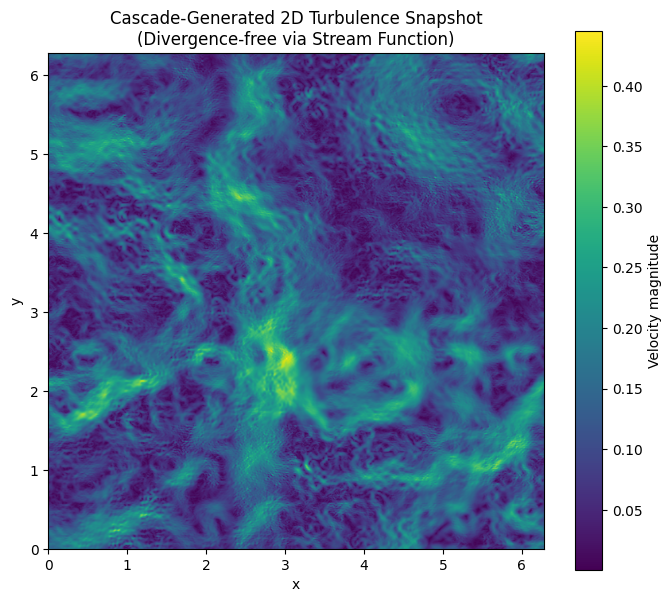

In [351]:
v_x = z_order_to_normal_torch(vx.full().flatten(),2**10,2**10)
v_y = z_order_to_normal_torch(vy.full().flatten(),2**10,2**10)

tn.save(v_x, './data/snapshots/vx_vector_2d.pt')
tn.save(v_y, './data/snapshots/vy_vector_2d.pt')

speed = np.sqrt(v_x**2 + v_y**2)
# Plot velocity magnitude
plt.figure(figsize=(8, 7))
plt.imshow(speed, origin="lower", extent=[0, 2 * np.pi, 0, 2 * np.pi], cmap="viridis")
plt.colorbar(label="Velocity magnitude")
plt.title(
    "Cascade-Generated 2D Turbulence Snapshot\n(Divergence-free via Stream Function)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [30]:
# compute vorticity
nscales = 10
eps = 1e-8
h = 2*np.pi/2**nscales
D = (P_qtt( 2**nscales -1, nscales) - P_qtt(1,nscales))/(2*h)
D = D.round(1e-15)
I = I_qtt(nscales)
D3x = zkron3(D,I,I)
D3y = zkron3(I,D,I)
D3z = zkron3(I,I,D)

def qttrot(vx,vy,vz,eps=1e-15):
    # compute vorticity
    wx = (D3y @ vz - D3z @ vy).round(eps)
    wy = (D3z @ vx - D3x @ vz).round(eps)
    wz = (D3x @ vy - D3y @ vx).round(eps)

    return wx, wy, wz


In [ ]:

Ax = tntt.TT( tn.load('./data/snapshots/3dx.pt') )
Ay = tntt.TT( tn.load('./data/snapshots/3dy.pt') )
Az = tntt.TT( tn.load('./data/snapshots/3dz.pt') )

vx, vy, vz = qttrot(Ax,Ay,Az,eps=eps)
wx, wy, wz = qttrot(vx,vy,vz,eps=eps)
tn.save(wx.cores, './data/snapshots/wx_3d.pt')
tn.save(wy.cores, './data/snapshots/wy_3d.pt')
tn.save(wz.cores, './data/snapshots/wz_3d.pt')

In [ ]:
N = 2**nscales
w_x = np.zeros((N, N, N), dtype=np.float64)
w_y = np.zeros((N, N, N), dtype=np.float64)
w_z = np.zeros((N, N, N), dtype=np.float64)
w_x = z_order_to_normal_nopara(wx.full().cpu().numpy().ravel(),
                                w_x, N, N, N)
w_y = z_order_to_normal_nopara(wy.full().cpu().numpy().ravel(),
                                w_y, N, N, N)
w_z = z_order_to_normal_nopara(wz.full().cpu().numpy().ravel(),
                                w_z, N, N, N)

speed = np.sqrt(w_x**2 + w_y**2 + w_z**2)

In [ ]:
# Plot velocity magnitude
plt.figure(figsize=(8, 7))
plt.imshow(speed, origin="lower", extent=[0, 2 * np.pi, 0, 2 * np.pi], cmap="viridis")
plt.colorbar(label="Velocity magnitude")
plt.title(
    "Cascade-Generated 2D Turbulence Snapshot\n(Divergence-free via Stream Function)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

TT with sizes and ranks:
N = [8, 8, 8, 8, 8, 8, 8, 8, 8, 8]
R = [1, 8, 64, 512, 2261, 2075, 1524, 506, 64, 8, 1]

Device: cpu, dtype: torch.float64
#entries 78790744 compression 0.07337959855794907

In [ ]:
epsilon=10
nrank=15
var=1
eps=1e-14
nscales=10
L = 2 * np.pi
N = 2**nscales
Ax, Ay, Az = gen_TT_cascade_3d(
        Nscales=nscales, nrank=nrank, levels=None, seed=None,
        epsilon=epsilon, method='skc', 
        eps=eps, var=var, boundary='periodic', order=2
    )

#A_x = z_order_to_normal_nopara(Ax.full().cpu().numpy().ravel(), np.zeros((N, N, N)), N, N, N)
#A_y = z_order_to_normal_nopara(Ay.full().cpu().numpy().ravel(), np.zeros((N, N, N)), N, N, N)
#A_z = z_order_to_normal_nopara(Az.full().cpu().numpy().ravel(), np.zeros((N, N, N)), N, N, N)

tn.save(Ax.cores, './data/snapshots/vx_r5.pt')
tn.save(Ay.cores, './data/snapshots/vy_r5.pt')
tn.save(Az.cores, './data/snapshots/vz_r5.pt')


In [29]:
erank(Ax.R, Ax.N)

np.float64(580.5753449499579)

In [ ]:

def kol_scaling(mps):
    base_scaling = 2.0 ** (-4.0 / 3.0)
    cores = mps.cores
    L = len(cores)
    lastcore = cores[-1]
    for j in range(1,8):
        lastcore[:,j,:] = lastcore[:,j,:] * base_scaling**L
    lastcore[:,0,:] = tn.zeros_like(lastcore[:,0,:]) 
    new_cores = cores[:-1] + [lastcore] 
    
    return tntt.TT(new_cores)

def gen_TT_c_3d(Nscales=10, nint=2, nrank=10, levels=None, seed=None,epsilon=0.1 , method = 'skc', fnoise = None, eps=1e-10,var=1,boundary='periodic',order=1):

    if levels is None:
        levels = Nscales
    if seed is not None:
        tn.manual_seed(seed)
    if fnoise == None:
        fnoise = 'gaussian'
    ni = nint
    ncoarse = Nscales - ni

    # Initialize the stream function uniformly.
    base_scaling = 2.0 ** (-4.0 / 3.0)
    psix = 1+ epsilon*(base_scaling**ncoarse)*tntt.randn([8]*ncoarse,[1]+[nrank]*(ncoarse-1)+[1],var=var )
    psiy = 1+ epsilon*(base_scaling**ncoarse)*tntt.randn([8]*ncoarse,[1]+[nrank]*(ncoarse-1)+[1],var=var )
    psiz = 1+ epsilon*(base_scaling**ncoarse)*tntt.randn([8]*ncoarse,[1]+[nrank]*(ncoarse-1)+[1],var=var )
    for i in range(2,ncoarse):
        delta = dmps(0,ncoarse-i)
        delta3 = zkron3(delta,delta,delta)
        delta3 = tntt.ones([8]*(ncoarse-i))

        psix *= 1+epsilon*(base_scaling**i)*tntt.kron( tntt.randn([8]*i,[1]+[nrank]*(i-1)+[1],var=var  ), delta3 )
        psiy *= 1+epsilon*(base_scaling**i)*tntt.kron( tntt.randn([8]*i,[1]+[nrank]*(i-1)+[1],var=var  ), delta3 )
        psiz *= 1+epsilon*(base_scaling**i)*tntt.kron( tntt.randn([8]*i,[1]+[nrank]*(i-1)+[1],var=var  ), delta3 )

    coarse_mpsx = psix.round(eps)
    coarse_mpsy = psiy.round(eps)
    coarse_mpsz = psiz.round(eps)
    # Interpolate to full resolution using linear interpolation.
    if method =='linear':
        raise Exception('Not implemented')

    # Interpolate to full resolution using cuadratic interpolation.
    elif method == 'cuadratic':
        raise Exception('Not implemented')

    # Interpolate to full resolution using splines interpolation

    elif method == 'skc':
        smooth_mpsx = skcubic3d_i(coarse_mpsx,Nscales, fnoise, eps=eps, epsilon=epsilon, order=order, boundary=boundary)
        smooth_mpsy = skcubic3d_i(coarse_mpsy,Nscales, fnoise, eps=eps, epsilon=epsilon, order=order, boundary=boundary)
        smooth_mpsz = skcubic3d_i(coarse_mpsz,Nscales, fnoise, eps=eps, epsilon=epsilon, order=order, boundary=boundary)
    
    elif method == 'skq':
        smooth_mpsx = skquad3d_i(coarse_mpsx,Nscales, fnoise, eps=eps, epsilon=epsilon,boundary=boundary)
        smooth_mpsy = skquad3d_i(coarse_mpsy,Nscales, fnoise, eps=eps, epsilon=epsilon,boundary=boundary)
        smooth_mpsz = skquad3d_i(coarse_mpsz,Nscales, fnoise, eps=eps, epsilon=epsilon,boundary=boundary)

    psix = smooth_mpsx.round(eps) #+ epsilon*(base_scaling**Nscales)*tntt.randn([8]*Nscales,[1]+[nrank]*(Nscales-1)+[1],var=var )
    psiy = smooth_mpsy.round(eps) #+ epsilon*(base_scaling**Nscales)*tntt.randn([8]*Nscales,[1]+[nrank]*(Nscales-1)+[1],var=var )
    psiz = smooth_mpsz.round(eps) #+ epsilon*(base_scaling**Nscales)*tntt.randn([8]*Nscales,[1]+[nrank]*(Nscales-1)+[1],var=var )

    return psix, psiy,psiz


In [ ]:
nscales=6
epsilon=1
nrank=5
a,_,_ = gen_TT_c_3d(Nscales=nscales, nint=2,nrank=nrank, levels=None, seed=None,epsilon=epsilon , method = 'skc',fnoise=('gaussian',10),eps=1e-10,order=2,boundary='periodic')
A = z_order_to_normal_3d(a.full().flatten(),2**nscales,2**nscales,2**nscales)
show_slices(A, axes=(0, 1, 2), cmap='viridis')

In [ ]:
nscales=6
a,_,_ = gen_TT_cascade_3d(Nscales=nscales, nrank=10, levels=None, seed=None,epsilon=1 , method = 'skq',fnoise=('gaussian',10),eps=1e-10,order=2,boundary='periodic')
A = z_order_to_normal_3d(a.full().flatten(),2**nscales,2**nscales,2**nscales)
show_slices(A, axes=(0, 1, 2), cmap='viridis')

In [ ]:
tn.set_default_dtype(tn.float64)
eranks = []
max_rank = []
dims = []
eps = 1e-8
nrank = 5
for i in range(5,12):
    print(i)
    a,_,_ = gen_TT_cascade_3d(Nscales=i, nrank=nrank, levels=None, seed=None,epsilon=1 , method = 'skq',fnoise=('gaussian',nrank),eps=eps,boundary='periodic',order=2)
    dims.append(i)
    eranks.append(erank(a.R,a.N))
    max_rank.append(max(a.R))


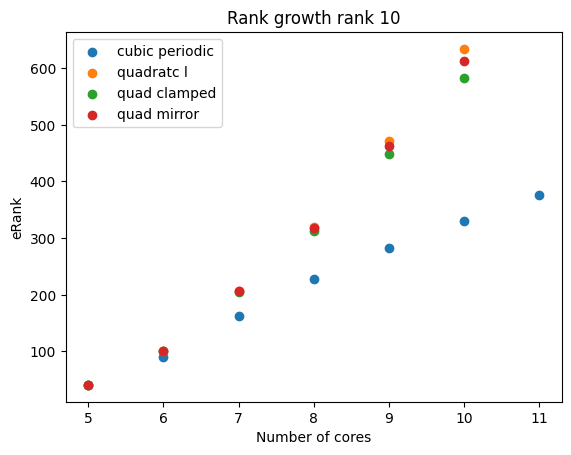

In [ ]:
plt.scatter( dims,eranks,label='cubic periodic')

# Load from files
with open("./data/bc/dims10ql.txt", "r") as f:
    dims_loaded = eval(f.read())

with open("./data/bc/er10ql.txt", "r") as f:
    eranks_loaded = eval(f.read())



# Plot
plt.scatter(dims_loaded, eranks_loaded,label='quadratc l ')

# Load from files
with open("./data/bc/dims10qc.txt", "r") as f:
    dims_loaded = eval(f.read())

with open("./data/bc/er10qc.txt", "r") as f:
    eranks_loaded = eval(f.read())

# Plot
plt.scatter(dims_loaded, eranks_loaded,label='quad clamped')

# Load from files
with open("./data/bc/dims10qm.txt", "r") as f:
    dims_loaded = eval(f.read())

with open("./data/bc/er10qm.txt", "r") as f:
    eranks_loaded = eval(f.read())

# Plot
plt.scatter(dims_loaded, eranks_loaded,label='quad mirror')

plt.xlabel('Number of cores')
plt.ylabel('eRank')
plt.title('Rank growth rank 10')
plt.legend()
plt.grid(False)
plt.show()


In [ ]:

with open("dims10c.txt", "w") as f:
    f.write(str(dims))

with open("er10c.txt", "w") as f:
    f.write(str(eranks))

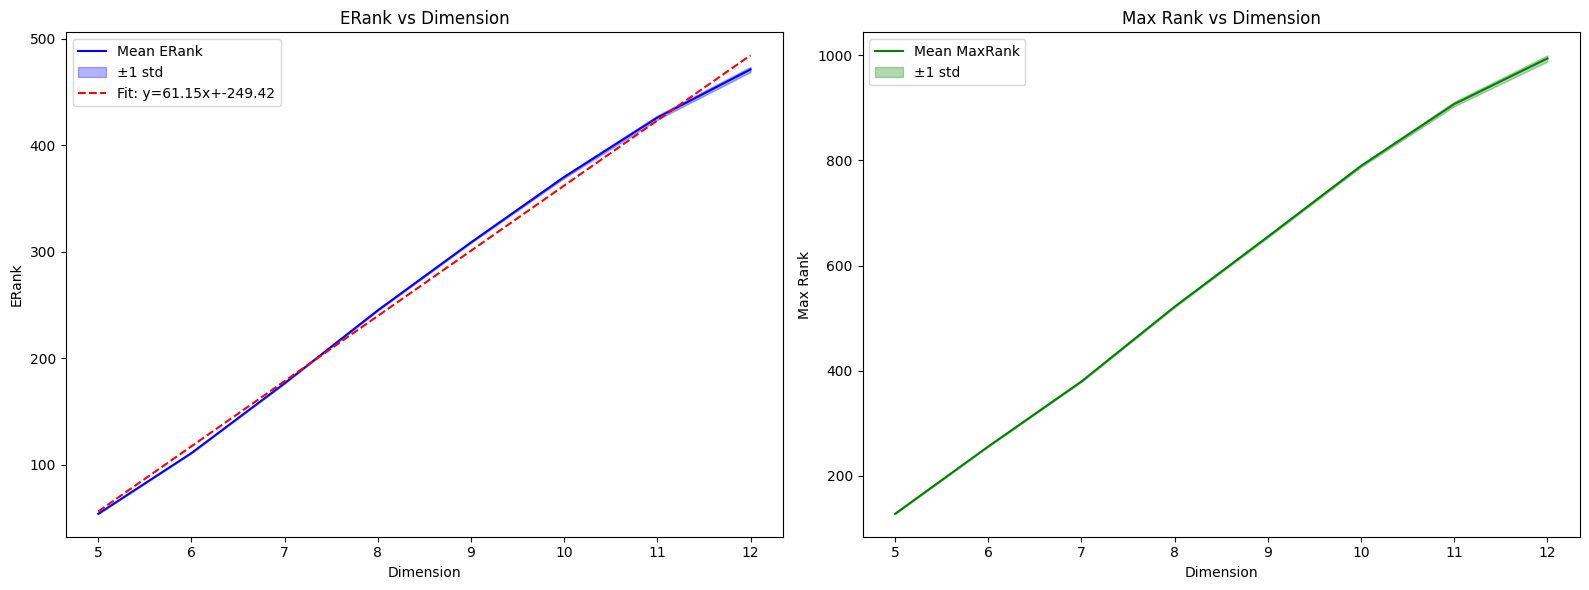

In [ ]:
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
dims, eranks, max_rank = [], [], []
samples_per_dim = 30
eps = 1e-9
nrank = 5

# Collecting at least 15 samples per dimension (5 times, 3 samples each)
for i in range(5, 13):
    for _ in range(samples_per_dim // 3):
        A = gen_TT_cascade_3d(Nscales=i, nrank=nrank, levels=None, seed=None,
                              epsilon=1, method='skq', fnoise=('gaussian', nrank), eps=eps, boundary='periodic',order=2)
        for j in range(3):
            dims.append(i)
            mps = A[j].to_qtt().round(eps)
            eranks.append( erank(mps.R, mps.N))
            max_rank.append(max(mps.R))

# DataFrame creation
data = pd.DataFrame({
    'Dimension': dims,
    'ERank': eranks,
    'MaxRank': max_rank
})

# Compute mean and standard deviation for error bars
data_grouped = data.groupby('Dimension').agg(['mean', 'std']).reset_index()


fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# ERank shaded region
x = data_grouped['Dimension']
y = data_grouped['ERank']['mean']
yerr = data_grouped['ERank']['std']
ax[0].plot(x, y, label='Mean ERank', color='blue')
ax[0].fill_between(x, y - yerr, y + yerr, alpha=0.3, color='blue', label='±1 std')

# Linear fit
slope, intercept, *_ = linregress(data['Dimension'], data['ERank'])
ax[0].plot(x, intercept + slope * x, 'r--', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')

ax[0].set_title('ERank vs Dimension')
ax[0].set_xlabel('Dimension')
ax[0].set_ylabel('ERank')
ax[0].legend()

# MaxRank shaded region
y2 = data_grouped['MaxRank']['mean']
yerr2 = data_grouped['MaxRank']['std']
ax[1].plot(x, y2, label='Mean MaxRank', color='green')
ax[1].fill_between(x, y2 - yerr2, y2 + yerr2, alpha=0.3, color='green', label='±1 std')

ax[1].set_title('Max Rank vs Dimension')
ax[1].set_xlabel('Dimension')
ax[1].set_ylabel('Max Rank')
ax[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
data.to_csv('./data/ranks5q_1em9_p.csv', index=False)

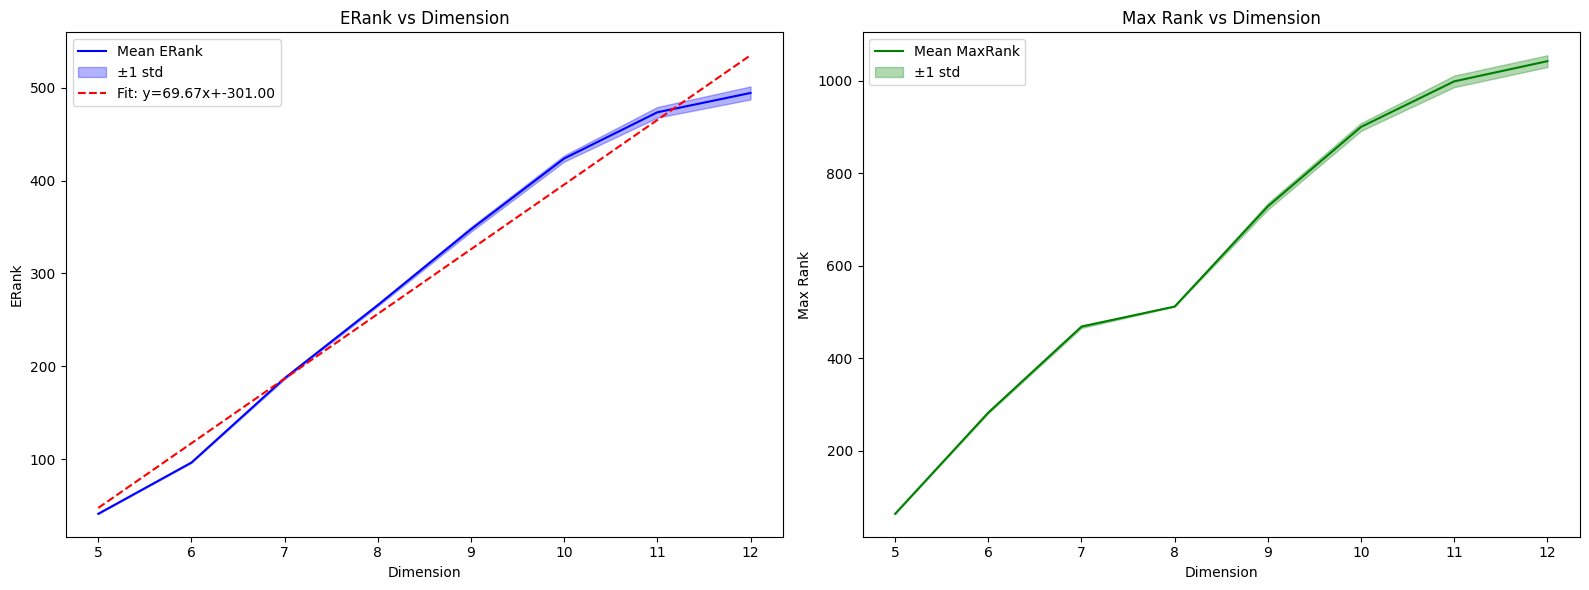

In [ ]:
# Re-import required libraries after environment reset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Load and merge the CSV files
df1 = pd.read_csv("ranks5c_1em8.csv")
df2 = pd.read_csv("ranks5c_1em8_1.csv")

merged_df = pd.concat([df1, df2], ignore_index=True)

# Group by Dimension and compute mean and std
grouped = merged_df.groupby('Dimension').agg(['mean', 'std']).reset_index()

# Plotting with shaded error bands
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# ERank shaded plot
x = grouped['Dimension']
y = grouped['ERank']['mean']
yerr = grouped['ERank']['std']
ax[0].plot(x, y, label='Mean ERank', color='blue')
ax[0].fill_between(x, y - yerr, y + yerr, alpha=0.3, color='blue', label='±1 std')

# Linear regression line
slope, intercept, *_ = linregress(merged_df['Dimension'], merged_df['ERank'])
ax[0].plot(x, intercept + slope * x, 'r--', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')

ax[0].set_title('ERank vs Dimension')
ax[0].set_xlabel('Dimension')
ax[0].set_ylabel('ERank')
ax[0].legend()

# MaxRank shaded plot
y2 = grouped['MaxRank']['mean']
yerr2 = grouped['MaxRank']['std']
ax[1].plot(x, y2, label='Mean MaxRank', color='green')
ax[1].fill_between(x, y2 - yerr2, y2 + yerr2, alpha=0.3, color='green', label='±1 std')

ax[1].set_title('Max Rank vs Dimension')
ax[1].set_xlabel('Dimension')
ax[1].set_ylabel('Max Rank')
ax[1].legend()

plt.tight_layout()
plt.show()

# Save final merged dataset
merged_df.to_csv("./data/ranksc_1em8.csv", index=False)




### mps 2d cascade

#### value noise fractal perlin like

In [104]:
utt

TT with sizes and ranks:
N = [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
R = [1, 4, 16, 36, 36, 36, 36, 36, 36, 16, 4, 1]

Device: cpu, dtype: torch.float64
#entries 31072 compression 0.00740814208984375

In [101]:
gen_TT_cascade(Nscales=nscales,nrank=nrank, levels=None, seed=seed,epsilon= epsilon , method = 'skc',fnoise=('gaussian',nrank),eps=eps,boundary='periodic',order=2,field='velocity')

(TT with sizes and ranks:
 N = [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
 R = [1, 4, 16, 64, 256, 210, 152, 94, 42, 16, 4, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 488528 compression 0.11647415161132812,
 TT with sizes and ranks:
 N = [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
 R = [1, 4, 16, 64, 256, 210, 152, 94, 42, 16, 4, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 488528 compression 0.11647415161132812)

In [122]:
gen_TT_cascade(Nscales=nscales, nrank=nrank,levels=None, seed=None,epsilon= epsilon , method = 'skc',fnoise=('gaussian',nrank),eps=eps,boundary='periodic',order=2)

TT with sizes and ranks:
N = [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
R = [1, 4, 16, 64, 148, 115, 82, 49, 16, 4, 1]

Device: cpu, dtype: torch.float64
#entries 167536 compression 0.1597747802734375

TT with sizes and ranks:
N = [4, 4, 4, 4]
R = [1, 10, 10, 10, 1]

Device: cpu, dtype: torch.float64
#entries 880 compression 3.4375

1 0.3968502629920499
2 0.15749013123685918
3 0.06250000000000001
4 0.024803141437003122
1 0.7937005259840998
2 0.6299605249474367
3 0.5000000000000001
4 0.39685026299204995
5 0.3149802624737184
6 0.2500000000000001


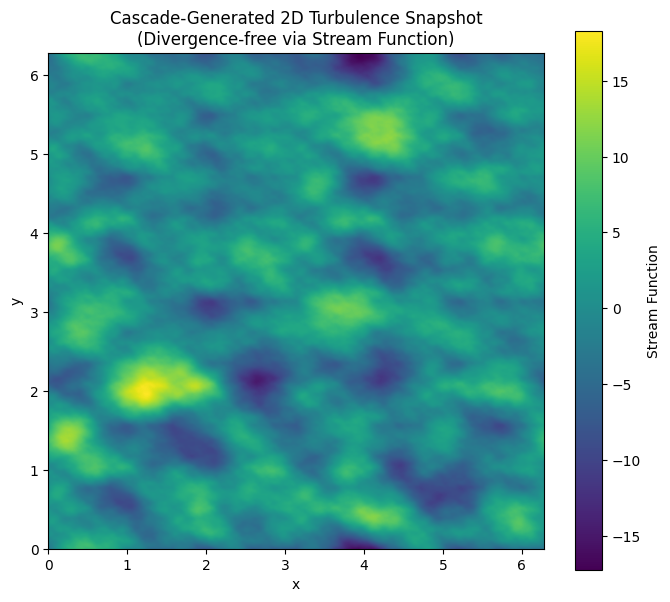

C:\Users\siddhartha.morales\AppData\Local\Temp\ipykernel_532\1116278702.py:45: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  speed = np.sqrt(u**2 + v**2)


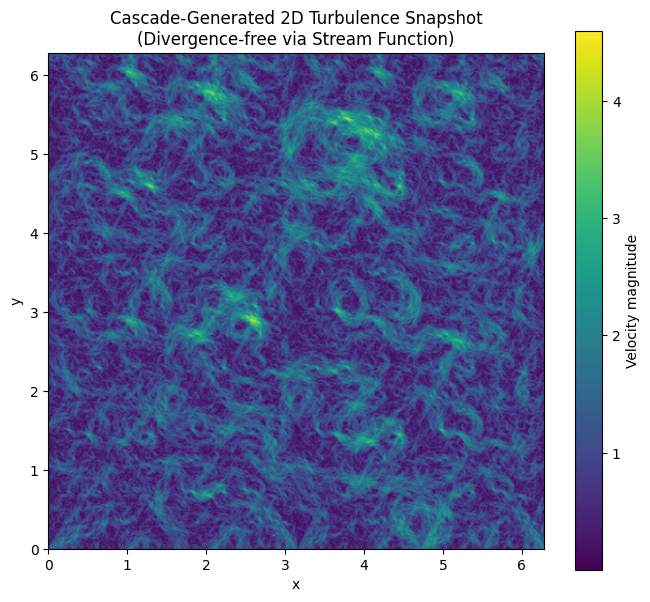

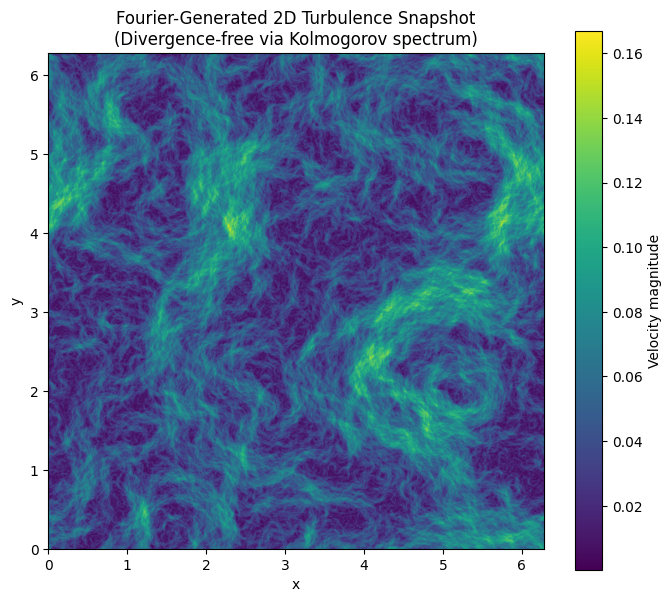

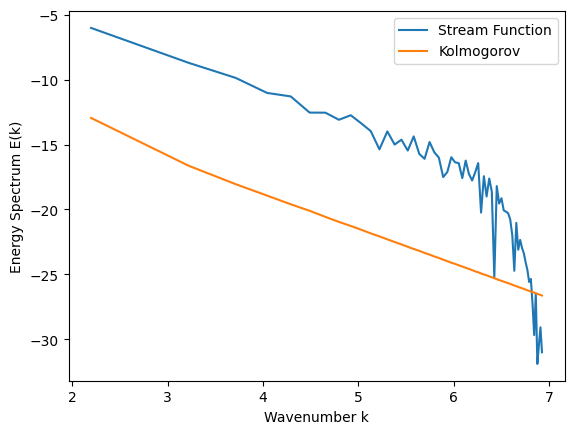

In [103]:
nscales = 11
N = 2**nscales
L = 2 * np.pi
seed = 42
nrank = 10
epsilon = 10
eps = 1e-10
psiM = gen_TT_cascade_p(Nscales=nscales, nrank=nrank, noise_scale=4,noctaves=5,levels=None, seed=None,epsilon= epsilon , method = 'skc',fnoise=('gaussian',nrank),eps=eps,boundary='periodic',order=2)
psi = z_order_to_normal_torch(psiM.full().reshape(-1),2**nscales,2**nscales)
#u, v = compute_velocity_from_stream_function(psi, L=2 * np.pi)

utt, vtt = gen_TT_cascade_p(Nscales=nscales, noise_scale=4,noctaves=7,nrank=nrank, levels=None, seed=seed,epsilon= epsilon , method = 'skc',fnoise=('gaussian',nrank),eps=eps,boundary='periodic',order=2,field='velocity')
u = z_order_to_normal_torch(utt.full().reshape(-1),2**nscales,2**nscales)/L
v = z_order_to_normal_torch(vtt.full().reshape(-1),2**nscales,2**nscales)/L

# Plot stream function
plt.figure(figsize=(8, 7))
plt.imshow(
    psi,
    origin="lower",
    extent=[0, 2 * np.pi, 0, 2 * np.pi],
    cmap="viridis",
)
plt.colorbar(label="Stream Function")
plt.title(
    "Cascade-Generated 2D Turbulence Snapshot\n(Divergence-free via Stream Function)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()
# %% Compute velocity field from ψ
#u, v = compute_velocity_from_stream_function(psi, L=2 * np.pi)

uk, vk = generate_divergence_free_kolmogorov_2d(
    N=N,
    L=2 * np.pi,
    exponent=-5 / 3,
    seed=seed,
)
uk = uk * 1e5
vk = vk * 1e5

# %%
# Compute velocity magnitude
speed = np.sqrt(u**2 + v**2)
speed = speed / speed.mean()
speedk = np.sqrt(uk**2 + vk**2)

# Plot velocity magnitude
plt.figure(figsize=(8, 7))
plt.imshow(speed, origin="lower", extent=[0, 2 * np.pi, 0, 2 * np.pi], cmap="viridis")
plt.colorbar(label="Velocity magnitude")
plt.title(
    "Cascade-Generated 2D Turbulence Snapshot\n(Divergence-free via Stream Function)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()
# Plot velocity magnitude
plt.figure(figsize=(8, 7))
plt.imshow(speedk, origin="lower", extent=[0, 2 * np.pi, 0, 2 * np.pi], cmap="viridis")
plt.colorbar(label="Velocity magnitude")
plt.title(
    "Fourier-Generated 2D Turbulence Snapshot\n(Divergence-free via Kolmogorov spectrum)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# %% Plot velocity streamlines
# x = np.linspace(0, 2 * np.pi, N)
# X, Y = np.meshgrid(x, x)

# plt.figure(figsize=(8, 7))
# plt.streamplot(
#     X,
#     Y,
#     u.T,
#     v.T,
#     density=1,
#     color=speed.T,
#     cmap="viridis",
#     broken_streamlines=False,
# )
# plt.colorbar(label="Velocity magnitude")
# plt.title(
#     "Cascade-Generated 2D Turbulence Snapshot\n(Divergence-free via Stream Function)"
# )
# plt.xlabel("x")
# plt.ylabel("y")
# plt.show()

# %% Compute the energy spectrum
# 1. Compute FFT
u_hat = np.fft.fft2(u)
v_hat = np.fft.fft2(v)
# 1. Compute FFT
uk_hat = np.fft.fft2(uk)
vk_hat = np.fft.fft2(vk)

# 2. Compute 2D energy density (example normalization)
# Adjust normalization based on your needs/FFT definition
E_hat_normalized = (np.abs(u_hat) ** 2 + np.abs(v_hat) ** 2) / (N**4)
Ek_hat_normalized = (np.abs(uk_hat) ** 2 + np.abs(vk_hat) ** 2) / (N**4)

# 3. Get wavenumbers (kx, ky)
# Using fftfreq helps handle periodicity and shifting correctly
# Need to scale by 2*pi/L to get physical wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # d is sample spacing
kx_grid, ky_grid = np.meshgrid(k, k)

# 4. Calculate wavenumber magnitude (k)
# Apply fftshift *before* calculating magnitudes if you want k=0 at the center
kx_shifted = np.fft.fftshift(kx_grid)
ky_shifted = np.fft.fftshift(ky_grid)
k_magnitude = np.sqrt(kx_shifted**2 + ky_shifted**2)

# Also shift the energy density to match the shifted wavenumbers
E_hat_shifted = np.fft.fftshift(E_hat_normalized)
Ek_hat_shifted = np.fft.fftshift(Ek_hat_normalized)

# 5. Radial Averaging (Binning)
# Define k bins (e.g., linear or log spacing)
k_min = 1.0  # Or slightly larger to avoid zero frequency if needed
k_max = np.max(k_magnitude) // np.sqrt(2)
num_bins = N // 32  # Example: up to Nyquist frequency
k_bins = np.linspace(k_min, k_max, num_bins + 1)
k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])

E_k = np.zeros_like(k_centers)
E_k2 = np.zeros_like(k_centers)
counts = np.zeros_like(k_centers, dtype=int)
counts2 = np.zeros_like(k_centers, dtype=int)

# Loop through grid points (or use histogram/binned_statistic)
for i in range(N):
    for j in range(N):
        k_val = k_magnitude[i, j]
        # Find which bin k_val belongs to
        bin_index = np.searchsorted(k_bins, k_val) - 1
        if 0 <= bin_index < num_bins:
            E_k[bin_index] += E_hat_shifted[i, j]
            E_k2[bin_index] += Ek_hat_shifted[i, j]
            counts[bin_index] += 1

# Avoid division by zero for empty bins
valid_bins = counts > 0
E_k[valid_bins] /= counts[valid_bins]
E_k2[valid_bins] /= counts[valid_bins]

# E_k now holds the 1D radially averaged energy spectrum
# k_centers holds the corresponding wavenumber bin centers

# %% 6. Plot (e.g., using matplotlib)
plt.plot(
    np.log(k_centers[valid_bins]), np.log(E_k[valid_bins]), label="Stream Function"
)
plt.plot(np.log(k_centers[valid_bins]), np.log(E_k2[valid_bins]), label="Kolmogorov")

plt.xlabel("Wavenumber k")
plt.ylabel("Energy Spectrum E(k)")
plt.legend()
plt.show()


#### chatgpt algorithm

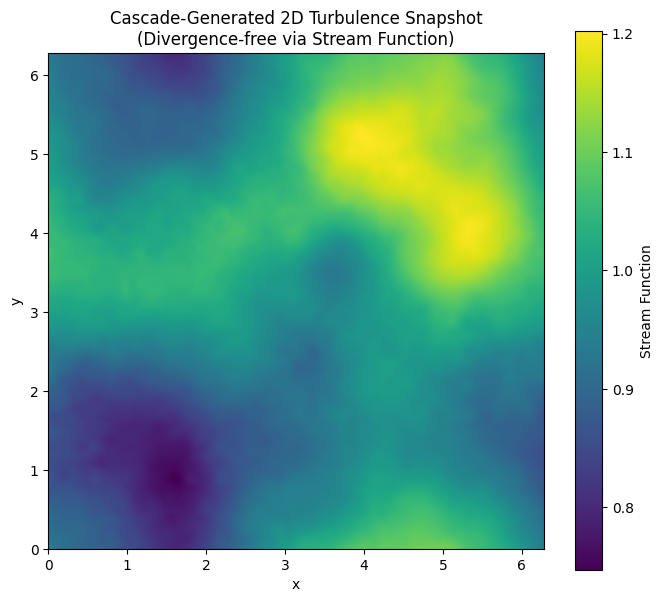

C:\Users\siddhartha.morales\AppData\Local\Temp\ipykernel_15328\4241043756.py:44: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  speed = np.sqrt(u**2 + v**2)


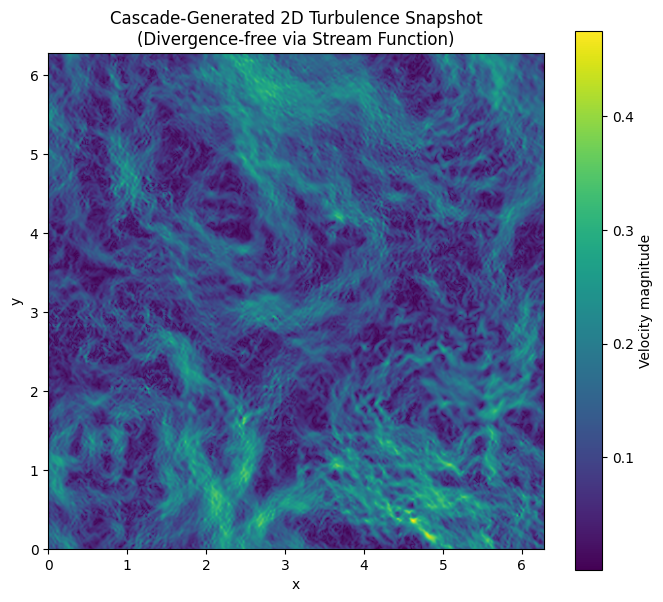

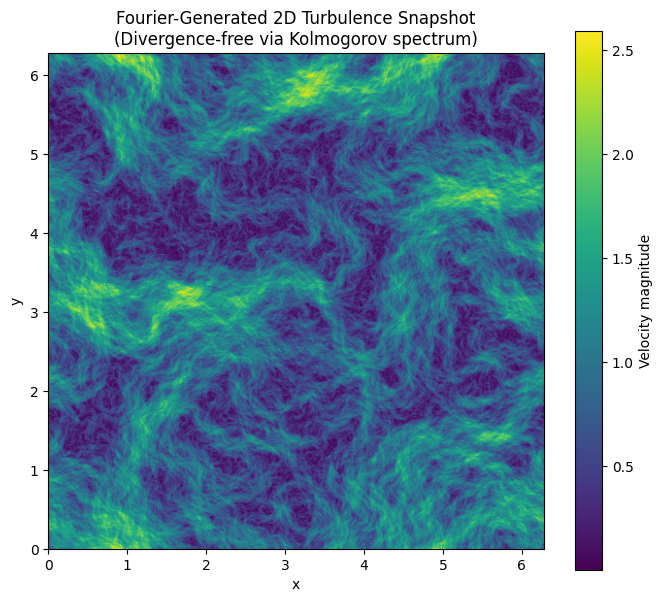

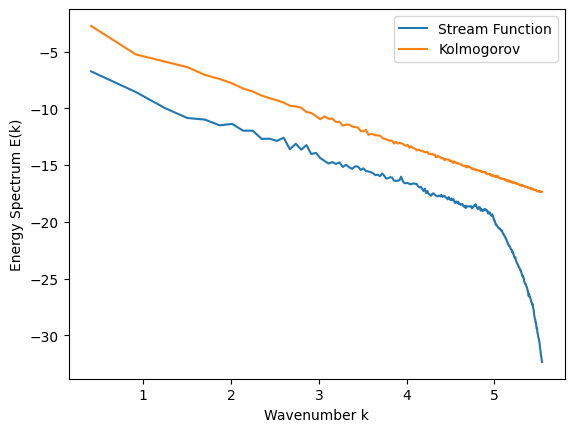

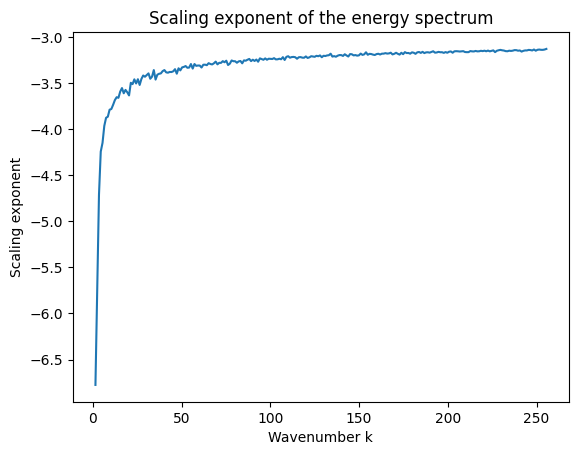

Median scaling exponent: -3.2076032596294706
9
fft done.
fft normalized.
Start binning.


IndexError: boolean index did not match indexed array along axis 0; size of axis is 512 but size of corresponding boolean axis is 9

In [ ]:
nscales = 9
N = 2**nscales
L = 2 * np.pi
seed = 42
nrank = 10
epsilon = 1
eps = 1e-9
psi = gen_TT_cascade(Nscales=nscales, nrank=nrank, levels=None, seed=None,epsilon= epsilon , method = 'skc',fnoise=('gaussian',nrank),eps=eps,boundary='periodic',order=2)
psi = z_order_to_normal_torch(psi.full().reshape(-1),2**nscales,2**nscales)

u, v = gen_TT_cascade(Nscales=nscales, nrank=nrank, levels=None, seed=seed,epsilon= epsilon , method = 'skc',fnoise=('gaussian',nrank),eps=eps,boundary='periodic',order=2,field='velocity')
u = z_order_to_normal_torch(u.full().reshape(-1),2**nscales,2**nscales)/L
v = z_order_to_normal_torch(v.full().reshape(-1),2**nscales,2**nscales)/L

# Plot stream function
plt.figure(figsize=(8, 7))
plt.imshow(
    psi,
    origin="lower",
    extent=[0, 2 * np.pi, 0, 2 * np.pi],
    cmap="viridis",
)
plt.colorbar(label="Stream Function")
plt.title(
    "Cascade-Generated 2D Turbulence Snapshot\n(Divergence-free via Stream Function)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()
# %% Compute velocity field from ψ
#u, v = compute_velocity_from_stream_function(psi, L=2 * np.pi)

uk, vk = generate_divergence_free_kolmogorov_2d(
    N=N,
    L=2 * np.pi,
    exponent=-5 / 3,
    seed=seed,
)
uk = uk * 1e5
vk = vk * 1e5

# %%
# Compute velocity magnitude
speed = np.sqrt(u**2 + v**2)
speedk = np.sqrt(uk**2 + vk**2)

# Plot velocity magnitude
plt.figure(figsize=(8, 7))
plt.imshow(speed, origin="lower", extent=[0, 2 * np.pi, 0, 2 * np.pi], cmap="viridis")
plt.colorbar(label="Velocity magnitude")
plt.title(
    "Cascade-Generated 2D Turbulence Snapshot\n(Divergence-free via Stream Function)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()
# Plot velocity magnitude
plt.figure(figsize=(8, 7))
plt.imshow(speedk, origin="lower", extent=[0, 2 * np.pi, 0, 2 * np.pi], cmap="viridis")
plt.colorbar(label="Velocity magnitude")
plt.title(
    "Fourier-Generated 2D Turbulence Snapshot\n(Divergence-free via Kolmogorov spectrum)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# %% Plot velocity streamlines
# x = np.linspace(0, 2 * np.pi, N)
# X, Y = np.meshgrid(x, x)

# plt.figure(figsize=(8, 7))
# plt.streamplot(
#     X,
#     Y,
#     u.T,
#     v.T,
#     density=1,
#     color=speed.T,
#     cmap="viridis",
#     broken_streamlines=False,
# )
# plt.colorbar(label="Velocity magnitude")
# plt.title(
#     "Cascade-Generated 2D Turbulence Snapshot\n(Divergence-free via Stream Function)"
# )
# plt.xlabel("x")
# plt.ylabel("y")
# plt.show()

# %% Compute the energy spectrum
# 1. Compute FFT
u_hat = np.fft.fft2(u)
v_hat = np.fft.fft2(v)
# 1. Compute FFT
uk_hat = np.fft.fft2(uk)
vk_hat = np.fft.fft2(vk)

# 2. Compute 2D energy density (example normalization)
# Adjust normalization based on your needs/FFT definition
E_hat_normalized = (np.abs(u_hat) ** 2 + np.abs(v_hat) ** 2) / (N**4)
Ek_hat_normalized = (np.abs(uk_hat) ** 2 + np.abs(vk_hat) ** 2) / (N**4)

# 3. Get wavenumbers (kx, ky)
# Using fftfreq helps handle periodicity and shifting correctly
# Need to scale by 2*pi/L to get physical wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # d is sample spacing
kx_grid, ky_grid = np.meshgrid(k, k)

# 4. Calculate wavenumber magnitude (k)
# Apply fftshift *before* calculating magnitudes if you want k=0 at the center
kx_shifted = np.fft.fftshift(kx_grid)
ky_shifted = np.fft.fftshift(ky_grid)
k_magnitude = np.sqrt(kx_shifted**2 + ky_shifted**2)

# Also shift the energy density to match the shifted wavenumbers
E_hat_shifted = np.fft.fftshift(E_hat_normalized)
Ek_hat_shifted = np.fft.fftshift(Ek_hat_normalized)

# 5. Radial Averaging (Binning)
# Define k bins (e.g., linear or log spacing)
k_min = 1.0  # Or slightly larger to avoid zero frequency if needed
k_max = np.max(k_magnitude) // np.sqrt(2)
num_bins = N // 4  # Example: up to Nyquist frequency
k_bins = np.linspace(k_min, k_max, num_bins + 1)
k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])

E_k = np.zeros_like(k_centers)
E_k2 = np.zeros_like(k_centers)
counts = np.zeros_like(k_centers, dtype=int)
counts2 = np.zeros_like(k_centers, dtype=int)

# Loop through grid points (or use histogram/binned_statistic)
for i in range(N):
    for j in range(N):
        k_val = k_magnitude[i, j]
        # Find which bin k_val belongs to
        bin_index = np.searchsorted(k_bins, k_val) - 1
        if 0 <= bin_index < num_bins:
            E_k[bin_index] += E_hat_shifted[i, j]
            E_k2[bin_index] += Ek_hat_shifted[i, j]
            counts[bin_index] += 1

# Avoid division by zero for empty bins
valid_bins = counts > 0
E_k[valid_bins] /= counts[valid_bins]
E_k2[valid_bins] /= counts[valid_bins]

# E_k now holds the 1D radially averaged energy spectrum
# k_centers holds the corresponding wavenumber bin centers

# %% 6. Plot (e.g., using matplotlib)
plt.plot(
    np.log(k_centers[valid_bins]), np.log(E_k[valid_bins]), label="Stream Function"
)
plt.plot(np.log(k_centers[valid_bins]), np.log(E_k2[valid_bins]), label="Kolmogorov")

plt.xlabel("Wavenumber k")
plt.ylabel("Energy Spectrum E(k)")
plt.legend()
plt.show()

# %%
scaling = np.log2(E_k2[valid_bins]) / np.log2(k_centers[valid_bins])
plt.plot(k_centers[valid_bins], scaling)
plt.xlabel("Wavenumber k")
plt.ylabel("Scaling exponent")
plt.title("Scaling exponent of the energy spectrum")
plt.show()

print("Median scaling exponent:", np.median(scaling))
# %%
#################################################
# Stefano's code to compute the energy spectrum #
#################################################
N = 9
dim = 2**N

u, v = generate_divergence_free_kolmogorov_2d(
    N=dim,
    L=2 * np.pi,
    exponent=-5 / 3,
    seed=42,
)
# %%
dim = N
print(dim)
L = 2 * np.pi

uu_fft = np.fft.fft2(uk)
vv_fft = np.fft.fft2(vk)
print("fft done.")

uu_fft = (np.abs(uu_fft) / dim**2) ** 2
vv_fft = (np.abs(vv_fft) / dim**2) ** 2
print("fft normalized.")

k_end = int(dim / 2)
rx = np.array(range(dim)) - dim / 2 + 1
rx = np.roll(rx, int(dim / 2) + 1)

r = np.zeros((rx.shape[0], rx.shape[0]))
for i in range(rx.shape[0]):
    for j in range(rx.shape[0]):
        r[i, j] = rx[i] ** 2 + rx[j] ** 2
r = np.sqrt(r)

dx = 2 * np.pi / L
k = (np.array(range(k_end)) + 1) * dx

print("Start binning.")
bins = np.zeros((k.shape[0] + 1))
for N in range(k_end):
    if N == 0:
        bins[N] = 0
    else:
        bins[N] = (k[N] + k[N - 1]) / 2
bins[-1] = k[-1]

inds = tn.bucketize(tn.tensor(r * dx), tn.tensor(bins)).numpy()
spectrum = np.zeros((k.shape[0]))
bin_counter = np.zeros((k.shape[0]))

for N in range(k_end):
    spectrum[N] = np.sum(uu_fft[inds == N + 1]) + np.sum(vv_fft[inds == N + 1])
    bin_counter[N] = np.count_nonzero(inds == N + 1)

spectrum = spectrum * 2 * np.pi * (k**2) / (bin_counter * dx**2)
print("Spectrum obtained.")
# %%
plt.plot(np.log(k), np.log(spectrum))
plt.plot(np.log(k), (-5 / 3) * np.log(k) - 5, label="k^(-5/3)", linestyle="--")
plt.xlabel("log(k)")
plt.ylabel("log(E(k))")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ------------------------------
# Parameters (assumes u_field is available)
# ------------------------------
# u_field is assumed to be a torch tensor of shape (3, N, N, N) from the previous synthesis code.
# For example, u_field[0] is the x‐component.
##u_field_cpu = u_field.cpu()  # move to CPU if not already
u_field_cpu = tn.tensor(u, dtype=tn.float64)
N = u_field_cpu.shape[1]
L = 2 * np.pi               # domain length [0, 2π]
dx = L / N                  # grid spacing in physical units

# ------------------------------
# Compute Structure Functions and Generalized Kurtosis
# ------------------------------
# We compute the longitudinal velocity increments along the x-direction.
# For a given separation r, we compute:
#    δu(r) = u(x + r) − u(x)
# and then average over the entire domain to get the structure functions:
#    S_p(r) = ⟨|δu(r)|^p⟩.
#
# The generalized kurtosis (for p = 4) is defined as:
#    Flatness = Γ₄(r) = S₄(r) / [S₂(r)]².

# Extract the x–component as a NumPy array.
u_x = u_field_cpu[0].numpy()  # shape (N, N, N)

max_shift = N // 2           # use up to half the domain to avoid finite-size artifacts
num_lags = max_shift         # lags index from 1 to max_shift
lags = np.arange(1, num_lags + 1) * dx  # physical separation distances

S2 = np.zeros(num_lags)
S4 = np.zeros(num_lags)

# Loop over various lag distances (shifts) along the x-axis.
for n in range(1, num_lags + 1):
    # Compute increments with a periodic (circular) shift in the x-direction.
    # np.roll handles the periodicity.
    delta_u = u_x - np.roll(u_x, shift=-n, axis=0)
    # Compute the 2nd-order structure function: S₂(n*dx)
    S2[n - 1] = np.mean(delta_u**2)
    # Compute the 4th-order structure function: S₄(n*dx)
    S4[n - 1] = np.mean(delta_u**4)

# Compute generalized kurtosis (flatness).
flatness = S4 / (S2**2)

# ------------------------------
# Plotting the Generalized Kurtosis (Intermittency)
# ------------------------------
plt.figure(figsize=(8, 6))
plt.loglog(lags, flatness, 'o-', label='Generalized Kurtosis (Flatness)')
plt.xlabel('Separation r')
plt.ylabel('Flatness = S₄ / (S₂)²')
plt.title('Scale-Dependent Flatness (Intermittency) of uₓ Increments')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

### mps 3d cscade

In [ ]:
tn.set_default_dtype(tn.float64)


def compute_velocity_from_vector_potential(A_x, A_y, A_z, L=2 * np.pi):
    """
    Compute the velocity field (u,v,w) from a vector potential A = (A_x, A_y, A_z)
    using central finite differences to approximate the curl.
    
    In 3D, the curl is given by:
      u = dA_z/dy - dA_y/dz,
      v = dA_x/dz - dA_z/dx,
      w = dA_y/dx - dA_x/dy.
    
    Parameters:
      A_x, A_y, A_z : 3D arrays for the vector potential components.
      L             : Physical domain size (assumed cubic: [0, L]^3).
      
    Returns:
      u, v, w       : 3D arrays of velocity components.
    """
    N = A_x.shape[0]
    dx = L / N  # assuming dx = dy = dz
    u = np.zeros_like(A_x)
    v = np.zeros_like(A_x)
    w = np.zeros_like(A_x)
    
    # Compute derivatives using central differences for interior points.
    # u = dA_z/dy - dA_y/dz
    u[1:-1, 1:-1, 1:-1] = ((A_z[1:-1, 2:, 1:-1] - A_z[1:-1, :-2, 1:-1]) -
                           (A_y[1:-1, 1:-1, 2:] - A_y[1:-1, 1:-1, :-2])) / (2 * dx)
    # v = dA_x/dz - dA_z/dx
    v[1:-1, 1:-1, 1:-1] = ((A_x[1:-1, 1:-1, 2:] - A_x[1:-1, 1:-1, :-2]) -
                           (A_z[2:, 1:-1, 1:-1] - A_z[:-2, 1:-1, 1:-1])) / (2 * dx)
    # w = dA_y/dx - dA_x/dy
    w[1:-1, 1:-1, 1:-1] = ((A_y[2:, 1:-1, 1:-1] - A_y[:-2, 1:-1, 1:-1]) -
                           (A_x[1:-1, 2:, 1:-1] - A_x[1:-1, :-2, 1:-1])) / (2 * dx)
    return u, v, w


def generate_divergence_free_kolmogorov_3d(N=128, L=2 * np.pi, exponent=-5/3, seed=None):
    """
    Generate a 3D synthetic velocity field that is:
      - Divergence-free (incompressible).
      - Exhibits a power-law energy spectrum E(k) ~ k^(exponent).
        For a Kolmogorov-like spectrum in 3D, noting that E(k) ~ k^2 |u(k)|^2,
        the Fourier amplitude scales as |u(k)| ~ k^((exponent-2)/2).
    
    Parameters:
      N        : Number of grid points in each spatial direction.
      L        : Physical domain size (assumed cubic).
      exponent : Desired power-law exponent for the energy spectrum.
      seed     : Optional random seed for reproducibility.
      
    Returns:
      u, v, w  : 3D arrays (N x N x N) of the velocity components in real space.
    """
    if seed is not None:
        np.random.seed(seed)

    # 1) Set up wave numbers in Fourier space.
    kx = np.fft.fftfreq(N, d=L / N) * 2.0 * np.pi
    ky = np.fft.fftfreq(N, d=L / N) * 2.0 * np.pi
    kz = np.fft.fftfreq(N, d=L / N) * 2.0 * np.pi
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")
    k = np.sqrt(KX**2 + KY**2 + KZ**2)
    k[0, 0, 0] = 1.0  # avoid division by zero

    # 2) Compute the amplitude for each Fourier mode.
    # For 3D, |u(k)| ~ k^((exponent-2)/2).
    amp = k ** ((exponent - 2) / 2.0)
    amp[0, 0, 0] = 0.0  # remove the k=0 (mean flow) mode

    # 3) Generate random phases for the three velocity components.
    phase_x = np.exp(1j * 2.0 * np.pi * np.random.rand(N, N, N))
    phase_y = np.exp(1j * 2.0 * np.pi * np.random.rand(N, N, N))
    phase_z = np.exp(1j * 2.0 * np.pi * np.random.rand(N, N, N))
    w_x = amp * phase_x
    w_y = amp * phase_y
    w_z = amp * phase_z

    # 4) Enforce the divergence-free condition via projection.
    dot = KX * w_x + KY * w_y + KZ * w_z
    u_hat = w_x - (KX * dot) / (k**2)
    v_hat = w_y - (KY * dot) / (k**2)
    w_hat = w_z - (KZ * dot) / (k**2)

    # 5) Inverse FFT to obtain the velocity field in real space.
    u = np.fft.ifftn(u_hat).real
    v = np.fft.ifftn(v_hat).real
    w = np.fft.ifftn(w_hat).real

    return u, v, w


# %%
# %% Compute and plot the flatness for both approaches in log-log scale

def compute_flatness(u_field, max_sep, L):
    """
    Compute the flatness (kurtosis) of velocity increments in the x-direction for a 3D field.
    
    Parameters:
      u_field : 3D array (velocity component u).
      max_sep : Maximum separation (in grid points) to compute the increments.
      L       : Physical domain size.
    
    Returns:
      separations : 1D array of physical separation distances.
      flatness    : 1D array of flatness values at each separation.
    """
    N = u_field.shape[0]
    dx = L / N
    separations = np.arange(1, max_sep+1) * dx
    flatness = []
    for dr in range(1, max_sep+1):
        # Compute increments in the x-direction for all valid grid points.
        diff = u_field[dr:, :, :] - u_field[:-dr, :, :]
        S2 = np.mean(diff**2)
        S4 = np.mean(diff**4)
        flatness.append(S4 / (S2**2))

    return separations, np.array(flatness)

In [32]:
#numba functions
import numpy as np
import numba as nb
tn.set_default_dtype(tn.float64)
# 1) Velocity from vector potential
@nb.njit(parallel=True)
def compute_velocity_from_vector_potential(Ax, Ay, Az, L=2*np.pi):
    N = Ax.shape[0]
    inv2dx = N / (2.0 * L)  # = 1/(2*dx)
    u = np.empty_like(Ax)
    v = np.empty_like(Ax)
    w = np.empty_like(Ax)
    for i in nb.prange(1, N-1):
        for j in range(1, N-1):
            for k in range(1, N-1):
                u[i,j,k] = ((Az[i, j+1, k] - Az[i, j-1, k])
                           - (Ay[i, j, k+1] - Ay[i, j, k-1])) * inv2dx
                v[i,j,k] = ((Ax[i, j, k+1] - Ax[i, j, k-1])
                           - (Az[i+1, j, k] - Az[i-1, j, k])) * inv2dx
                w[i,j,k] = ((Ay[i+1, j, k] - Ay[i-1, j, k])
                           - (Ax[i, j+1, k] - Ax[i, j-1, k])) * inv2dx
    return u, v, w


# 2) Flatness computation
@nb.njit(parallel=True)
def compute_flatness(u, max_sep, L):
    N = u.shape[0]
    dx = L / N
    seps = np.empty(max_sep, dtype=np.float64)
    flats = np.empty(max_sep, dtype=np.float64)
    for dr in nb.prange(1, max_sep+1):
        seps[dr-1] = dr * dx
        diff = u[dr:, :, :] - u[:N-dr, :, :]
        # reduction in Numba:
        S2 = 0.0
        S4 = 0.0
        cnt = diff.size
        for idx in range(cnt):
            d = diff.flat[idx]
            S2 += d*d
            S4 += d*d*d*d
        S2 /= cnt
        S4 /= cnt
        flats[dr-1] = S4 / (S2*S2)
    return seps, flats


# 3) Kolmogorov‐field generator (hybrid Numba/NumPy)
def generate_divergence_free_kolmogorov_3d(N=128, L=2*np.pi, exponent=-5/3, seed=None):
    if seed is not None:
        np.random.seed(seed)

    # wave‑number grids (NumPy)
    k1 = np.fft.fftfreq(N, d=L/N) * 2*np.pi
    KX, KY, KZ = np.meshgrid(k1, k1, k1, indexing='ij')
    k2 = KX**2 + KY**2 + KZ**2
    k2[0,0,0] = 1.0

    # amplitude & random phases (NumPy)
    amp = k2**((exponent-2)/2.0)
    amp[0,0,0] = 0.0
    φx = np.exp(1j*2*np.pi*np.random.rand(N,N,N))
    φy = np.exp(1j*2*np.pi*np.random.rand(N,N,N))
    φz = np.exp(1j*2*np.pi*np.random.rand(N,N,N))

    wx = amp * φx
    wy = amp * φy
    wz = amp * φz

    # project to divergence‑free in k‑space (Numba helper)
    ux, uy, uz = _project_divfree_nb(KX, KY, KZ, wx.real, wx.imag,
                                                  wy.real, wy.imag,
                                                  wz.real, wz.imag)

    # back to complex
    u_hat = ux[0] + 1j*ux[1]
    v_hat = uy[0] + 1j*uy[1]
    w_hat = uz[0] + 1j*uz[1]

    # inverse FFT to real space
    u = np.fft.ifftn(u_hat).real
    v = np.fft.ifftn(v_hat).real
    w = np.fft.ifftn(w_hat).real

    return u, v, w


@nb.njit(parallel=True)
def _project_divfree_nb(KX, KY, KZ,
                        wx_r, wx_i,
                        wy_r, wy_i,
                        wz_r, wz_i):
    N = KX.shape[0]
    # we’ll store real & imag parts separately
    ux_r = np.empty((2, N, N, N))
    uy_r = np.empty((2, N, N, N))
    uz_r = np.empty((2, N, N, N))
    for i in nb.prange(N):
        for j in range(N):
            for k in range(N):
                k2 = KX[i,j,k]**2 + KY[i,j,k]**2 + KZ[i,j,k]**2
                if k2 == 0.0:
                    ux_r[0,i,j,k] = ux_r[1,i,j,k] = 0.0
                    uy_r[0,i,j,k] = uy_r[1,i,j,k] = 0.0
                    uz_r[0,i,j,k] = uz_r[1,i,j,k] = 0.0
                else:
                    # dot = K·w  (real and imag)
                    dr = KX[i,j,k]*wx_r[i,j,k] - KX[i,j,k]*0 \
                       + KY[i,j,k]*wy_r[i,j,k] - KY[i,j,k]*0 \
                       + KZ[i,j,k]*wz_r[i,j,k] - KZ[i,j,k]*0
                    di = KX[i,j,k]*wx_i[i,j,k] + KY[i,j,k]*wy_i[i,j,k] + KZ[i,j,k]*wz_i[i,j,k]

                    # û = w_x − KX*(dot)/k2
                    ux_r[0,i,j,k] = wx_r[i,j,k] - KX[i,j,k]*dr/k2
                    ux_r[1,i,j,k] = wx_i[i,j,k] - KX[i,j,k]*di/k2
                    uy_r[0,i,j,k] = wy_r[i,j,k] - KY[i,j,k]*dr/k2
                    uy_r[1,i,j,k] = wy_i[i,j,k] - KY[i,j,k]*di/k2
                    uz_r[0,i,j,k] = wz_r[i,j,k] - KZ[i,j,k]*dr/k2
                    uz_r[1,i,j,k] = wz_i[i,j,k] - KZ[i,j,k]*di/k2
    return ux_r, uy_r, uz_r


In [ ]:
import numpy as np
import pandas as pd

# --- Configuration ---
nscales  = 8
N        = 2**nscales         # 512
L        = 2 * np.pi
nrank    = 5
epsilon  = 1.0
var      = 1.0
eps      = 1e-8
max_sep  = 128
num_runs = 15

# --- Precompute radial bins ---
# half-complex domain: kz goes 0..Nyquist
kx = 2 * np.pi * np.fft.fftfreq(N, d=L/N)
ky = kx.copy()
kz = 2 * np.pi * np.fft.rfftfreq(N, d=L/N)

# Build the half-complex k-magnitude grid once
KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')   # shape (N,N,N//2+1)
k_mag = np.sqrt(KX**2 + KY**2 + KZ**2)                # same shape

# Radial bins
k_min     = 1.0
k_max     = k_mag.max() / np.sqrt(3)
num_bins  = N // 2
k_bins    = np.linspace(k_min, k_max, num_bins+1)
k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])

flat_records   = []
energy_records = []

for run_idx in range(num_runs):
    # 1) Generate cascade TT (random seed)
    Ax, Ay, Az = gen_TT_cascade_3d(
        Nscales=nscales, nrank=nrank, levels=None,
        seed=None, epsilon=epsilon, method='skc',
        fnoise=('gaussian', nrank), eps=eps,
        var=var, boundary='clamped', order=2
    )
    tntt.save(Ax, f'./data/mps/Ax_run{run_idx}.TT')
    tntt.save(Ay, f'./data/mps/Ay_run{run_idx}.TT')
    tntt.save(Az, f'./data/mps/Az_run{run_idx}.TT')

    # 2) Decode z-order → full 3D arrays
    A_x = np.zeros((N, N, N), dtype=np.float64)
    A_y = np.zeros((N, N, N), dtype=np.float64)
    A_z = np.zeros((N, N, N), dtype=np.float64)
    A_x = z_order_to_normal_nopara(Ax.full().cpu().numpy().ravel(),
                                   A_x, N, N, N)
    A_y = z_order_to_normal_nopara(Ay.full().cpu().numpy().ravel(),
                                   A_y, N, N, N)
    A_z = z_order_to_normal_nopara(Az.full().cpu().numpy().ravel(),
                                   A_z, N, N, N)

    # 3) Compute velocity via curl
    u, v, w = compute_velocity_from_vector_potential(A_x, A_y, A_z, L)

    # 4) Half‑complex FFT to get energy density
    u_hat = np.fft.rfftn(u)   # shape (N,N,N//2+1), complex128
    v_hat = np.fft.rfftn(v)
    w_hat = np.fft.rfftn(w)

    E_hat = (np.abs(u_hat)**2 +
             np.abs(v_hat)**2 +
             np.abs(w_hat)**2) / (N**6)   # still (N,N,N//2+1)
    # flatten both arrays in lockstep
    E_flat  = E_hat.ravel()      # length = N*N*(N//2+1)
    k_flat  =   k_mag.ravel()    # same length

    # radial binning with vectorized bincount
    bins   = np.searchsorted(k_bins, k_flat) - 1
    valid  = (bins >= 0) & (bins < num_bins)
    sums   = np.bincount(bins[valid], weights=E_flat[valid],
                        minlength=num_bins)
    counts = np.bincount(bins[valid], minlength=num_bins)

    E_k    = np.zeros(num_bins, dtype=np.float64)
    nonzero = counts > 0
    E_k[nonzero] = sums[nonzero] / counts[nonzero]

    # record energy spectrum
    for kc, Ek in zip(k_centers[nonzero], E_k[nonzero]):
        energy_records.append({
            'run_idx' : run_idx,
            'k_center': kc,
            'E_k'     : Ek
        })

    # 5) Flatness of u‑component
    seps, flats = compute_flatness(u, max_sep, L)
    for sep, flat in zip(seps, flats):
        flat_records.append({
            'run_idx'   : run_idx,
            'separation': sep,
            'flatness'  : flat
        })

# Build DataFrames and save
df_flatness = pd.DataFrame(flat_records)
df_energy   = pd.DataFrame(energy_records)

df_flatness.to_csv('flatness_stats.csv', index=False)
df_energy  .to_csv('energy_spectra.csv', index=False)


In [ ]:
df_flatness = pd.DataFrame(flat_records)
df_energy    = pd.DataFrame(energy_records)

df_flatness.to_csv('flatness_stats_2.csv', index=False)
df_energy.to_csv('energy_spectra_2.csv', index=False)

print("Done.  Saved:")
print(" • flatness_stats.csv:", df_flatness.shape, "rows")
print(" • energy_spectra.csv:", df_energy.shape, "rows")

Done.  Saved:
 • flatness_stats.csv: (1920, 3) rows
 • energy_spectra.csv: (3840, 3) rows


In [ ]:
# Load the existing CSVs
flat1 = pd.read_csv('flatness_stats.csv')
flat2 = pd.read_csv('flatness_stats_2.csv')
energy1 = pd.read_csv('energy_spectra.csv')
energy2 = pd.read_csv('energy_spectra_2.csv')

# Merge into single DataFrames
flatness_stats = pd.concat([flat1, flat2], ignore_index=True)
energy_spectra = pd.concat([energy1, energy2], ignore_index=True)

# Save merged DataFrames back to the specified filenames
flatness_stats.to_csv('flatness_stats.csv', index=False)
energy_spectra.to_csv('energy_spectra.csv', index=False)

In [ ]:
# Load previously saved data
df_energy    = pd.read_csv('energy_spectra.csv')
df_flatness  = pd.read_csv('flatness_stats.csv')

# Drop rows where separation is NaN
#df_flatness = df_flatness.dropna(subset=['separation'])

# 1) Energy statistics: mean and std over runs at each k_center
energy_stats = df_energy.groupby('k_center')['E_k'].agg(['mean', 'std']).reset_index()
k     = energy_stats['k_center'].values
E_mean = energy_stats['mean'].values
E_std  = energy_stats['std'].values

# Plot energy spectrum (mean ± std) in log-log space
plt.figure(figsize=(8, 6))
plt.loglog(k, E_mean, label='Cascade Energy')
plt.fill_between(k, E_mean - E_std, E_mean + E_std, alpha=0.3)
plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.title("Energy Spectrum (mean ± std over runs)")
plt.legend()
plt.show()

# 2) Scaling exponent of the energy spectrum
scaling = np.log(E_mean) / np.log(k)
# Error propagation: σ_S = σ_E / (E_mean * |ln(k)|)
sigma_scaling = E_std / (E_mean * np.abs(np.log(k)))
# Plot scaling exponent with error shading
plt.figure(figsize=(8, 6))
plt.plot(k, scaling, label='Scaling exponent')
plt.fill_between(k, scaling - sigma_scaling, scaling + sigma_scaling, alpha=0.3, label='±1σ error')

# 3) Flatness statistics: mean and std over runs at each separation
flat_stats = df_flatness.groupby('separation')['flatness'].agg(['mean', 'std']).reset_index()
s       = flat_stats['separation'].values
F_mean  = flat_stats['mean'].values
F_std   = flat_stats['std'].values

# Plot flatness vs separation in log-log space
plt.figure(figsize=(8, 6))
plt.loglog(s, F_mean, label='Cascade Flatness')
plt.fill_between(s, F_mean - F_std, F_mean + F_std, alpha=0.3)
plt.xlabel("Separation (physical units)")
plt.ylabel("Flatness (kurtosis)")
plt.title("Flatness of u–velocity Increments vs Separation (log-log)")
plt.legend()
plt.show()

In [334]:
import numpy as np
import matplotlib.pyplot as plt


# %% Generate the cascade-based vector potential (analogous to the 2D stream function)
#A_x, A_y, A_z = generate_cascade_vector_potential_overlapping(N=N, seed=seed, epsilon=0.5)

nscales = 8
N = 2**nscales
L = 2 * np.pi
seed = 42
nrank = 10
epsilon = 10
var = 1
eps = 1e-10

Ax, Ay, Az = gen_TT_cascade_3d(Nscales=nscales, nrank=nrank, levels=None, seed=None,epsilon=epsilon , method = 'skc',fnoise=('gaussian',nrank),eps=eps,var=var,boundary='periodic',order=2, field='velocity')
#Ax, Ay, Az = gen_TT_c_3d(Nscales=nscales,nint=3, nrank=nrank, levels=None, seed=None,epsilon=epsilon , method = 'skc',fnoise=('gaussian',nrank),eps=eps,boundary='periodic',order=2)
print('cascade done')
#tntt.save(Ax, './data/mps/Ax.TT')
#tntt.save(Ay, './data/mps/Ay.TT')
#tntt.save(Az, './data/mps/Az.TT')
A_x = np.zeros([2**nscales]*3, dtype=np.float64)
A_y = np.zeros([2**nscales]*3, dtype=np.float64)
A_z = np.zeros([2**nscales]*3, dtype=np.float64)
A_x = z_order_to_normal_nopara(Ax.full().cpu().numpy().ravel() , A_x, 2**nscales,2**nscales,2**nscales)
A_y = z_order_to_normal_nopara(Ay.full().cpu().numpy().ravel() ,A_y, 2**nscales,2**nscales,2**nscales)
A_z = z_order_to_normal_nopara(Az.full().cpu().numpy().ravel() ,A_z, 2**nscales,2**nscales,2**nscales)
print('shifts done')

#save the arrays


# %% Compute velocity field from the vector potential (via its curl)
#u, v, w = compute_velocity_from_vector_potential(A_x, A_y, A_z, L=2 * np.pi)
u, v, w = A_x/L, A_y/L, A_z/L
# Generate the divergence-free 3D turbulence field via Fourier projection
uk, vk, wk = generate_divergence_free_kolmogorov_3d(
    N=N,
    L=2 * np.pi,
    exponent=-5 / 3,
    seed=seed,
)
uk = uk * 1e5
vk = vk * 1e5
wk = wk * 1e5

# %%
# Compute velocity magnitudes
speed = np.sqrt(u**2 + v**2 + w**2)
speed = speed / np.mean(speed)  # Normalize to [0, 1]
speedk = np.sqrt(uk**2 + vk**2 + wk**2)


# %% Compute the energy spectrum
# 1. Compute FFTs of the cascade-based and Fourier-generated velocity fields.
u_hat = np.fft.fftn(u)
v_hat = np.fft.fftn(v)
w_hat = np.fft.fftn(w)

uk_hat = np.fft.fftn(uk)
vk_hat = np.fft.fftn(vk)
wk_hat = np.fft.fftn(wk)

# 2. Compute 3D energy density (normalization adjusted for 3D; N^6 factor since volume ~ N^3 and energy ~ square)
E_hat_normalized = (np.abs(u_hat)**2 + np.abs(v_hat)**2 + np.abs(w_hat)**2) / (N**6)
Ek_hat_normalized = (np.abs(uk_hat)**2 + np.abs(vk_hat)**2 + np.abs(wk_hat)**2) / (N**6)

# 3. Get wavenumbers in 3D.
kx = 2 * np.pi * np.fft.fftfreq(N, d=L / N)
ky = 2 * np.pi * np.fft.fftfreq(N, d=L / N)
kz = 2 * np.pi * np.fft.fftfreq(N, d=L / N)
KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")
KX_shifted = np.fft.fftshift(KX)
KY_shifted = np.fft.fftshift(KY)
KZ_shifted = np.fft.fftshift(KZ)
k_magnitude = np.sqrt(KX_shifted**2 + KY_shifted**2 + KZ_shifted**2)

# Shift the energy densities accordingly.
E_hat_shifted = np.fft.fftshift(E_hat_normalized)
Ek_hat_shifted = np.fft.fftshift(Ek_hat_normalized)

# 4. Radial Averaging (Binning in spherical shells)
# Define k bins. Here we set a minimum k=1.0 and maximum k using the maximum k divided by sqrt(3) for 3D.
k_min = 1.0
k_max = np.max(k_magnitude) // np.sqrt(3)
num_bins = N // 2  # Example: up to (roughly) the Nyquist frequency in 3D.
k_bins = np.linspace(k_min, k_max, num_bins + 1)
k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])

# Initialize accumulators for energy and counts.
E_k = np.zeros_like(k_centers)
E_k2 = np.zeros_like(k_centers)
counts = np.zeros_like(k_centers, dtype=int)
counts2 = np.zeros_like(k_centers, dtype=int)

# Loop over all grid points in the 3D FFT result.
# (For clarity, we flatten the arrays and loop over the flattened index.)
k_mag_flat = k_magnitude.flatten()
E_flat = E_hat_shifted.flatten()
Ek_flat = Ek_hat_shifted.flatten()
for idx in range(k_mag_flat.size):
    k_val = k_mag_flat[idx]
    bin_index = np.searchsorted(k_bins, k_val) - 1
    if 0 <= bin_index < num_bins:
        E_k[bin_index] += E_flat[idx]
        E_k2[bin_index] += Ek_flat[idx]
        counts[bin_index] += 1

# Avoid division by zero by averaging only in bins that received contributions.
valid_bins = counts > 0
E_k[valid_bins] /= counts[valid_bins]
E_k2[valid_bins] /= counts[valid_bins]


# Set maximum separation (in grid points) for structure function analysis.
max_sep = 128
# Compute flatness for the cascade-based velocity field (u component)
sep_cascade, flatness_cascade = compute_flatness(u, max_sep, L)
# Compute flatness for the Fourier-based (Kolmogorov) velocity field (u component)
sep_fourier, flatness_fourier = compute_flatness(uk, max_sep, L)



cascade done
shifts done


In [335]:
Ax

TT with sizes and ranks:
N = [8, 8, 8, 8, 8, 8, 8, 8]
R = [1, 8, 64, 512, 924, 413, 64, 8, 1]

Device: cpu, dtype: torch.float64
#entries 7319520 compression 0.4362773895263672

In [98]:
from scipy.stats import linregress

# Plot one mid-plane slice (here A_z) of the vector potential
plt.figure(figsize=(8, 7))
plt.imshow(
    A_z[:, :, N//2],
    origin="lower",
    extent=[0, 2 * np.pi, 0, 2 * np.pi],
    cmap="viridis",
)
plt.colorbar(label="Vector Potential A_z")
plt.title(
    "Cascade-Generated 3D Turbulence Snapshot\n(Vector Potential A_z, mid-plane)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Plot velocity magnitude for cascade-generated field (mid-plane slice)
plt.figure(figsize=(8, 7))
plt.imshow(speed[:, :, N//2], origin="lower", extent=[0, 2 * np.pi, 0, 2 * np.pi], cmap="viridis")
plt.colorbar(label="Velocity magnitude")
plt.title(
    "Cascade-Generated 3D Turbulence Snapshot\n(Velocity magnitude, mid-plane)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Plot velocity magnitude for Fourier-generated field (mid-plane slice)
plt.figure(figsize=(8, 7))
plt.imshow(speedk[:, :, N//2], origin="lower", extent=[0, 2 * np.pi, 0, 2 * np.pi], cmap="viridis")
plt.colorbar(label="Velocity magnitude")
plt.title(
    "Fourier-Generated 3D Turbulence Snapshot\n(Velocity magnitude, mid-plane)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()


# 5. Plot the energy spectra (in log-log space).
plt.figure(figsize=(8, 6))
# Assume k_centers, E_k, E_k2, valid_bins are already defined
log_k = np.log(k_centers[valid_bins])
log_Ek = np.log(E_k[valid_bins])
log_Ek2 = np.log(E_k2[valid_bins])

# Fit 1: Vector Potential (fit only from index 50 to 400)
fit_slice = slice(20, )
slope_vp, intercept_vp, *_ = linregress(log_k[fit_slice], log_Ek[fit_slice])
fit_line_vp = slope_vp * log_k + intercept_vp

# Fit 2: Kolmogorov (full range)
slope_kolmo, intercept_kolmo, *_ = linregress(log_k, log_Ek2)
fit_line_kolmo = slope_kolmo * log_k + intercept_kolmo

# Plot
plt.figure(figsize=(8, 6))
plt.plot(log_k, log_Ek, label="Vector Potential", color='tab:blue')
plt.plot(log_k, log_Ek2, label="Kolmogorov (Fourier)", color='tab:orange')

# Overlay fits
plt.plot(log_k, fit_line_vp, '--', color='tab:blue', label=f"VP Fit (50–400): slope = {slope_vp:.2f}")
plt.plot(log_k, fit_line_kolmo, '--', color='tab:orange', label=f"Kolmogorov Fit: slope = {slope_kolmo:.2f}")

plt.xlabel("log(k)")
plt.ylabel("log(E(k))")
plt.legend()
plt.title("Log-Log Energy Spectrum with Kolmogorov Fit")



# Plot the flatness versus separation for both fields in log-log scale.
plt.figure(figsize=(8, 6))
plt.loglog(sep_cascade, flatness_cascade, label="Cascade (Vector Potential)")
plt.loglog(sep_fourier, flatness_fourier, label="Fourier (Kolmogorov)")
plt.xlabel("Separation (physical units)")
plt.ylabel("Flatness (kurtosis)")
plt.title("Flatness of u–velocity increments vs Separation (log-log scale)")
plt.legend()
plt.show()


# 6. Plot the scaling exponent.
scaling = np.log2(E_k2[valid_bins]) / np.log2(k_centers[valid_bins])
plt.figure(figsize=(8, 6))
plt.plot(k_centers[valid_bins], scaling)
plt.xlabel("Wavenumber k")
plt.ylabel("Scaling exponent")
plt.title("Scaling exponent of the energy spectrum (3D)")
plt.show()

NameError: name 'A_z' is not defined

<Figure size 800x700 with 0 Axes>

In [330]:
wx,wy,wz = compute_velocity_from_vector_potential(u,v,w)
mw = np.sqrt(wx**2 + wy**2 + wz**2)
mw = mw / np.mean(mw)  # Normalize to [0, 1] for visualization


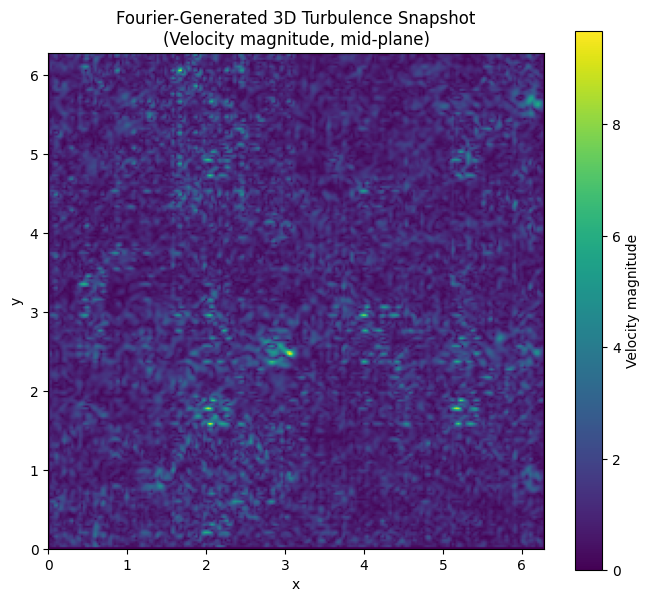

In [331]:
# Plot velocity magnitude for Fourier-generated field (mid-plane slice)
plt.figure(figsize=(8, 7))
plt.imshow(mw[:,:,N//2], origin="lower", extent=[0, 2 * np.pi, 0, 2 * np.pi], cmap="viridis")
plt.colorbar(label="Velocity magnitude")
plt.title(
    "Fourier-Generated 3D Turbulence Snapshot\n(Velocity magnitude, mid-plane)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [59]:
nscales = 8
N = 2**nscales
L = 2 * np.pi
seed = 42
nrank = 10
epsilon = 1
var = 1
eps = 1e-8

from scipy.stats import linregress
def generate_divergence_free_kolmogorov_3d(N=128, L=2 * np.pi, exponent=-5/3, seed=None):
    """
    Generate a 3D synthetic velocity field that is:
      - Divergence-free (incompressible).
      - Exhibits a power-law energy spectrum E(k) ~ k^(exponent).
        For a Kolmogorov-like spectrum in 3D, noting that E(k) ~ k^2 |u(k)|^2,
        the Fourier amplitude scales as |u(k)| ~ k^((exponent-2)/2).
    
    Parameters:
      N        : Number of grid points in each spatial direction.
      L        : Physical domain size (assumed cubic).
      exponent : Desired power-law exponent for the energy spectrum.
      seed     : Optional random seed for reproducibility.
      
    Returns:
      u, v, w  : 3D arrays (N x N x N) of the velocity components in real space.
    """
    if seed is not None:
        np.random.seed(seed)

    # 1) Set up wave numbers in Fourier space.
    kx = np.fft.fftfreq(N, d=L / N) * 2.0 * np.pi
    ky = np.fft.fftfreq(N, d=L / N) * 2.0 * np.pi
    kz = np.fft.fftfreq(N, d=L / N) * 2.0 * np.pi
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")
    k = np.sqrt(KX**2 + KY**2 + KZ**2)
    k[0, 0, 0] = 1.0  # avoid division by zero

    # 2) Compute the amplitude for each Fourier mode.
    # For 3D, |u(k)| ~ k^((exponent-2)/2).
    amp = k ** ((exponent - 2) / 2.0)
    amp[0, 0, 0] = 0.0  # remove the k=0 (mean flow) mode

    # 3) Generate random phases for the three velocity components.
    phase_x = np.exp(1j * 2.0 * np.pi * np.random.rand(N, N, N))
    phase_y = np.exp(1j * 2.0 * np.pi * np.random.rand(N, N, N))
    phase_z = np.exp(1j * 2.0 * np.pi * np.random.rand(N, N, N))
    w_x = amp * phase_x
    w_y = amp * phase_y
    w_z = amp * phase_z

    # 4) Enforce the divergence-free condition via projection.
    dot = KX * w_x + KY * w_y + KZ * w_z
    u_hat = w_x - (KX * dot) / (k**2)
    v_hat = w_y - (KY * dot) / (k**2)
    w_hat = w_z - (KZ * dot) / (k**2)

    # 5) Inverse FFT to obtain the velocity field in real space.
    u = np.fft.ifftn(u_hat).real
    v = np.fft.ifftn(v_hat).real
    w = np.fft.ifftn(w_hat).real

    return u, v, w

def compute_velocity_from_vector_potential(A_x, A_y, A_z, L=2 * np.pi):
    """
    Compute the velocity field (u,v,w) from a vector potential A = (A_x, A_y, A_z)
    using central finite differences to approximate the curl.
    
    In 3D, the curl is given by:
      u = dA_z/dy - dA_y/dz,
      v = dA_x/dz - dA_z/dx,
      w = dA_y/dx - dA_x/dy.
    
    Parameters:
      A_x, A_y, A_z : 3D arrays for the vector potential components.
      L             : Physical domain size (assumed cubic: [0, L]^3).
      
    Returns:
      u, v, w       : 3D arrays of velocity components.
    """
    N = A_x.shape[0]
    dx = L / N  # assuming dx = dy = dz
    u = np.zeros_like(A_x)
    v = np.zeros_like(A_x)
    w = np.zeros_like(A_x)
    
    # Compute derivatives using central differences for interior points.
    # u = dA_z/dy - dA_y/dz
    u[1:-1, 1:-1, 1:-1] = ((A_z[1:-1, 2:, 1:-1] - A_z[1:-1, :-2, 1:-1]) -
                           (A_y[1:-1, 1:-1, 2:] - A_y[1:-1, 1:-1, :-2])) / (2 * dx)
    # v = dA_x/dz - dA_z/dx
    v[1:-1, 1:-1, 1:-1] = ((A_x[1:-1, 1:-1, 2:] - A_x[1:-1, 1:-1, :-2]) -
                           (A_z[2:, 1:-1, 1:-1] - A_z[:-2, 1:-1, 1:-1])) / (2 * dx)
    # w = dA_y/dx - dA_x/dy
    w[1:-1, 1:-1, 1:-1] = ((A_y[2:, 1:-1, 1:-1] - A_y[:-2, 1:-1, 1:-1]) -
                           (A_x[1:-1, 2:, 1:-1] - A_x[1:-1, :-2, 1:-1])) / (2 * dx)
    return u, v, w


Ax, Ay, Az = gen_TT_cascade_3d(Nscales=nscales, nrank=nrank, levels=None, seed=None,epsilon=epsilon , method = 'skc',fnoise=('gaussian',nrank),eps=eps,var=var,boundary='periodic',order=2,field='velocity')
#Ax, Ay, Az =  gen_TT_3d(Nscales=nscales,nint=3, nrank=nrank, levels=None, seed=None,epsilon=1 , method = 'skc',fnoise=('gaussian',nrank),eps=eps,boundary='periodic',order=2)
print('cascade done')

A_x = z_order_to_normal_3d(Ax.full().flatten() , 2**nscales,2**nscales,2**nscales)
A_y = z_order_to_normal_3d(Ay.full().flatten() , 2**nscales,2**nscales,2**nscales)
A_z = z_order_to_normal_3d(Az.full().flatten() , 2**nscales,2**nscales,2**nscales)
print("shifts done")

# %% Compute velocity field from the vector potential (via its curl)
#u, v, w = compute_velocity_from_vector_potential(A_x, A_y, A_z, L=2 * np.pi)
u,v,w = A_x/L, A_y/L, A_z/L
# Generate the divergence-free 3D turbulence field via Fourier projection
uk, vk, wk = generate_divergence_free_kolmogorov_3d(
    N=N,
    L=2 * np.pi,
    exponent=-5 / 3,
    seed=seed,
)


# %% Compute the energy spectrum
# 1. Compute FFTs of the cascade-based and Fourier-generated velocity fields.
u_hat = np.fft.fftn(u)
v_hat = np.fft.fftn(v)
w_hat = np.fft.fftn(w)

uk_hat = np.fft.fftn(uk)
vk_hat = np.fft.fftn(vk)
wk_hat = np.fft.fftn(wk)

# 3. Get wavenumbers in 3D.
kx = 2 * np.pi * np.fft.fftfreq(N, d=L / N)
ky = 2 * np.pi * np.fft.fftfreq(N, d=L / N)
kz = 2 * np.pi * np.fft.fftfreq(N, d=L / N)
KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")
KX_shifted = np.fft.fftshift(KX)
KY_shifted = np.fft.fftshift(KY)
KZ_shifted = np.fft.fftshift(KZ)
k_magnitude = np.sqrt(KX_shifted**2 + KY_shifted**2 + KZ_shifted**2)

# 2. Compute 3D energy density (normalization adjusted for 3D; N^6 factor since volume ~ N^3 and energy ~ square)
E_hat_normalized = (np.abs(u_hat)**2 + np.abs(v_hat)**2 + np.abs(w_hat)**2) / 2 / N**6
Ek_hat_normalized = (np.abs(uk_hat)**2 + np.abs(vk_hat)**2 + np.abs(wk_hat)**2) / 2 
E_hat_shifted = np.fft.fftshift(E_hat_normalized)
Ek_hat_shifted = np.fft.fftshift(Ek_hat_normalized)

e_flat = E_hat_shifted.flatten()
ek_flat = Ek_hat_shifted.flatten()

k_magnitude_flat = k_magnitude.flatten()

# Define bins in k (spherical shells)
num_bins = N //2
k_min = k_magnitude_flat[k_magnitude_flat > 0].min()  # exclude zero to avoid log(0)
k_max = k_magnitude_flat.max()/1.7
bins = np.linspace(0.0, k_max, num_bins+1)  # num_bins bins
bin_centers = 0.5 * (bins[:-1] + bins[1:])
delta_k = bins[1:] - bins[:-1]

# Bin the energy using np.histogram with weights:
bin_energy, _ = np.histogram(k_magnitude_flat, bins=bins, weights=e_flat)
bin_energyk, _ = np.histogram(k_magnitude_flat, bins=bins, weights=ek_flat)
# Normalize by the bin width to obtain an estimate of the energy density E(k)
E = bin_energy / delta_k
Ek = bin_energyk / delta_k

valid = (E > 0) & (Ek > 0) & (bin_centers > 0)

log_k = np.log10(bin_centers[valid])
log_E = np.log10(E[valid])
log_Ek = np.log10(Ek[valid])


# Linear fits
lm = len(log_k)
print(lm)
window = slice(4,lm//4)
slope_E, intercept_E, *_ = linregress(log_k[window], log_E[window])
slope_Ek, intercept_Ek, *_ = linregress(log_k[window], log_Ek[window])

# Fitted lines
fit_E = 10**(intercept_E + slope_E * np.log10(bin_centers))
fit_Ek = 10**(intercept_Ek + slope_Ek * np.log10(bin_centers))

# Plot log-log spectra and fits
plt.figure(figsize=(8, 6))
plt.loglog(bin_centers, E, '-', label='Computed E(k)', color='tab:blue')
plt.loglog(bin_centers, Ek, '-', label='Computed E(k)_k', color='tab:orange')

# Overlay fitted lines
plt.loglog(bin_centers, fit_E, '--', color='tab:blue',
           label=f'Fit E(k): slope = {slope_E:.2f}')
plt.loglog(bin_centers, fit_Ek, '--', color='tab:orange',
           label=f'Fit E(k)_k: slope = {slope_Ek:.2f}')

plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.title("Binned Energy Spectrum with Log-Log Fits")
plt.legend()
plt.grid(True, which='both', ls=':', lw=0.5)
plt.tight_layout()
plt.show()



KeyboardInterrupt: 

In [28]:

Ax = tntt.load('./data/mps/Ax.TT')

c:\Users\siddhartha.morales\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchtt\_extras.py:862: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dct = tn.load(pat

# Classical code

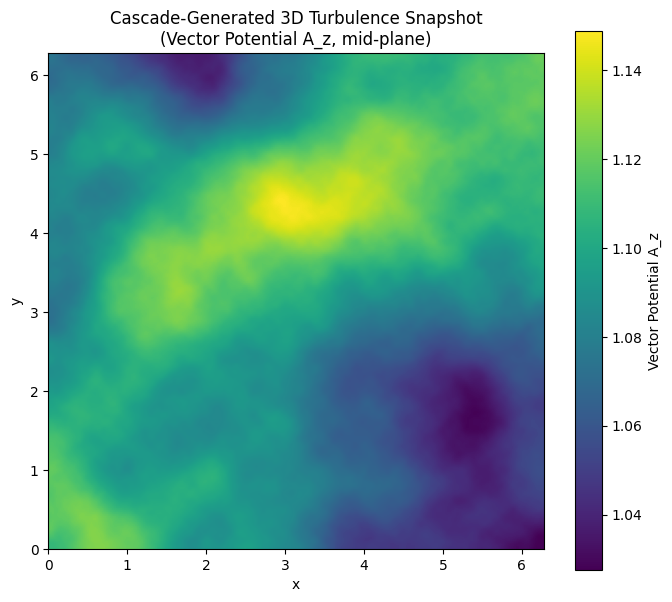

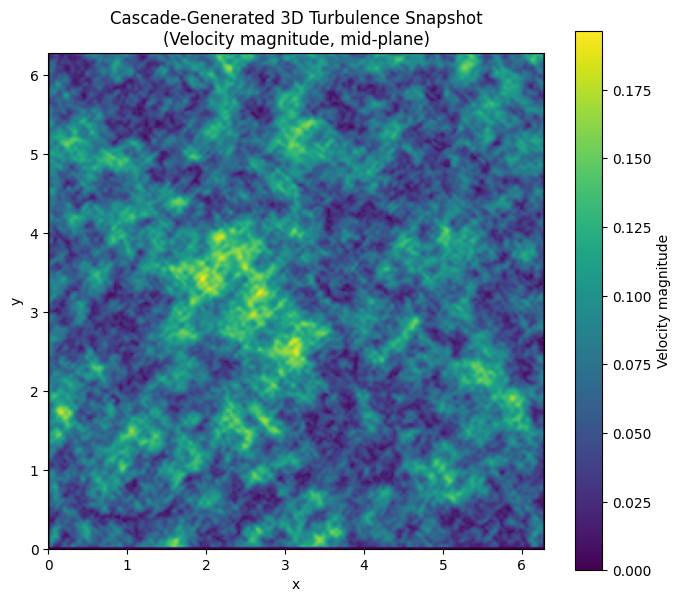

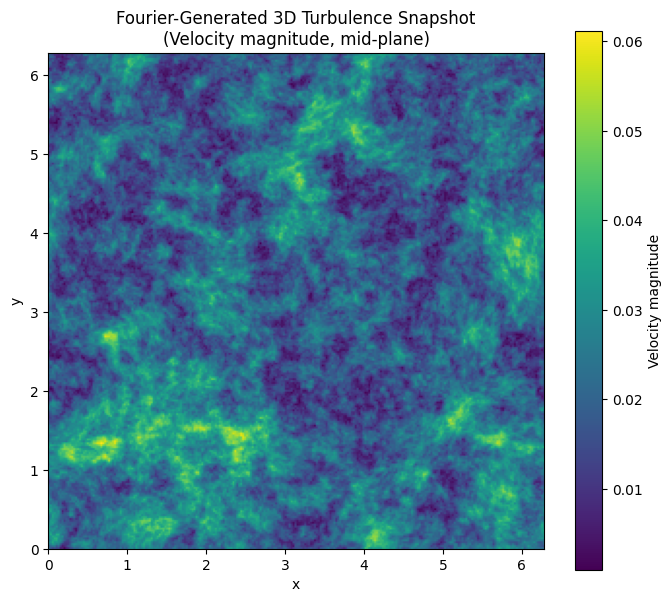

<Figure size 800x600 with 0 Axes>

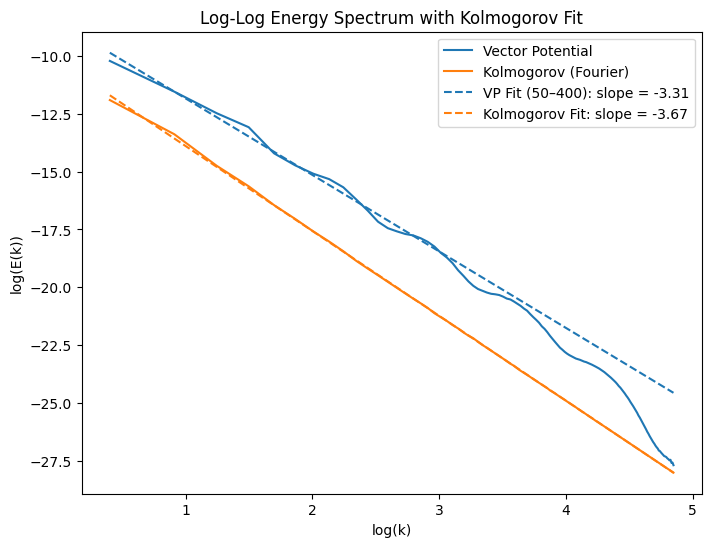

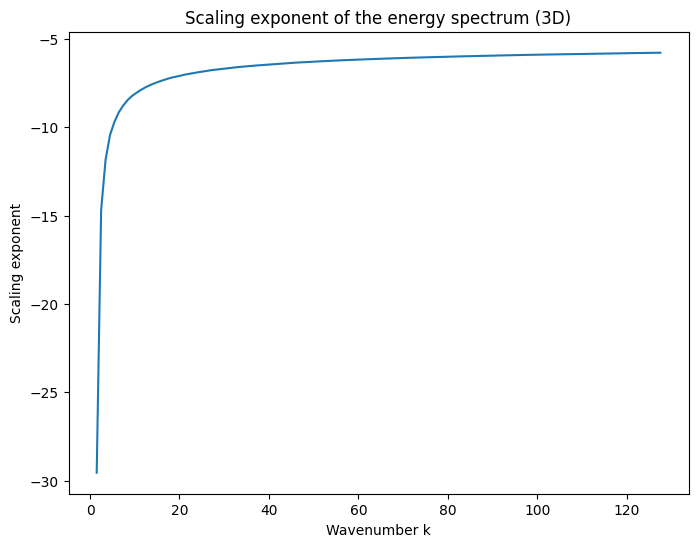

Median scaling exponent: -6.125590507591622


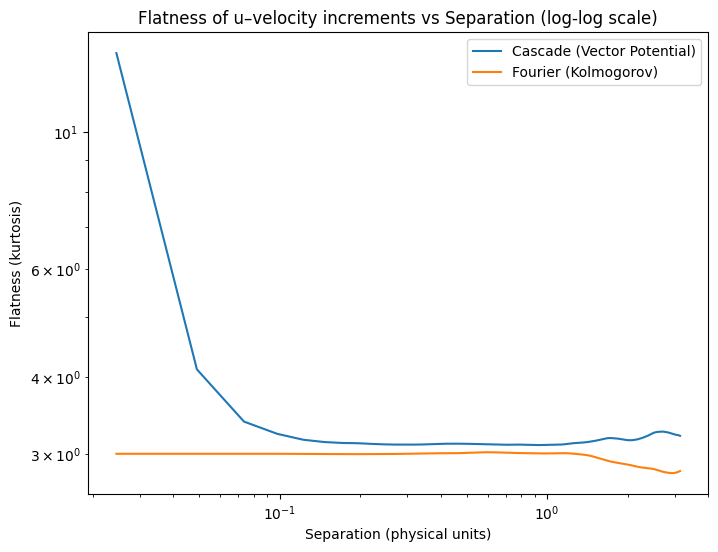

In [1]:
from scipy.stats import linregress
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

torch.set_default_dtype(torch.float64)


# %%
def vector_potential_single_vortex(X, Y, Z, Gamma=1.0, r0=0.1):
    """
    Generate a scalar vortex potential for a single vortex in 3D.
    This function is used to seed the 3D vector potential.
    Parameters:
      X, Y, Z : 3D arrays of coordinates.
      Gamma   : Circulation (strength) of the vortex.
      r0      : Core radius (smoothing parameter) to avoid singularity at r=0.
    Returns:
      phi     : 3D array of the vortex potential.
    """
    # Compute radial distance from the origin.
    r = np.sqrt(X**2 + Y**2 + Z**2)
    epsilon = 1e-8  # small epsilon to avoid log(0)
    # Note: In 3D the prefactor is adjusted (using 4*pi instead of 2*pi).
    phi = (Gamma / (4 * np.pi)) * np.log(1 + (r + epsilon) / r0)
    return phi


def generate_cascade_vector_potential_overlapping(N=128, levels=None, seed=None, epsilon=0.1):
    """
    Generate a 3D vector potential field A = (A_x, A_y, A_z) on an N x N x N grid using an overlapping cascade.

    Instead of updating disjoint blocks, at each cascade level a low-resolution random multiplier
    field is generated and then smoothly interpolated (using cubic interpolation) to the full grid.
    This ensures overlapping updates and smoother transitions.

    The multiplier field has a deterministic factor of 2^(-4/3) per level (to mimic increments
    with a 4/3 scaling) and random fluctuations controlled by epsilon.

    Parameters:
      N      : Grid size in each dimension (must be a power of 2).
      levels : Number of cascade levels (default: log2(N)).
      seed   : Random seed for reproducibility.
      epsilon: Amplitude of random fluctuations.

    Returns:
      A_x, A_y, A_z : 3D arrays representing the components of the vector potential.
    """
    if levels is None:
        levels = int(np.log2(N))
    if seed is not None:
        np.random.seed(seed)

    # Initialize each component uniformly.
    A_x = np.ones((N, N, N), dtype=float)
    A_y = np.ones((N, N, N), dtype=float)
    A_z = np.ones((N, N, N), dtype=float)
    base_scaling = 2.0 ** (-4.0 / 3.0)

    # For each cascade level, generate a coarse multiplier field and interpolate it smoothly.
    for lvl in range(levels):
        # Create a coarse grid; resolution increases with cascade level.
        coarse_shape = (2**lvl, 2**lvl, 2**lvl)
        # Random multipliers with mean 1.
        coarse_multiplierx = 1 + (base_scaling**lvl) * epsilon * (np.random.rand(*coarse_shape) - 0.5)
        coarse_multipliery = 1 + (base_scaling**lvl) * epsilon * (np.random.rand(*coarse_shape) - 0.5)
        coarse_multiplierz = 1 + (base_scaling**lvl) * epsilon * (np.random.rand(*coarse_shape) - 0.5)
        # Interpolate to full resolution using cubic (order=2) interpolation.
        zoom_factor = (N / coarse_shape[0], N / coarse_shape[1], N / coarse_shape[2])
        smooth_multiplierx = zoom(coarse_multiplierx, zoom_factor, order=2)
        smooth_multipliery = zoom(coarse_multipliery, zoom_factor, order=2)
        smooth_multiplierz = zoom(coarse_multiplierz, zoom_factor, order=2)
        # Multiply each component by the smooth multiplier field.
        A_x *= smooth_multiplierx
        A_y *= smooth_multipliery
        A_z *= smooth_multiplierz

    return A_x, A_y, A_z


def generate_cascade_vector_potential_vortices(N=128, levels=None, seed=None, epsilon=0.1):
    """
    Generate a 3D vector potential field A = (A_x, A_y, A_z) on an N x N x N grid using an overlapping cascade.
    In this version a coarse vortex potential is generated at each cascade level and used to modulate A.
    
    Parameters:
      N      : Grid size (must be a power of 2).
      levels : Number of cascade levels (default: log2(N)).
      seed   : Random seed for reproducibility.
      epsilon: Amplitude of random fluctuations.
      
    Returns:
      A_x, A_y, A_z : 3D arrays representing the components of the vector potential.
    """
    if levels is None:
        levels = int(np.log2(N))
    if seed is not None:
        np.random.seed(seed)

    # Define the full-resolution 3D grid.
    x = np.linspace(-np.pi, np.pi, N)
    y = np.linspace(-np.pi, np.pi, N)
    z = np.linspace(-np.pi, np.pi, N)
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    # Initialize vector potential using the vortex potential.
    A_x = vector_potential_single_vortex(X, Y, Z) * 1e-1
    A_y = vector_potential_single_vortex(X, Y, Z) * 1e-1
    A_z = vector_potential_single_vortex(X, Y, Z) * 1e-1

    base_scaling = 2.0 ** (-4.0 / 3.0)

    # For each cascade level, generate a coarse vortex multiplier field and interpolate.
    for lvl in range(levels):
        # Create a coarse grid for the current cascade level.
        coarse_shape = 2**lvl  # scalar resolution in each dimension.
        x_coarse = np.linspace(-np.pi, np.pi, coarse_shape)
        y_coarse = np.linspace(-np.pi, np.pi, coarse_shape)
        z_coarse = np.linspace(-np.pi, np.pi, coarse_shape)
        Xc, Yc, Zc = np.meshgrid(x_coarse, y_coarse, z_coarse, indexing="ij")
        # Generate a coarse vortex potential.
        vortex_coarse = vector_potential_single_vortex(Xc, Yc, Zc)
        # Random multipliers with mean 1.
        coarse_multiplier = 1 + (base_scaling**lvl) * (vortex_coarse + epsilon * (np.random.rand(coarse_shape, coarse_shape, coarse_shape) - 0.5))
        # Interpolate to full resolution.
        zoom_factor = (N / coarse_shape, N / coarse_shape, N / coarse_shape)
        smooth_multiplier = zoom(coarse_multiplier, zoom_factor, order=2)
        # Multiply the vector potential components by the smooth multiplier field.
        A_x *= smooth_multiplier
        A_y *= smooth_multiplier
        A_z *= smooth_multiplier

    return A_x, A_y, A_z


def compute_velocity_from_vector_potential(A_x, A_y, A_z, L=2 * np.pi):
    """
    Compute the velocity field (u,v,w) from a vector potential A = (A_x, A_y, A_z)
    using central finite differences to approximate the curl.
    
    In 3D, the curl is given by:
      u = dA_z/dy - dA_y/dz,
      v = dA_x/dz - dA_z/dx,
      w = dA_y/dx - dA_x/dy.
    
    Parameters:
      A_x, A_y, A_z : 3D arrays for the vector potential components.
      L             : Physical domain size (assumed cubic: [0, L]^3).
      
    Returns:
      u, v, w       : 3D arrays of velocity components.
    """
    N = A_x.shape[0]
    dx = L / N  # assuming dx = dy = dz
    u = np.zeros_like(A_x)
    v = np.zeros_like(A_x)
    w = np.zeros_like(A_x)
    
    # Compute derivatives using central differences for interior points.
    # u = dA_z/dy - dA_y/dz
    u[1:-1, 1:-1, 1:-1] = ((A_z[1:-1, 2:, 1:-1] - A_z[1:-1, :-2, 1:-1]) -
                           (A_y[1:-1, 1:-1, 2:] - A_y[1:-1, 1:-1, :-2])) / (2 * dx)
    # v = dA_x/dz - dA_z/dx
    v[1:-1, 1:-1, 1:-1] = ((A_x[1:-1, 1:-1, 2:] - A_x[1:-1, 1:-1, :-2]) -
                           (A_z[2:, 1:-1, 1:-1] - A_z[:-2, 1:-1, 1:-1])) / (2 * dx)
    # w = dA_y/dx - dA_x/dy
    w[1:-1, 1:-1, 1:-1] = ((A_y[2:, 1:-1, 1:-1] - A_y[:-2, 1:-1, 1:-1]) -
                           (A_x[1:-1, 2:, 1:-1] - A_x[1:-1, :-2, 1:-1])) / (2 * dx)
    return u, v, w


def generate_divergence_free_kolmogorov_3d(N=128, L=2 * np.pi, exponent=-5/3, seed=None):
    """
    Generate a 3D synthetic velocity field that is:
      - Divergence-free (incompressible).
      - Exhibits a power-law energy spectrum E(k) ~ k^(exponent).
        For a Kolmogorov-like spectrum in 3D, noting that E(k) ~ k^2 |u(k)|^2,
        the Fourier amplitude scales as |u(k)| ~ k^((exponent-2)/2).
    
    Parameters:
      N        : Number of grid points in each spatial direction.
      L        : Physical domain size (assumed cubic).
      exponent : Desired power-law exponent for the energy spectrum.
      seed     : Optional random seed for reproducibility.
      
    Returns:
      u, v, w  : 3D arrays (N x N x N) of the velocity components in real space.
    """
    if seed is not None:
        np.random.seed(seed)

    # 1) Set up wave numbers in Fourier space.
    kx = np.fft.fftfreq(N, d=L / N) * 2.0 * np.pi
    ky = np.fft.fftfreq(N, d=L / N) * 2.0 * np.pi
    kz = np.fft.fftfreq(N, d=L / N) * 2.0 * np.pi
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")
    k = np.sqrt(KX**2 + KY**2 + KZ**2)
    k[0, 0, 0] = 1.0  # avoid division by zero

    # 2) Compute the amplitude for each Fourier mode.
    # For 3D, |u(k)| ~ k^((exponent-2)/2).
    amp = k ** ((exponent - 2) / 2.0)
    amp[0, 0, 0] = 0.0  # remove the k=0 (mean flow) mode

    # 3) Generate random phases for the three velocity components.
    phase_x = np.exp(1j * 2.0 * np.pi * np.random.rand(N, N, N))
    phase_y = np.exp(1j * 2.0 * np.pi * np.random.rand(N, N, N))
    phase_z = np.exp(1j * 2.0 * np.pi * np.random.rand(N, N, N))
    w_x = amp * phase_x
    w_y = amp * phase_y
    w_z = amp * phase_z

    # 4) Enforce the divergence-free condition via projection.
    dot = KX * w_x + KY * w_y + KZ * w_z
    u_hat = w_x - (KX * dot) / (k**2)
    v_hat = w_y - (KY * dot) / (k**2)
    w_hat = w_z - (KZ * dot) / (k**2)

    # 5) Inverse FFT to obtain the velocity field in real space.
    u = np.fft.ifftn(u_hat).real
    v = np.fft.ifftn(v_hat).real
    w = np.fft.ifftn(w_hat).real

    return u, v, w


# %%
# Main parameters
N = 256
L = 2 * np.pi
seed = 42

# %% Generate the cascade-based vector potential (analogous to the 2D stream function)
A_x, A_y, A_z = generate_cascade_vector_potential_overlapping(N=N, seed=seed, epsilon=0.5)

# Plot one mid-plane slice (here A_z) of the vector potential
plt.figure(figsize=(8, 7))
plt.imshow(
    A_z[:, :, N//2],
    origin="lower",
    extent=[0, 2 * np.pi, 0, 2 * np.pi],
    cmap="viridis",
)
plt.colorbar(label="Vector Potential A_z")
plt.title(
    "Cascade-Generated 3D Turbulence Snapshot\n(Vector Potential A_z, mid-plane)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# %% Compute velocity field from the vector potential (via its curl)
u, v, w = compute_velocity_from_vector_potential(A_x, A_y, A_z, L=2 * np.pi)

# Generate the divergence-free 3D turbulence field via Fourier projection
uk, vk, wk = generate_divergence_free_kolmogorov_3d(
    N=N,
    L=2 * np.pi,
    exponent=-5 / 3,
    seed=seed,
)
uk = uk * 1e5
vk = vk * 1e5
wk = wk * 1e5

# %%
# Compute velocity magnitudes
speed = np.sqrt(u**2 + v**2 + w**2)
speedk = np.sqrt(uk**2 + vk**2 + wk**2)

# Plot velocity magnitude for cascade-generated field (mid-plane slice)
plt.figure(figsize=(8, 7))
plt.imshow(speed[:, :, N//2], origin="lower", extent=[0, 2 * np.pi, 0, 2 * np.pi], cmap="viridis")
plt.colorbar(label="Velocity magnitude")
plt.title(
    "Cascade-Generated 3D Turbulence Snapshot\n(Velocity magnitude, mid-plane)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Plot velocity magnitude for Fourier-generated field (mid-plane slice)
plt.figure(figsize=(8, 7))
plt.imshow(speedk[:, :, N//2], origin="lower", extent=[0, 2 * np.pi, 0, 2 * np.pi], cmap="viridis")
plt.colorbar(label="Velocity magnitude")
plt.title(
    "Fourier-Generated 3D Turbulence Snapshot\n(Velocity magnitude, mid-plane)"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# %% Compute the energy spectrum
# 1. Compute FFTs of the cascade-based and Fourier-generated velocity fields.
u_hat = np.fft.fftn(u)
v_hat = np.fft.fftn(v)
w_hat = np.fft.fftn(w)

uk_hat = np.fft.fftn(uk)
vk_hat = np.fft.fftn(vk)
wk_hat = np.fft.fftn(wk)

# 2. Compute 3D energy density (normalization adjusted for 3D; N^6 factor since volume ~ N^3 and energy ~ square)
E_hat_normalized = (np.abs(u_hat)**2 + np.abs(v_hat)**2 + np.abs(w_hat)**2) / (N**6)
Ek_hat_normalized = (np.abs(uk_hat)**2 + np.abs(vk_hat)**2 + np.abs(wk_hat)**2) / (N**6)

# 3. Get wavenumbers in 3D.
kx = 2 * np.pi * np.fft.fftfreq(N, d=L / N)
ky = 2 * np.pi * np.fft.fftfreq(N, d=L / N)
kz = 2 * np.pi * np.fft.fftfreq(N, d=L / N)
KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")
KX_shifted = np.fft.fftshift(KX)
KY_shifted = np.fft.fftshift(KY)
KZ_shifted = np.fft.fftshift(KZ)
k_magnitude = np.sqrt(KX_shifted**2 + KY_shifted**2 + KZ_shifted**2)

# Shift the energy densities accordingly.
E_hat_shifted = np.fft.fftshift(E_hat_normalized)
Ek_hat_shifted = np.fft.fftshift(Ek_hat_normalized)

# 4. Radial Averaging (Binning in spherical shells)
# Define k bins. Here we set a minimum k=1.0 and maximum k using the maximum k divided by sqrt(3) for 3D.
k_min = 1.0
k_max = np.max(k_magnitude) // np.sqrt(3)
num_bins = N // 2  # Example: up to (roughly) the Nyquist frequency in 3D.
k_bins = np.linspace(k_min, k_max, num_bins + 1)
k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])

# Initialize accumulators for energy and counts.
E_k = np.zeros_like(k_centers)
E_k2 = np.zeros_like(k_centers)
counts = np.zeros_like(k_centers, dtype=int)
counts2 = np.zeros_like(k_centers, dtype=int)

# Loop over all grid points in the 3D FFT result.
# (For clarity, we flatten the arrays and loop over the flattened index.)
k_mag_flat = k_magnitude.flatten()
E_flat = E_hat_shifted.flatten()
Ek_flat = Ek_hat_shifted.flatten()
for idx in range(k_mag_flat.size):
    k_val = k_mag_flat[idx]
    bin_index = np.searchsorted(k_bins, k_val) - 1
    if 0 <= bin_index < num_bins:
        E_k[bin_index] += E_flat[idx]
        E_k2[bin_index] += Ek_flat[idx]
        counts[bin_index] += 1

# Avoid division by zero by averaging only in bins that received contributions.
valid_bins = counts > 0
E_k[valid_bins] /= counts[valid_bins]
E_k2[valid_bins] /= counts[valid_bins]

# 5. Plot the energy spectra (in log-log space).
plt.figure(figsize=(8, 6))
# Assume k_centers, E_k, E_k2, valid_bins are already defined
log_k = np.log(k_centers[valid_bins])
log_Ek = np.log(E_k[valid_bins])
log_Ek2 = np.log(E_k2[valid_bins])

# Fit 1: Vector Potential (fit only from index 50 to 400)
fit_slice = slice(20, )
slope_vp, intercept_vp, *_ = linregress(log_k[fit_slice], log_Ek[fit_slice])
fit_line_vp = slope_vp * log_k + intercept_vp

# Fit 2: Kolmogorov (full range)
slope_kolmo, intercept_kolmo, *_ = linregress(log_k, log_Ek2)
fit_line_kolmo = slope_kolmo * log_k + intercept_kolmo

# Plot
plt.figure(figsize=(8, 6))
plt.plot(log_k, log_Ek, label="Vector Potential", color='tab:blue')
plt.plot(log_k, log_Ek2, label="Kolmogorov (Fourier)", color='tab:orange')

# Overlay fits
plt.plot(log_k, fit_line_vp, '--', color='tab:blue', label=f"VP Fit (50–400): slope = {slope_vp:.2f}")
plt.plot(log_k, fit_line_kolmo, '--', color='tab:orange', label=f"Kolmogorov Fit: slope = {slope_kolmo:.2f}")

plt.xlabel("log(k)")
plt.ylabel("log(E(k))")
plt.legend()
plt.title("Log-Log Energy Spectrum with Kolmogorov Fit")

# 6. Plot the scaling exponent.
scaling = np.log2(E_k2[valid_bins]) / np.log2(k_centers[valid_bins])
plt.figure(figsize=(8, 6))
plt.plot(k_centers[valid_bins], scaling)
plt.xlabel("Wavenumber k")
plt.ylabel("Scaling exponent")
plt.title("Scaling exponent of the energy spectrum (3D)")
plt.show()

print("Median scaling exponent:", np.median(scaling))



# %% Compute and plot the flatness for both approaches in log-log scale

def compute_flatness(u_field, max_sep, L):
    """
    Compute the flatness (kurtosis) of velocity increments in the x-direction for a 3D field.
    
    Parameters:
      u_field : 3D array (velocity component u).
      max_sep : Maximum separation (in grid points) to compute the increments.
      L       : Physical domain size.
    
    Returns:
      separations : 1D array of physical separation distances.
      flatness    : 1D array of flatness values at each separation.
    """
    N = u_field.shape[0]
    dx = L / N
    separations = np.arange(1, max_sep+1) * dx
    flatness = []
    for dr in range(1, max_sep+1):
        # Compute increments in the x-direction for all valid grid points.
        diff = u_field[dr:, :, :] - u_field[:-dr, :, :]
        S2 = np.mean(diff**2)
        S4 = np.mean(diff**4)
        flatness.append(S4 / (S2**2))
    return separations, np.array(flatness)

# Set maximum separation (in grid points) for structure function analysis.
max_sep = 128

# Compute flatness for the cascade-based velocity field (u component)
sep_cascade, flatness_cascade = compute_flatness(u, max_sep, L)

# Compute flatness for the Fourier-based (Kolmogorov) velocity field (u component)
sep_fourier, flatness_fourier = compute_flatness(uk, max_sep, L)

# Plot the flatness versus separation for both fields in log-log scale.
plt.figure(figsize=(8, 6))
plt.loglog(sep_cascade, flatness_cascade, label="Cascade (Vector Potential)")
plt.loglog(sep_fourier, flatness_fourier, label="Fourier (Kolmogorov)")
plt.xlabel("Separation (physical units)")
plt.ylabel("Flatness (kurtosis)")
plt.title("Flatness of u–velocity increments vs Separation (log-log scale)")
plt.legend()
plt.show()

In [3]:
(-5/3-2)

-3.666666666666667

## MPS distribution

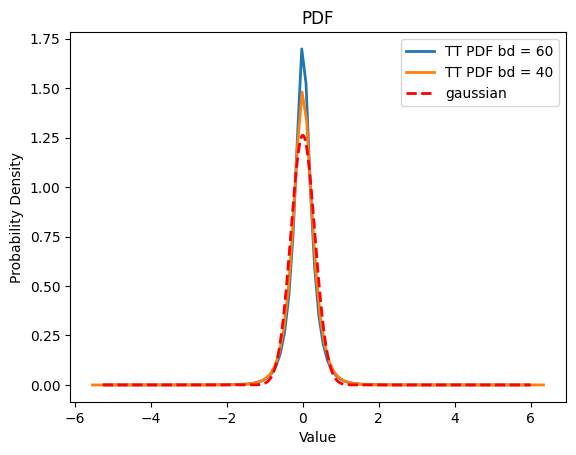

In [204]:
## Distribution

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

it = tntt.randn([4]*13,[1]+[20]*12+[1],var=0.1)
ft = (it)

data = ft.full().reshape(-1).numpy()


# Compute empirical PDF explicitly
pdf_values, bin_edges = np.histogram(data, bins=100, density=True)

# Compute bin centers explicitly
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot empirical PDF explicitly
plt.plot(bin_centers, pdf_values, linewidth=2, label='TT PDF bd = 60')

it = tntt.randn([4]*13,[1]+[30]*12+[1],var=0.1)
ft = (it)
data2 = ft.full().reshape(-1).numpy()
# Compute empirical PDF explicitly
pdf_values, bin_edges = np.histogram(data2, bins=100, density=True)

# Compute bin centers explicitly
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot empirical PDF explicitly
plt.plot(bin_centers, pdf_values, linewidth=2, label='TT PDF bd = 40')

# Plot the theoretical Gaussian PDF explicitly with mean=0, variance=2
std_dev = np.sqrt(0.1)
x_gauss = np.linspace(data.min(), data.max(), 500)
gaussian_pdf = norm.pdf(x_gauss, loc=0, scale=std_dev)

# Add the theoretical PDF explicitly
plt.plot(x_gauss, gaussian_pdf, 'r--', linewidth=2, label='gaussian')

plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.title('PDF')
plt.legend()

plt.show()

# Perlin noise

In [11]:
ncores = 20
fc = lambda x: tn.cos(x)
fs = lambda x: tn.sin(x)
noise = tntt.randn([2]*ncores,[1]+[5]*(ncores-1)+[1]).round()

fc = tntt.interpolate.function_interpolate(fc, noise)

In [12]:
noise

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 2, 1]

Device: cpu, dtype: torch.float64
#entries 820 compression 0.000782012939453125

In [14]:
fc

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 4, 6, 10, 18, 34, 66, 130, 239, 330, 381, 362, 255, 128, 64, 32, 16, 8, 4, 2, 1]

Device: cpu, dtype: torch.float64
#entries 1042336 compression 0.994049072265625

Saved animation to perlin_noise.gif


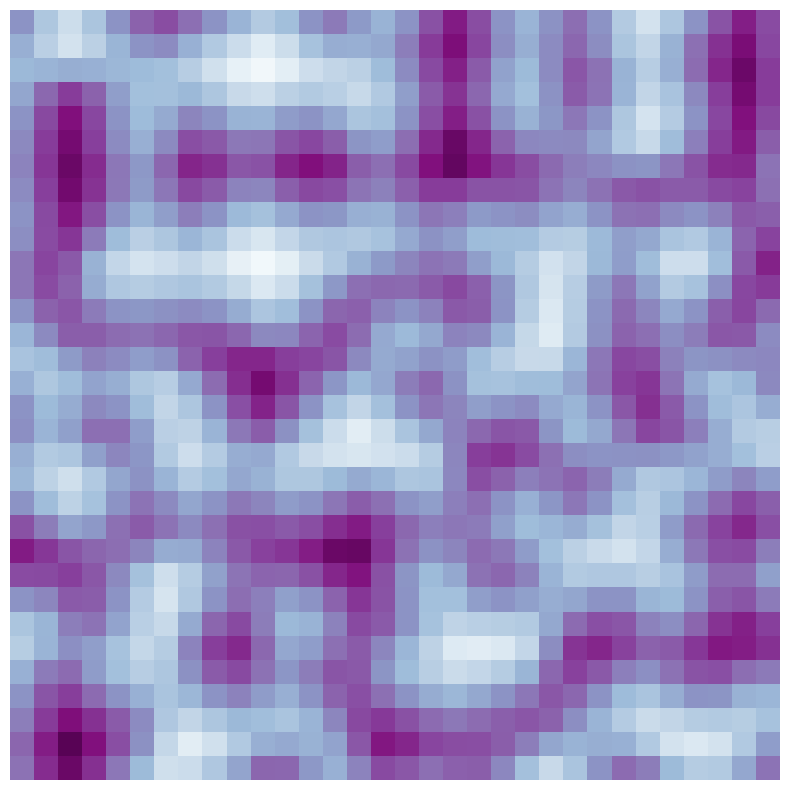

In [378]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def fade(t):
    return 6*t**5 - 15*t**4 + 10*t**3

def generate_gradients(res):
    angles = np.random.rand(res[0] + 1, res[1] + 1) * 2 * np.pi
    return np.stack((np.cos(angles), np.sin(angles)), axis=2)

def rotate_gradients(gradients, angle):
    c, s = np.cos(angle), np.sin(angle)
    rot = np.array([[c, -s], [s, c]])
    flat = gradients.reshape(-1, 2) @ rot.T
    norms = np.linalg.norm(flat, axis=1, keepdims=True)
    return (flat / norms).reshape(gradients.shape)

def perlin_noise(shape, res, gradients):
    h, w = shape
    gh, gw = h // res[0], w // res[1]
    y, x = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    cell_x = np.minimum(x // gw, res[1] - 1).astype(int)
    cell_y = np.minimum(y // gh, res[0] - 1).astype(int)
    fx = (x % gw) / gw
    fy = (y % gh) / gh
    u, v = fade(fx), fade(fy)
    
    g00 = gradients[cell_y,     cell_x    ]
    g10 = gradients[cell_y,     cell_x + 1]
    g01 = gradients[cell_y + 1, cell_x    ]
    g11 = gradients[cell_y + 1, cell_x + 1]
    
    dx0, dy0 = fx, fy
    dx1, dy1 = fx - 1, fy - 1
    
    dot = lambda g, dx, dy: g[...,0]*dx + g[...,1]*dy
    d00 = dot(g00, dx0, dy0)
    d10 = dot(g10, dx1, dy0)
    d01 = dot(g01, dx0, dy1)
    d11 = dot(g11, dx1, dy1)
    
    lerp = lambda a, b, t: a + (b - a) * t
    nx0 = lerp(d00, d10, u)
    nx1 = lerp(d01, d11, u)
    return lerp(nx0, nx1, v)

# Parameters
shape = (32, 32)
res = (8, 8)
gradients = generate_gradients(res)
frames = 20
cmaps = ['viridis','plasma','inferno','magma']

fig, ax = plt.subplots(figsize=(10,10))
im = ax.imshow(perlin_noise(shape, res, gradients), cmap=cmaps[0])
ax.axis('off')

def update(i):
    angle = 2*np.pi*i/frames
    rotated = rotate_gradients(gradients, angle)
    im.set_data(perlin_noise(shape, res, rotated))
    im.set_cmap('BuPu')
    return [im]

anim = FuncAnimation(fig, update, frames=frames, interval=400, blit=True)
anim.save('perlin_noise.gif', writer='pillow', fps=10)
print("Saved animation to perlin_noise.gif")


Saved animation to perlin_fractal.gif


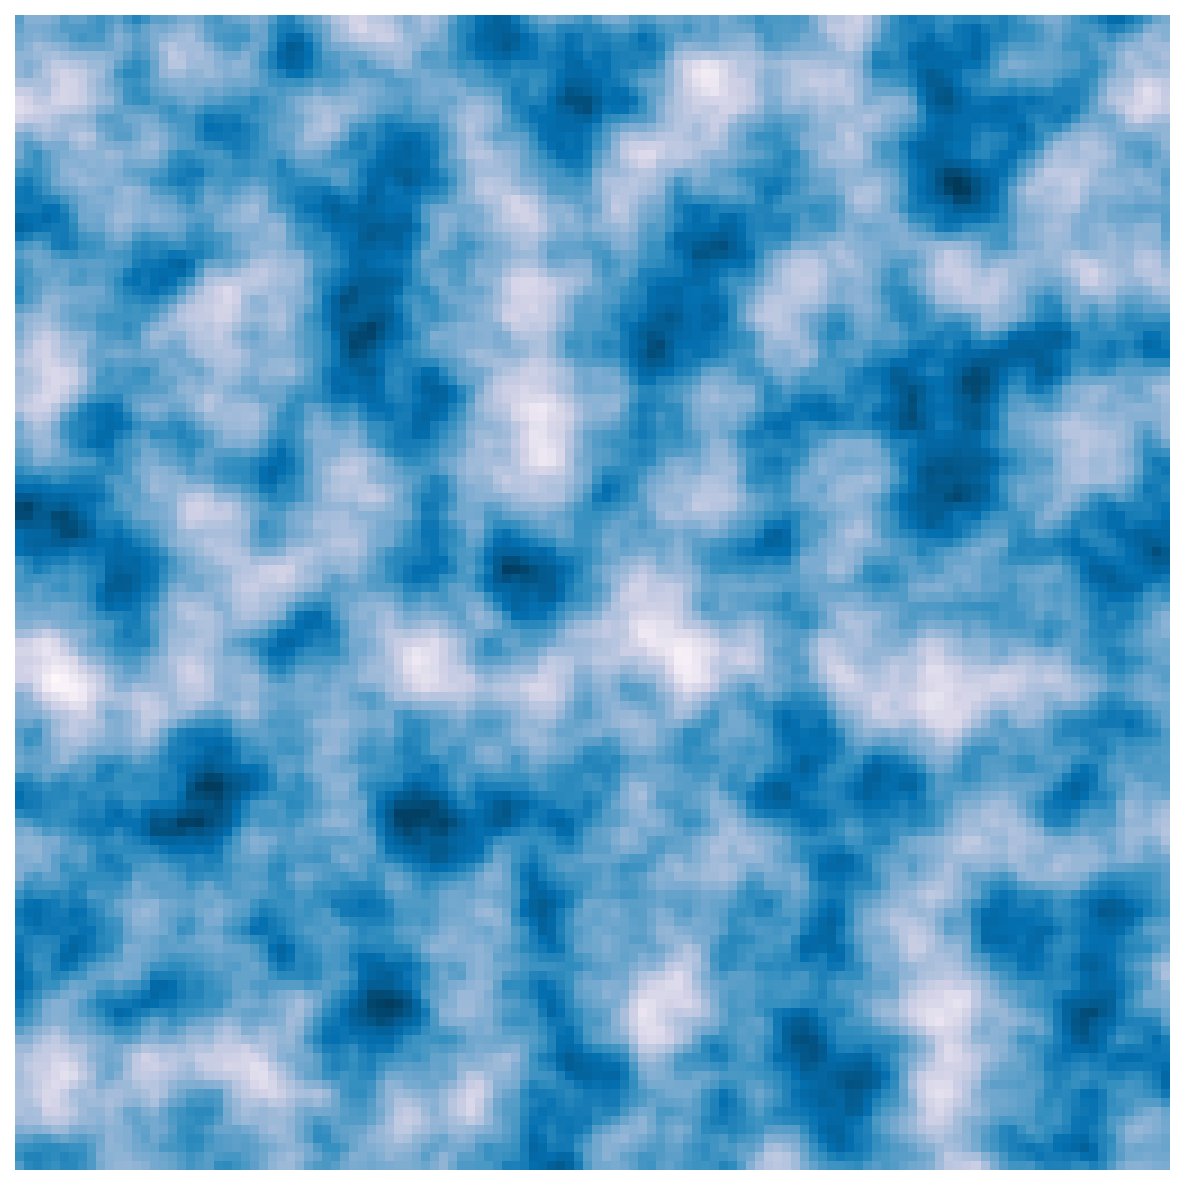

In [377]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def fade(t):
    return 6*t**5 - 15*t**4 + 10*t**3

def generate_gradients(res):
    angles = np.random.rand(res[0] + 1, res[1] + 1) * 2 * np.pi
    return np.stack((np.cos(angles), np.sin(angles)), axis=2)

def rotate_gradients(gradients, angle):
    c, s = np.cos(angle), np.sin(angle)
    rot = np.array([[c, -s], [s, c]])
    flat = gradients.reshape(-1, 2) @ rot.T
    norms = np.linalg.norm(flat, axis=1, keepdims=True)
    return (flat / norms).reshape(gradients.shape)

def perlin_noise(shape, res, gradients):
    h, w = shape
    gh, gw = h // res[0], w // res[1]
    y, x = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    cell_x = np.minimum(x // gw, res[1] - 1).astype(int)
    cell_y = np.minimum(y // gh, res[0] - 1).astype(int)
    fx = (x % gw) / gw
    fy = (y % gh) / gh
    u, v = fade(fx), fade(fy)
    
    g00 = gradients[cell_y,     cell_x    ]
    g10 = gradients[cell_y,     cell_x + 1]
    g01 = gradients[cell_y + 1, cell_x    ]
    g11 = gradients[cell_y + 1, cell_x + 1]
    
    dx0, dy0 = fx, fy
    dx1, dy1 = fx - 1, fy - 1
    
    dot = lambda g, dx, dy: g[...,0]*dx + g[...,1]*dy
    d00 = dot(g00, dx0, dy0)
    d10 = dot(g10, dx1, dy0)
    d01 = dot(g01, dx0, dy1)
    d11 = dot(g11, dx1, dy1)
    
    lerp = lambda a, b, t: a + (b - a) * t
    nx0 = lerp(d00, d10, u)
    nx1 = lerp(d01, d11, u)
    return lerp(nx0, nx1, v)

def fractal_perlin(shape, base_res, gradients_list, octaves, persistence, angle):
    noise = np.zeros(shape)
    amplitude = 1.0
    max_amp = 0.0
    for i in range(octaves):
        res_i = (base_res[0] * 2**i, base_res[1] * 2**i)
        grad_i = gradients_list[i]
        rot_grad = rotate_gradients(grad_i, angle)
        noise += amplitude * perlin_noise(shape, res_i, rot_grad)
        max_amp += amplitude
        amplitude *= persistence
    return noise / max_amp

# Parameters
shape = (128, 128)
base_res = (8, 8)
octaves = 4
persistence = 0.5
frames = 100
cmap = 'PuBu'

# Pre-generate gradient grids for each octave
gradients_list = [generate_gradients((base_res[0] * 2**i, base_res[1] * 2**i)) 
                  for i in range(octaves)]

fig, ax = plt.subplots(figsize=(10, 10),dpi=150)
initial_noise = fractal_perlin(shape, base_res, gradients_list, octaves, persistence, angle=0)
im = ax.imshow(initial_noise, cmap=cmap)
ax.axis('off')

def update(frame):
    angle = 2 * np.pi * frame / frames
    data = fractal_perlin(shape, base_res, gradients_list, octaves, persistence, angle)
    im.set_data(data)
    return [im]

anim = FuncAnimation(fig, update, frames=frames, interval=150, blit=True)
anim.save('perlin_fractal.gif', writer='pillow', fps=20)
print("Saved animation to perlin_fractal.gif")


In [525]:
#initial perlins noise 32 x 32


nnoise = 3
next = 10-nnoise
nscales = nnoise + next
pf = 7
n_frames = 2**pf
t = tn.linspace(0, 2*tn.pi, n_frames,dtype=tn.float64)
cs = tn.cos(2*t)
sn = tn.sin(2*t)
eps = 1e-12
pdim = 4
nrank = 10
var=2
tshape = [2**pf]
tshapeo = [(2**pf,2**pf)]

nx0 = tntt.randn([pdim]*nnoise,[1]+[nrank]*(nnoise-1)+[1],var=2)
ny0 = tntt.randn([pdim]*nnoise,[1]+[nrank]*(nnoise-1)+[1],var=2)
Cs = tntt.TT(cs,tshape)
Sn = tntt.TT(sn,tshape)

nx = tntt.kron(Cs,nx0) - tntt.kron(Sn,ny0)
ny = tntt.kron(Sn,nx0) + tntt.kron(Cs,ny0)

nx = nx.round(eps)
ny = ny.round(eps)

# generate 4 corner contributions
I = tn.eye(4,dtype=tn.float64)
vs = [tntt.TT(I[i],[4]) for i in range(4)]
id = tntt.TT(tn.eye(n_frames,dtype=tn.float64),tshapeo)
S1 = P_qtt(2**nnoise-1,nnoise)
S0 = I_qtt(nnoise)
S1x = zkron(S1,S0)
S1y = zkron(S0,S1)
S1xy = zkron(S1,S1)

S1xt = tntt.kron(id,S1x)
S1yt = tntt.kron(id,S1y)
S1xyt = tntt.kron(id,S1xy)

c1 = tntt.kron(nx ,vs[0]).round(eps)
c2 = tntt.kron( S1xt@nx ,vs[1]).round(eps)
c3 = tntt.kron( S1yt@nx,vs[2]).round(eps)
c4 = tntt.kron( S1xyt@nx,vs[3]).round(eps)

coarsex = c1+c2+c3+c4
coarsex = coarsex.round(eps)

c1 = tntt.kron(ny ,vs[0]).round(eps)
c2 = tntt.kron( S1xt@ny ,vs[1]).round(eps)
c3 = tntt.kron( S1yt@ny,vs[2]).round(eps)
c4 = tntt.kron( S1xyt@ny,vs[3]).round(eps)

coarsey = c1+c2+c3+c4
coarsey = coarsey.round(eps)

coefs3 = [0,0,3,-2]
icoefs3 = [1,0,-3,2]
coefs5 = [0,0,0,10,-15,6]
icoefs5 = [1,0,0,-10,15,-6] 

coefs = coefs5
icoefs = icoefs5

def mx(coesf):
    return [0] + coesf 
def mx1(coesf):
    mc = [-x for x in coesf] + [0]
    return np.array(mc) + np.array([0] + coesf )

psi1 = tntt.TT( qtt_polynomial_cores(coefs,next) )
psi0 = tntt.TT( qtt_polynomial_cores(icoefs,next) )

psi0x = tntt.TT( qtt_polynomial_cores(mx(icoefs),next) )
psi1xm = tntt.TT( qtt_polynomial_cores(mx1(coefs),next) )

# do x
P1 = tntt.kron(vs[0],zkron(psi0x,psi0))
P2 = tntt.kron(vs[1],zkron(psi1xm,psi0))
P3 = tntt.kron(vs[2],zkron(psi0x,psi1))
P4 = tntt.kron(vs[3],zkron(psi1xm,psi1))

Pext = (P1+P2+P3+P4).round(eps)

perTTx = connect(coarsex,Pext,pd=4)

# do y
P1 = tntt.kron(vs[0],zkron(psi0,psi0x))
P2 = tntt.kron(vs[1],zkron(psi1,psi0x))
P3 = tntt.kron(vs[2],zkron(psi0,psi1xm))
P4 = tntt.kron(vs[3],zkron(psi1,psi1xm))

Pext = (P1+P2+P3+P4).round(eps)

perTTy = connect(coarsey,Pext,pd=4)

perTT0 = (perTTx + perTTy).round(eps)
print(perTT0)

TT with sizes and ranks:
N = [128, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
R = [1, 2, 8, 18, 8, 23, 45, 43, 37, 16, 4, 1]

Device: cpu, dtype: torch.float64
#entries 23092 compression 0.00017204880714416504



c:\Users\siddhartha.morales\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchtt\_decomposition.py:365: RuntimeWarning: divide by zero encountered in scalar divide
  ep = eps/np.sqrt(d-1)


In [532]:
def ssqtt(mps):
    cores = mps.cores
    s = cores[0].shape[2]
    ncore  = tn.ones([s,4,s],dtype=tn.float64)

    return tntt.TT(cores[:1] + [ncore] + cores[1:])

oc1 = ssqtt(reduceg(perTT0,0,-1)).round(eps)
oc2 = ssqtt(reduceg(oc1,0,-1)).round(eps)
oc3 = ssqtt(reduceg(oc2,0,-1)).round(eps)
oc4 = ssqtt(reduceg(oc3,0,-1)).round(eps)
perTT = perTT0 + (1/2)*oc1 + (1/4)*oc2 + (1/8)*oc3 + (1/16)*oc4
perTT = perTT.round(eps)
perTT

TT with sizes and ranks:
N = [128, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
R = [1, 2, 8, 22, 24, 44, 64, 64, 48, 16, 4, 1]

Device: cpu, dtype: torch.float64
#entries 50640 compression 0.00037729740142822266

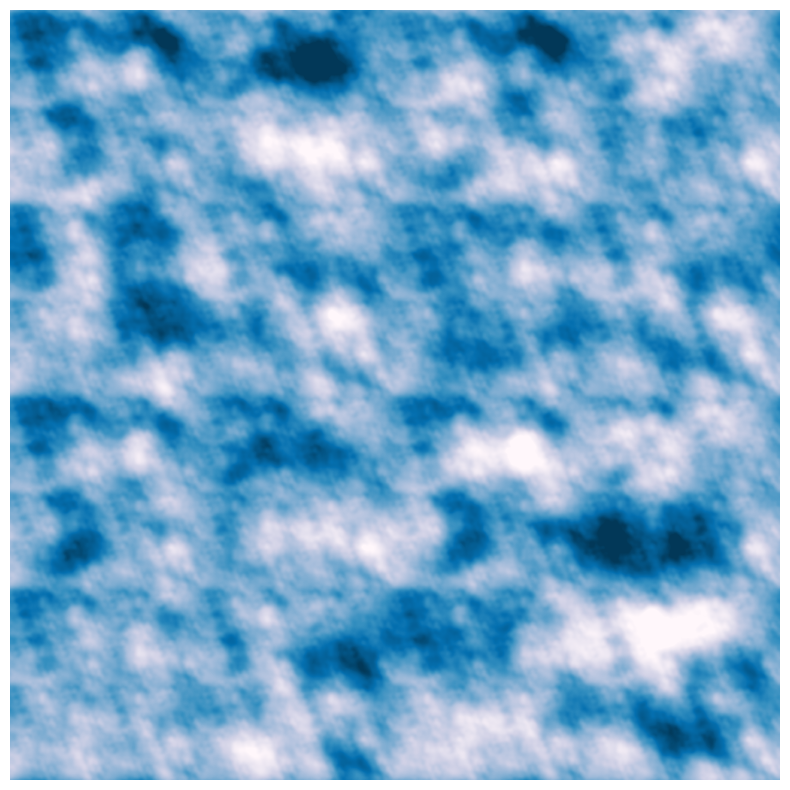

In [533]:
fsnap = reduceg(perTT0,4,0)

snap = z_order_to_normal(fsnap.full().flatten().numpy(),2**nscales,2**nscales)
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(snap, cmap=cmap)
ax.axis('off')


def update(i):
    fsnap = reduceg(perTT,i,0)
    snap = z_order_to_normal(fsnap.full().flatten().numpy(),2**nscales,2**nscales)
    im.set_data(snap)
    im.set_cmap('PuBu')
    return [im]

anim = FuncAnimation(fig, update, frames=2**pf, interval=10, blit=True)
anim.save('QTTPerlin.gif', writer='pillow', fps=5)


In [570]:
#initial perlins noise 32 x 32


nnoise = 3
next = 10-nnoise
nscales = nnoise + next
n_frames = 100
t = tn.linspace(0, 2*tn.pi, n_frames,dtype=tn.float64)
cs = tn.cos(t)
sn = tn.sin(t)
eps = 1e-10
pdim = 4
nrank = 10
var = 1

nx0 = tntt.randn([pdim]*nnoise,[1]+[nrank]*(nnoise-1)+[1],var=var)
ny0 = tntt.randn([pdim]*nnoise,[1]+[nrank]*(nnoise-1)+[1],var=var)
nx = nx0
ny = ny0
# generate 4 corner contributions
I = tn.eye(4,dtype=tn.float64)
vs = [tntt.TT(I[i],[4]) for i in range(4)]
id = tntt.TT(tn.eye(n_frames,dtype=tn.float64),[(n_frames,n_frames)])
S1 = P_qtt(2**nnoise-1,nnoise)
S0 = I_qtt(nnoise)
S1x = zkron(S1,S0)
S1y = zkron(S0,S1)
S1xy = zkron(S1,S1)

S1xt = S1x
S1yt = S1y
S1xyt = S1xy

c1 = tntt.kron(nx ,vs[0]).round(eps)
c2 = tntt.kron( S1xt@nx ,vs[1]).round(eps)
c3 = tntt.kron( S1yt@nx,vs[2]).round(eps)
c4 = tntt.kron( S1xyt@nx,vs[3]).round(eps)

coarsex = c1+c2+c3+c4
coarsex = coarsex.round(eps)

c1 = tntt.kron(ny ,vs[0]).round(eps)
c2 = tntt.kron( S1xt@ny ,vs[1]).round(eps)
c3 = tntt.kron( S1yt@ny,vs[2]).round(eps)
c4 = tntt.kron( S1xyt@ny,vs[3]).round(eps)

coarsey = c1+c2+c3+c4
coarsey = coarsey.round(eps)

coefs3 = [0,0,3,-2]
icoefs3 = [1,0,-3,2]
coefs5 = [0,0,0,10,-15,6]
icoefs5 = [1,0,0,-10,15,-6] 

coefs = coefs5
icoefs = icoefs5

def mx(coesf):
    return [0] + coesf 
def mx1(coesf):
    mc = [-x for x in coesf] + [0]
    return np.array(mc) + np.array([0] + coesf )

psi1 = tntt.TT( qtt_polynomial_cores(coefs,next) )
psi0 = tntt.TT( qtt_polynomial_cores(icoefs,next) )

psi0x = tntt.TT( qtt_polynomial_cores(mx(icoefs),next) )
psi1xm = tntt.TT( qtt_polynomial_cores(mx1(coefs),next) )

# do x
P1 = tntt.kron(vs[0],zkron(psi0x,psi0))
P2 = tntt.kron(vs[1],zkron(psi1xm,psi0))
P3 = tntt.kron(vs[2],zkron(psi0x,psi1))
P4 = tntt.kron(vs[3],zkron(psi1xm,psi1))

Pext = (P1+P2+P3+P4).round(eps)

perTTx = connect(coarsex,Pext,pd=4)

# do y
P1 = tntt.kron(vs[0],zkron(psi0,psi0x))
P2 = tntt.kron(vs[1],zkron(psi1,psi0x))
P3 = tntt.kron(vs[2],zkron(psi0,psi1xm))
P4 = tntt.kron(vs[3],zkron(psi1,psi1xm))

Pext = (P1+P2+P3+P4).round(eps)

perTTy = connect(coarsey,Pext,pd=4)

perTT0 = (perTTx + perTTy).round(eps)
perTT0

c:\Users\siddhartha.morales\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchtt\_decomposition.py:365: RuntimeWarning: divide by zero encountered in scalar divide
  ep = eps/np.sqrt(d-1)


TT with sizes and ranks:
N = [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
R = [1, 4, 16, 8, 23, 45, 39, 30, 15, 4, 1]

Device: cpu, dtype: torch.float64
#entries 19416 compression 0.01851654052734375

In [571]:
oc1 = tntt.kron(tntt.ones([4]),reduceg(perTT0,0,-1)).round(eps)
oc2 = tntt.kron(tntt.ones([4]),reduceg(oc1,0,-1)).round(eps)
oc3 = tntt.kron(tntt.ones([4]),reduceg(oc2,0,-1)).round(eps)
oc4 = tntt.kron(tntt.ones([4]),reduceg(oc3,0,-1)).round(eps)
perTT = perTT0 + (1/2)*oc1 + (1/4)*oc2 + (1/8)*oc3 #+ (1/16)*oc4
perTT = perTT.round(eps)
perTT

TT with sizes and ranks:
N = [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
R = [1, 4, 16, 24, 44, 64, 48, 46, 16, 4, 1]

Device: cpu, dtype: torch.float64
#entries 41632 compression 0.039703369140625

In [572]:
#fsnap = reduceg(perTT0,0,0)

snap = z_order_to_normal(perTT0.full().flatten().numpy(),2**nscales,2**nscales)

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

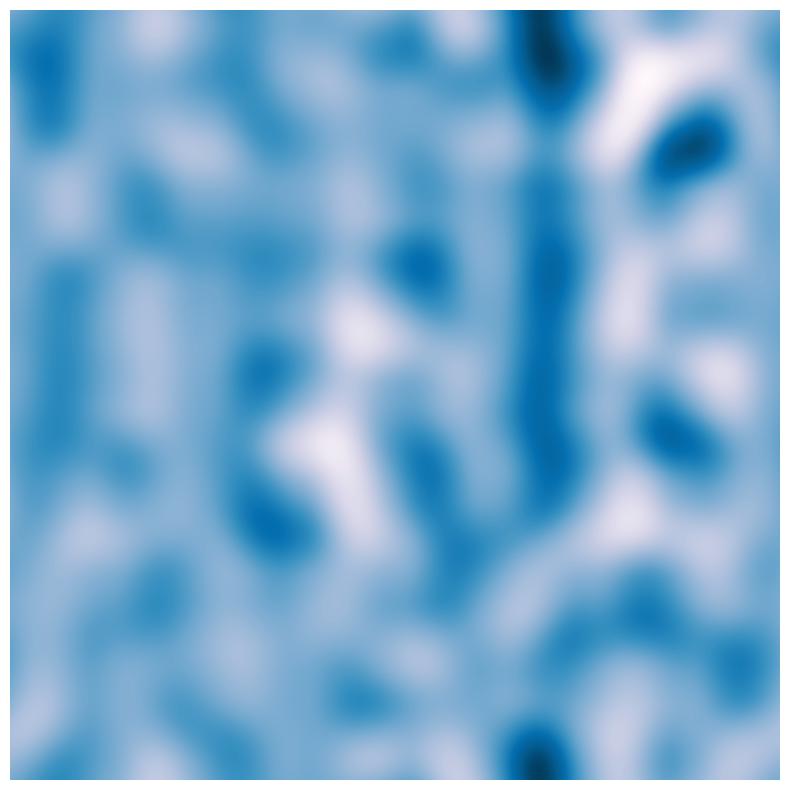

In [573]:
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(snap, cmap=cmap)
ax.axis('off')

Saved animation to terrain_cam_path.gif


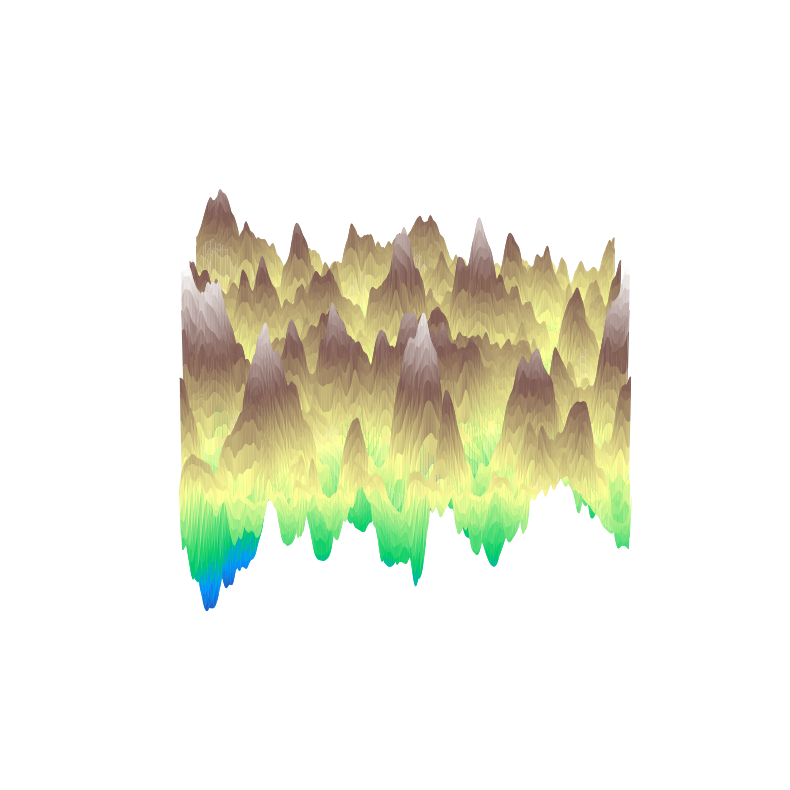

In [574]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
shape = (2**nscales, 2**nscales)
terrain = z_order_to_normal(perTT.full().flatten().numpy(),2**nscales,2**nscales)
X, Y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
surf = ax.plot_surface(
    X, Y, terrain,
    cmap='terrain',
    rcount=200, ccount=200,
    linewidth=0, antialiased=True
)
ax.set_axis_off()

# Animation parameters
frames = 120
half   = frames // 2

# Update: first half rotates around, second half tilts up & zooms
def update(frame):
    # clear only the view, keep surface
    if frame < half:
        elev = 30
        azim = frame * (360 / half)
        dist = 10
    else:
        t = (frame - half) / half  # 0→1
        elev = 30 + 60 * t         # 30° → 90°
        azim = 360
        dist = 10 - 4 * t          # 10 → 6 (zooms in)
    ax.view_init(elev=elev, azim=azim)
    ax.dist = dist
    return surf,

# Create and save
anim = FuncAnimation(fig, update, frames=frames, interval=80, blit=False)
anim.save('terrain_cam_path.gif', writer='pillow', fps=5)
print("Saved animation to terrain_cam_path.gif")

Saved animation to terrain_flight_slow.gif


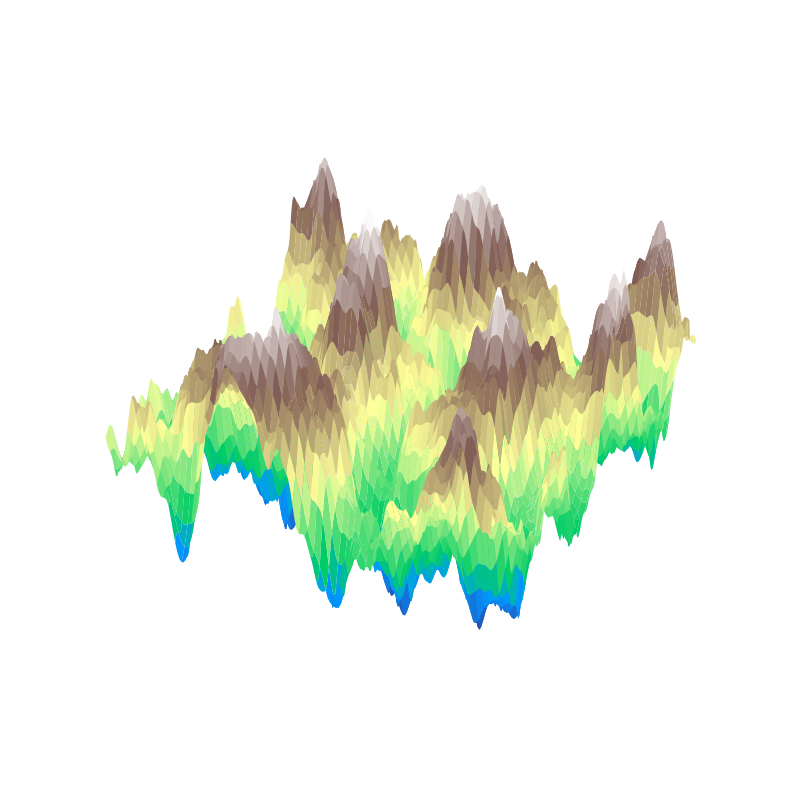

In [547]:
# Adjusted animation: slower rotation and more frames

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D

def fade(t):
    return 6*t**5 - 15*t**4 + 10*t**3

def generate_gradients(res):
    angles = np.random.rand(res[0] + 1, res[1] + 1) * 2 * np.pi
    return np.stack((np.cos(angles), np.sin(angles)), axis=2)

def rotate_gradients(gradients, angle):
    c, s = np.cos(angle), np.sin(angle)
    rot = np.array([[c, -s], [s, c]])
    flat = gradients.reshape(-1, 2) @ rot.T
    norms = np.linalg.norm(flat, axis=1, keepdims=True)
    return (flat / norms).reshape(gradients.shape)

def perlin_noise(shape, res, gradients):
    h, w = shape
    gh, gw = h//res[0], w//res[1]
    y, x = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    cell_x = np.minimum(x//gw, res[1]-1).astype(int)
    cell_y = np.minimum(y//gh, res[0]-1).astype(int)
    fx, fy = (x%gw)/gw, (y%gh)/gh
    u, v = fade(fx), fade(fy)
    
    g00 = gradients[cell_y,     cell_x    ]
    g10 = gradients[cell_y,     cell_x + 1]
    g01 = gradients[cell_y + 1, cell_x    ]
    g11 = gradients[cell_y + 1, cell_x + 1]
    
    dx0, dy0 = fx, fy
    dx1, dy1 = fx - 1, fy - 1
    dot = lambda g, dx, dy: g[...,0]*dx + g[...,1]*dy
    
    d00 = dot(g00, dx0, dy0)
    d10 = dot(g10, dx1, dy0)
    d01 = dot(g01, dx0, dy1)
    d11 = dot(g11, dx1, dy1)
    
    lerp = lambda a, b, t: a + (b - a)*t
    nx0 = lerp(d00, d10, u)
    nx1 = lerp(d01, d11, u)
    return lerp(nx0, nx1, v)

def fractal_perlin_with_gradients(shape, gradients_list, persistence):
    noise = np.zeros(shape)
    amp = 1.0
    max_amp = 0.0
    for grad in gradients_list:
        res = (grad.shape[0]-1, grad.shape[1]-1)
        noise += amp * perlin_noise(shape, res, grad)
        max_amp += amp
        amp *= persistence
    return noise / max_amp

# --- Adjusted Parameters ---
shape       = (200, 200)
base_res    = (4, 4)
octaves     = 4
persistence = 0.5
frames      = 120     # double the frames for smoother transition
fps         = 5

# Pre-generate gradients for each octave
gradients_list = [
    generate_gradients((base_res[0]*2**i, base_res[1]*2**i))
    for i in range(octaves)
]

# Create figure and 3D axis
fig = plt.figure(figsize=(10, 10), dpi=100)
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))

# Initial surface
terrain = fractal_perlin_with_gradients(shape, gradients_list, persistence)
surf = ax.plot_surface(X, Y, terrain, cmap='terrain', rcount=200, ccount=200, linewidth=0)
ax.set_axis_off()

# Update function: slower rotation
def update(frame):
    global surf
    surf.remove()
    # reduce angle speed: full rotation over twice the frames
    angle = 2 * np.pi * frame / (frames * 2)
    rotated_list = [rotate_gradients(g, angle) for g in gradients_list]
    new_terrain = fractal_perlin_with_gradients(shape, rotated_list, persistence)
    surf = ax.plot_surface(X, Y, new_terrain, cmap='terrain', rcount=80, ccount=80, linewidth=0)
    return surf,

# Create and save animation
anim = FuncAnimation(fig, update, frames=frames, interval=100, blit=False)
anim.save('terrain_flight_slow.gif', writer='pillow', fps=fps)
print("Saved animation to terrain_flight_slow.gif")


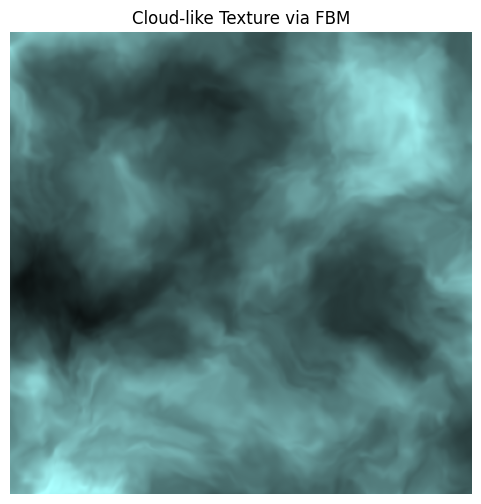

In [575]:
import numpy as np
import matplotlib.pyplot as plt

# Utility functions
def fract(x):
    return x - np.floor(x)

def random2(st):
    # 2D pseudo-random from coordinate
    dot = st[..., 0]*12.9898 + st[..., 1]*78.233
    return fract(np.sin(dot) * 43758.5453123)

def noise2d(st):
    # Classic value noise
    i = np.floor(st)
    f = fract(st)
    a = random2(i)
    b = random2(i + np.array([1.0, 0.0]))
    c = random2(i + np.array([0.0, 1.0]))
    d = random2(i + np.array([1.0, 1.0]))
    u = f*f*(3.0 - 2.0*f)
    return (a*(1-u[...,0])*(1-u[...,1]) +
            b*u[...,0]*(1-u[...,1]) +
            c*(1-u[...,0])*u[...,1] +
            d*u[...,0]*u[...,1])

def fbm(st, octaves=5, persistence=0.5):
    v = np.zeros_like(st[...,0])
    amplitude = 0.5
    shift = np.array([100.0, 100.0])
    rot = np.array([[np.cos(0.5), np.sin(0.5)],
                    [-np.sin(0.5), np.cos(0.5)]])
    for _ in range(octaves):
        v += amplitude * noise2d(st)
        st = st @ rot * 2.0 + shift
        amplitude *= persistence
    return v

# Generate coordinates
res = 400
x = np.linspace(0, 3, res)
y = np.linspace(0, 3, res)
X, Y = np.meshgrid(x, y)
st = np.stack([X, Y], axis=-1)

# Create layers
q = np.stack([fbm(st), fbm(st + np.array([1.0, 0.0]))], axis=-1)
r = np.stack([
    fbm(st + q + np.array([1.7, 9.2])),
    fbm(st + q + np.array([8.3, 2.8]))
], axis=-1)

f = fbm(st + r)

# Color mixing
col1 = np.array([0.101961, 0.619608, 0.666667])
col2 = np.array([0.666667, 0.666667, 0.498039])
col3 = np.array([0.0,      0.0,      0.164706])
col4 = np.array([0.666667, 1.0,      1.0])

# blend base color
t = np.clip((f**2)*4.0, 0.0, 1.0)[..., None]
color = col1*(1-t) + col2*t

# darken
t2 = np.clip(np.linalg.norm(q, axis=-1), 0.0, 1.0)[..., None]
color = color*(1-t2) + col3*t2

# lighten highlights
t3 = np.clip(np.linalg.norm(r[...,0]), 0.0, 1.0)
color[..., :] = color*(1-t3) + col4*t3[..., None]

# final brightness modulation
alpha = (f**3 + 0.6*f**2 + 0.5*f)[..., None]
cloud = np.clip(color * alpha, 0.0, 1.0)

# Display
plt.figure(figsize=(6, 6))
plt.imshow(cloud, origin='lower')
plt.axis('off')
plt.title("Cloud-like Texture via FBM")
plt.show()


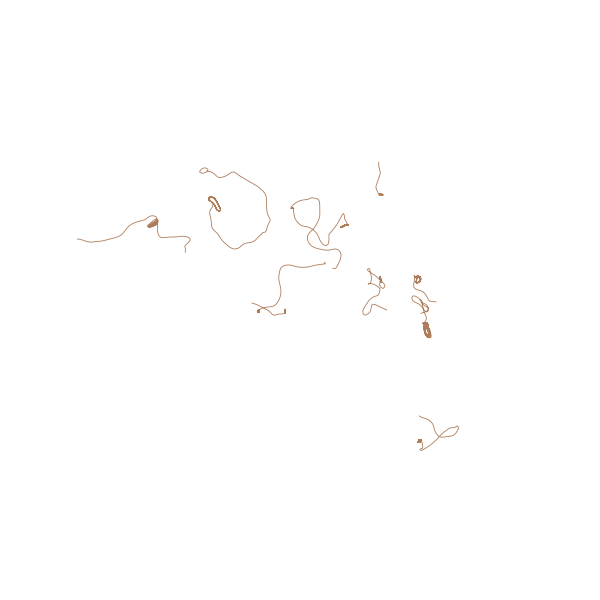

In [2]:


# --- imports ---
import random, math
from noise import pnoise3
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- parameters ---
W, H, D    = 100, 100, 100   # 3D volume size
scale      = 20.0
step       = 1.0
length     = 300
n_worms    = 10

# --- figure & 3D axes ---
fig = plt.figure(figsize=(6,6))
ax  = fig.add_subplot(111, projection='3d')
ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_zlim(0, D)
ax.set_box_aspect((W, H, D))   # keep equal aspect
ax.axis('off')

# --- draw worms ---
for _ in range(n_worms):
    x, y, z = [random.uniform(0, W) for _ in range(3)]
    xs, ys, zs = [x], [y], [z]
    for i in range(length):
        # sample 3D noise for a pseudo‐vector field
        vx = pnoise3(x/scale,     y/scale,     z/scale,     octaves=3)
        vy = pnoise3(x/scale+100, y/scale+100, z/scale+100, octaves=3)
        vz = pnoise3(x/scale+200, y/scale+200, z/scale+200, octaves=3)
        norm = math.hypot(vx, vy, vz) or 1.0
        x += step * vx/norm
        y += step * vy/norm
        z += step * vz/norm
        xs.append(x); ys.append(y); zs.append(z)
    ax.plot(xs, ys, zs, linewidth=0.6, alpha=0.7, color='saddlebrown')

plt.show()


'./mid_p_CC.gif'

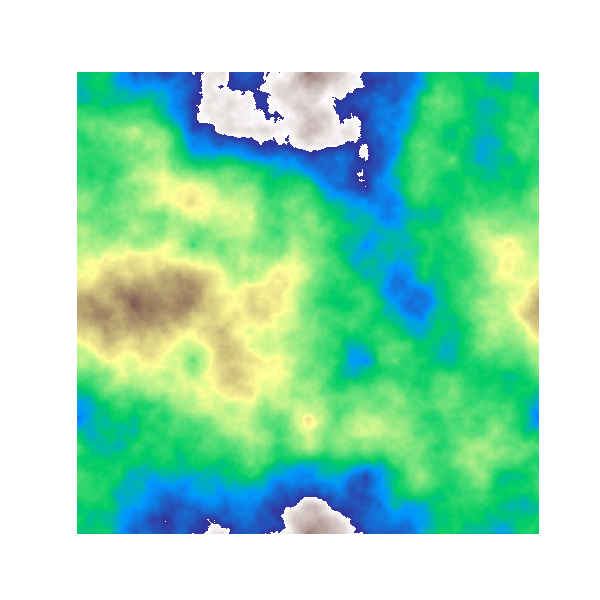

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter

# Grid size
n = 10
N = 2**n
terrain = np.zeros((N, N))

# Parameters
roughness = 0.5
initial_range = 1.0

# Hash-based deterministic noise
def rand_noise(x, y):
    return ((np.sin(x * 12.9898 + y * 78.233) * 43758.5453) % 1.0) * 2 - 1

# Generate midpoint displacement with periodicity
def midpoint_displacement_periodic(grid, size, roughness):
    step_size = size
    amplitude = initial_range

    while step_size > 1:
        half = step_size // 2

        # Square step
        for x in range(0, size, step_size):
            for y in range(0, size, step_size):
                cx = (x + half) % size
                cy = (y + half) % size
                avg = (
                    grid[x % size, y % size] +
                    grid[(x + step_size) % size, y % size] +
                    grid[x % size, (y + step_size) % size] +
                    grid[(x + step_size) % size, (y + step_size) % size]
                ) / 4.0
                offset = amplitude * rand_noise(cx, cy)
                grid[cx, cy] = avg + offset

        # Diamond step
        for x in range(0, size, half):
            for y in range((x + half) % step_size, size, step_size):
                s = (
                    grid[(x - half) % size, y % size] +
                    grid[(x + half) % size, y % size] +
                    grid[x % size, (y - half) % size] +
                    grid[x % size, (y + half) % size]
                ) / 4.0
                offset = amplitude * rand_noise(x + 0.5, y + 0.5)
                grid[x % size, y % size] = s + offset

        step_size = half
        amplitude *= roughness

# Initialize and generate terrain
terrain[0, 0] = rand_noise(0, 0)
midpoint_displacement_periodic(terrain, N, roughness)

# Normalize terrain for color cycling
terrain_norm = (terrain - terrain.min()) / (terrain.max() - terrain.min())

# Create a color palette (256-color grayscale for demonstration)
palette = plt.get_cmap("terrain")(np.linspace(0, 1, 256))

# Setup figure
fig, ax = plt.subplots(figsize=(6, 6))
img = ax.imshow(terrain_norm, cmap='terrain', animated=True, interpolation='nearest')
ax.axis('off')

# True color cycling: shift the colormap
def update(frame):
    shifted_palette = np.roll(palette, frame, axis=0)
    new_cmap = plt.matplotlib.colors.ListedColormap(shifted_palette)
    img.set_cmap(new_cmap)
    return [img]

ani = animation.FuncAnimation(fig, update, frames=60, interval=100, blit=True)

# Save GIF
gif_path = "./mid_p_CC.gif"
ani.save(gif_path, writer=PillowWriter(fps=4))


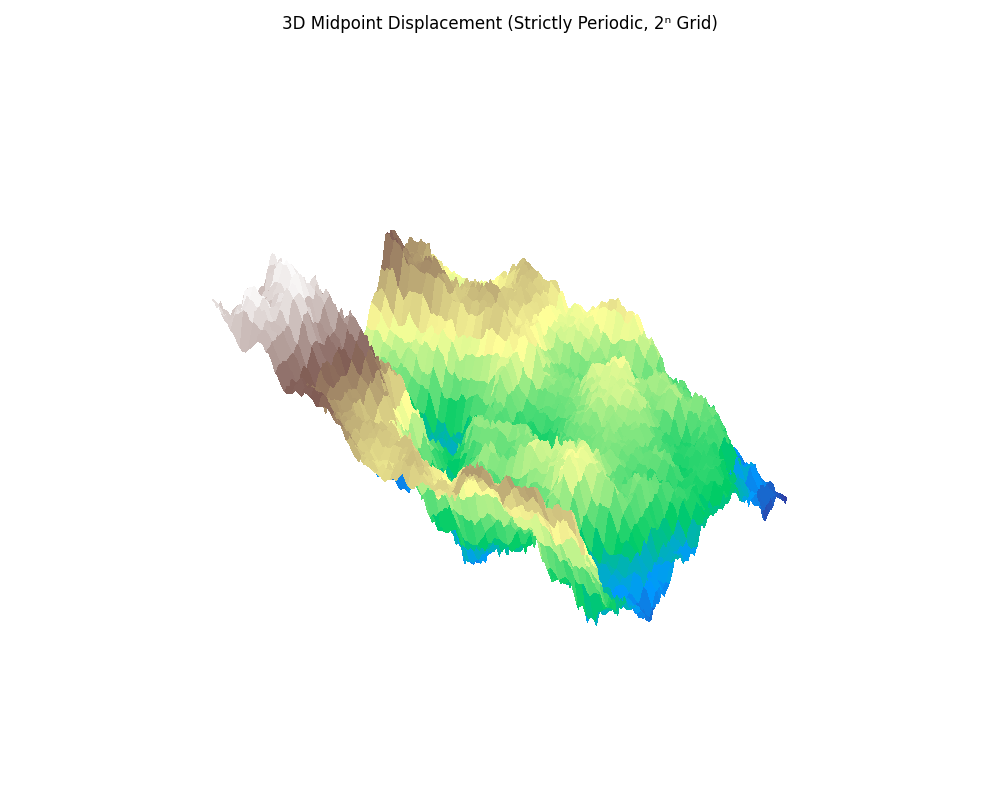

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
n = 7
N = 2**n  # Power-of-two resolution
roughness = 0.5
initial_range = 1.0

# Create (N+1)x(N+1) grid for midpoint displacement
terrain_large = np.zeros((N + 1, N + 1))
np.random.seed(None)

# Midpoint displacement with periodic wrap by enforcing last point = first
def midpoint_displacement_periodic_wrap(grid, roughness):
    size = grid.shape[0] - 1
    step = size
    scale = initial_range

    # Initialize corners
    grid[0, 0] = np.random.rand()
    grid[0, size] = np.random.rand()
    grid[size, 0] = np.random.rand()
    grid[size, size] = np.random.rand()

    def displace(x0, y0, x1, y1, scale):
        if (x1 - x0) < 2:
            return

        mx = (x0 + x1) // 2
        my = (y0 + y1) // 2

        if grid[mx, my] == 0:
            corners = [grid[x0, y0], grid[x0, y1], grid[x1, y0], grid[x1, y1]]
            grid[mx, my] = np.mean(corners) + (np.random.rand() - 0.5) * scale

        edge_points = [
            ((mx, y0), [(x0, y0), (x1, y0)]),
            ((mx, y1), [(x0, y1), (x1, y1)]),
            ((x0, my), [(x0, y0), (x0, y1)]),
            ((x1, my), [(x1, y0), (x1, y1)])
        ]

        for (ex, ey), [(ax, ay), (bx, by)] in edge_points:
            if grid[ex, ey] == 0:
                grid[ex, ey] = (grid[ax, ay] + grid[bx, by]) / 2 + (np.random.rand() - 0.5) * scale

        displace(x0, y0, mx, my, scale * roughness)
        displace(mx, y0, x1, my, scale * roughness)
        displace(x0, my, mx, y1, scale * roughness)
        displace(mx, my, x1, y1, scale * roughness)

    displace(0, 0, N, N, scale)

    # Enforce periodicity: wrap last row/col to first
    grid[-1, :] = grid[0, :]
    grid[:, -1] = grid[:, 0]

# Generate terrain
midpoint_displacement_periodic_wrap(terrain_large, roughness)

# Trim to NxN periodic tile
terrain_periodic = terrain_large[:-1, :-1]
terrain_norm = (terrain_periodic - terrain_periodic.min()) / (terrain_periodic.max() - terrain_periodic.min())

# 3D plot
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, terrain_norm, cmap='terrain', linewidth=0, antialiased=False)
ax.set_title("3D Midpoint Displacement (Strictly Periodic, 2ⁿ Grid)")
ax.set_axis_off()
plt.tight_layout()
plt.show()


'./midpoint_displacement.gif'

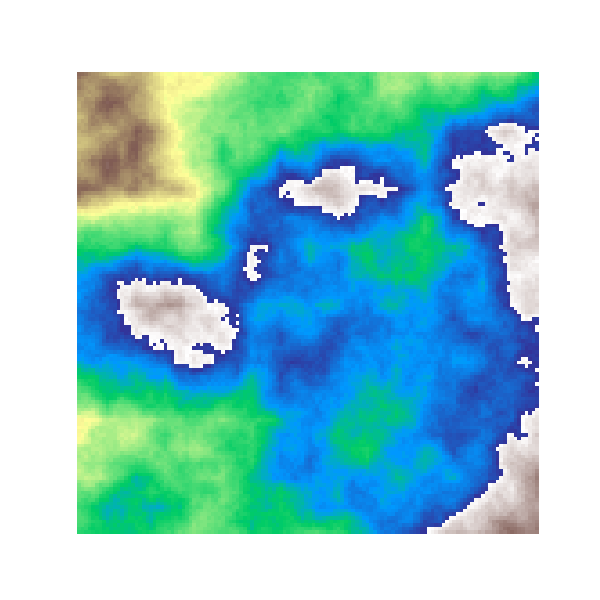

In [9]:
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter

# Setup figure for periodic terrain color cycling
fig, ax = plt.subplots(figsize=(6, 6))
img = ax.imshow(terrain_norm, cmap='terrain', interpolation='nearest', animated=True)
ax.axis('off')

# Generate color palette
palette = plt.get_cmap("terrain")(np.linspace(0, 1, 256))

# Animation update function
def update(frame):
    shifted_palette = np.roll(palette, frame, axis=0)
    new_cmap = plt.matplotlib.colors.ListedColormap(shifted_palette)
    img.set_cmap(new_cmap)
    return [img]

# Create animation
ani = animation.FuncAnimation(fig, update, frames=60, interval=100, blit=True)

# Save to GIF
gif_path = "./midpoint_displacement.gif"
ani.save(gif_path, writer=PillowWriter(fps=10))

gif_path


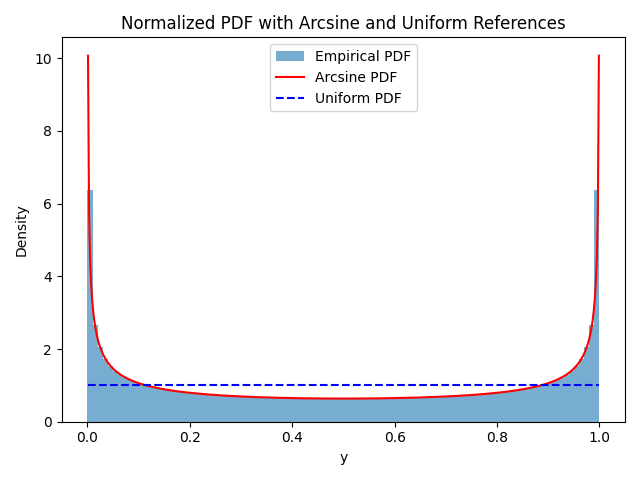

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 2D sin-logistic noise
def sin_logistic_prng_2d(n, p=12.9898, k=(127.1, 311.7)):
    N = 2**n
    xs = np.arange(N) / N
    ys = np.arange(N) / N
    xv, yv = np.meshgrid(xs, ys, indexing='xy')
    u = xv * k[0] + yv * k[1]
    x1 = 0.5 + 0.5 * np.sin(u)
    y = 4 * x1 * (1 - x1)
    return x1

n = 13
noise2d = sin_logistic_prng_2d(n)
values = noise2d.flatten()

# Plot normalized PDF with theoretical curves
plt.figure()
counts, bins, _ = plt.hist(values, bins=100, density=True, alpha=0.6, label='Empirical PDF')
x = np.linspace(0.001, 0.999, 500)
arcsine_pdf = 1 / (np.pi * np.sqrt(x * (1 - x)))
uniform_pdf = np.ones_like(x)

plt.plot(x, arcsine_pdf, 'r-', label='Arcsine PDF')
plt.plot(x, uniform_pdf, 'b--', label='Uniform PDF')

plt.xlabel('y')
plt.ylabel('Density')
plt.title('Normalized PDF with Arcsine and Uniform References')
plt.legend()
plt.tight_layout()
plt.show()


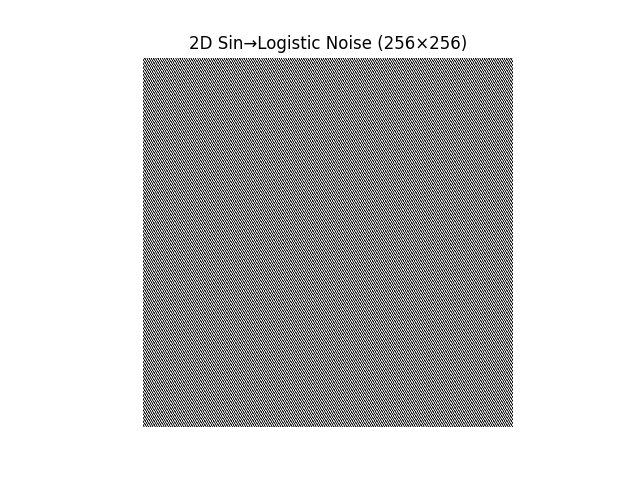

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def sin_logistic_prng_2d(n, p=12.9898, k=(527.1, 311.7)):
    """
    Generate a 2D pseudo-random field of shape (2^n, 2^n) via:
      u = x * kx + y * ky
      x1 = 0.5 + 0.5 * sin(u)
      y  = 4 * x1 * (1 - x1)
    """
    N = 2**n
    # Grid in [0,1)
    xs = np.arange(N) / N
    ys = np.arange(N) / N
    xv, yv = np.meshgrid(xs, ys, indexing='xy')
    
    # Compute u, seed, and logistic mix
    u  = xv * k[0] + yv * k[1]
    x1 = 0.5 + 0.5 * np.sin(u)
    y  = 4 * x1 * (1 - x1)
    
    return y

# Parameters
n = 10  # 256x256 grid
noise2d = sin_logistic_prng_2d(n)

# Plot in grayscale
plt.figure()
plt.imshow(noise2d, origin='lower', interpolation='nearest', cmap='gray')
plt.title('2D Sin→Logistic Noise (256×256)')
plt.axis('off')
plt.show()


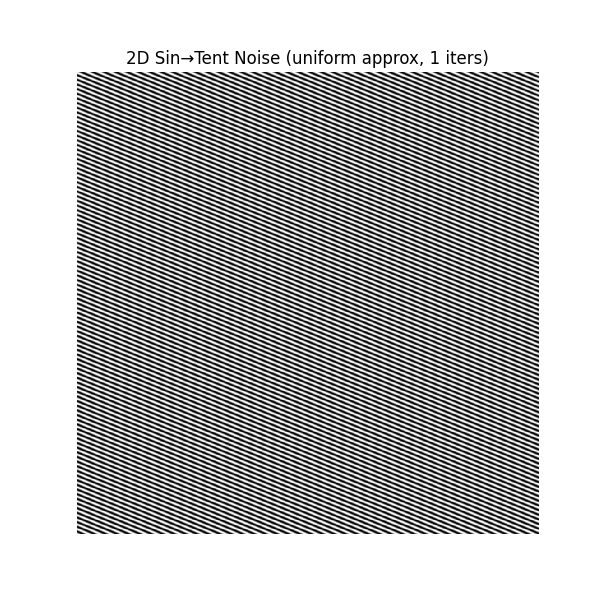

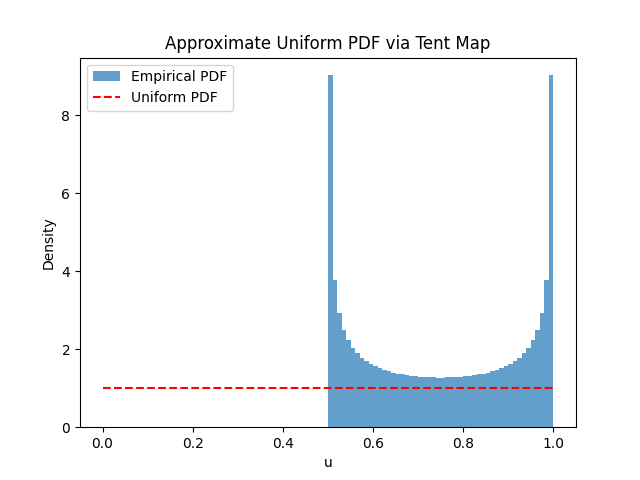

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sin_tent_prng_2d(n, p=12.9898, k=(127.1, 311.7), iterations=5):
    """
    Generate a 2D pseudo-random field of shape (2^n, 2^n) via:
      1) u = x*kx + y*ky
      2) seed x1 = 0.5 + 0.5*sin(u)
      3) apply the tent map: T(x) = 1 - 2*|x - 0.5| iteratively
    After enough iterations, the distribution converges to Uniform[0,1].
    """
    N = 2**n
    xs = np.arange(N) / N
    ys = np.arange(N) / N
    xv, yv = np.meshgrid(xs, ys, indexing='xy')
    
    # 1) Sin seed in [0,1]
    u  = xv * k[0] + yv * k[1]
    x1 = 0.5 + 0.5 * np.sin(u)
    
    # 2) Iterative tent map
    y = x1.copy()
    for _ in range(iterations):
        y = 1 - 2 * (y - 0.5)**2
    
    return y

# Parameters
n = 10         # 256×256 grid
iters = 1     # tent map iterations

# Generate and plot
noise_uni = sin_tent_prng_2d(n, iterations=iters)

plt.figure(figsize=(6, 6))
plt.imshow(noise_uni, origin='lower', interpolation='nearest', cmap='gray')
plt.title(f'2D Sin→Tent Noise (uniform approx, {iters} iters)')
plt.axis('off')
plt.show()

# Histogram + uniform reference
values = noise_uni.flatten()
plt.figure()
plt.hist(values, bins=50, density=True, alpha=0.7, label='Empirical PDF')
plt.plot([0, 1], [1, 1], 'r--', label='Uniform PDF')
plt.xlabel('u')
plt.ylabel('Density')
plt.title('Approximate Uniform PDF via Tent Map')
plt.legend()
plt.show()
